# Notebook 00 — Auditoría Física, Estructural y Control de Calidad de los Datasets

## 00. Introducción y objetivo

Proyecto académico: **Reconocimiento Acústico de Vehículos de Emergencia**.

Esta notebook responde una sola pregunta: **¿qué tenemos realmente?** Inspecciona los datasets montados en `/kaggle/input` y deja evidencia reproducible en `/kaggle/working/dataset_audit/`. No elige un dataset principal, no ordena los datasets y no entrena ningún modelo.

## Qué se verifica

1. Qué datasets están montados y cuál es su estructura de carpetas.
2. Cuántos archivos de audio hay, con qué extensión y tamaño.
3. Qué etiquetas aparecen en los CSV o en las carpetas, sin traducirlas.
4. Duración, frecuencia de muestreo, canales y formato recuperable desde la cabecera.
5. Archivos vacíos, ilegibles o con inconsistencias de cabecera.
6. Duplicados exactos, posibles indicios de augmentación y cruce entre audio y CSV.
7. Coincidencias entre datasets y evidencias de riesgo de fuga.

## Qué no hace esta notebook

No extrae MFCC, no crea espectrogramas, no aumenta datos, no normaliza audio, no cambia la frecuencia de muestreo, no convierte estéreo a mono, no balancea clases, no elimina archivos y no modifica `/kaggle/input`.

La decisión sobre el dataset principal, las particiones y las características del modelo queda para después de leer esta evidencia. El análisis temporal, frecuencial y de tiempo-frecuencia corresponde a la **Notebook 01 — Exploración de Datos (EDA)**.

## Reglas de lectura

Una carpeta o un nombre de archivo no se convierten en una clase definitiva. `possible_label_from_directory` solo conserva el nombre de la carpeta inmediata. `label_raw` guarda el texto observado en un CSV o en una carpeta estructural ya reconocida. `label_source` puede ser `CSV`, `DIRECTORY` o `METADATA`. Esta notebook no asigna `INFERRED`.

Si A3Siren-Recordings no aparece al buscar `A3Siren`, `A3Siren-Recordings`, `A3S-Rec` o `a3siren` dentro de `/kaggle/input`, se registra como **Pendiente de incorporación** y la corrida continúa.

Reejecutar la celda de configuración reinicia el estado en memoria. Después hay que seguir en orden.


## 01. Configuración y reproducibilidad

Las celdas de código de esta sección definen las funciones reutilizables. La última celda de la sección registra Python, la plataforma, la marca de tiempo, las versiones y la semilla. También crea `/kaggle/working/dataset_audit/`.

La metadata técnica del audio se lee de la cabecera. El waveform completo solo se recorre, por bloques, en la muestra de control de la sección 14.


In [1]:
from __future__ import annotations

# lib: Configuración, semilla y utilidades
# Las funciones describen archivos reales. No entrenan modelos, no modifican
# /kaggle/input y no convierten etiquetas de carpeta en una ontología.

import hashlib
import json
import math
import os
import platform
import re
import subprocess
import sys
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import soundfile as sf
except ImportError:  # Kaggle lo trae; si falta, la lectura queda registrada como error.
    sf = None

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = None

    def display(obj):
        print(obj)


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

INPUT_ROOT = Path("/kaggle/input")
OUTPUT_ROOT = Path("/kaggle/working/dataset_audit")

AUDIO_EXTENSIONS = {".wav", ".flac", ".mp3", ".ogg", ".m4a"}
META_EXTENSIONS = {".csv", ".tsv", ".json", ".txt", ".md"}
ACOUSTIC_QC_SAMPLE_PER_DATASET = 40
ACOUSTIC_MAX_SECONDS = 180.0
HASH_CHUNK_BYTES = 1024 * 1024
SILENCE_AMPLITUDE = 10 ** (-50 / 20)
CLIP_AMPLITUDE = 0.999
FRAME_DURATION_ABS_TOL = 0.05
FRAME_DURATION_REL_TOL = 0.01
RARE_SIGNATURE_MAX_GROUP = 6
MIN_NAME_MATCH_LEN = 8
MAX_OVERLAP_DETAIL = 200
TREE_MAX_DEPTH = 3
TREE_MAX_ENTRIES = 25

DATASET_ORDER = ["audioset_ev", "lssiren", "sirennet", "a3siren"]
DISPLAY_NAMES = {
    "audioset_ev": "AudioSet-EV v2",
    "lssiren": "LSSiren",
    "sirennet": "sireNNet",
    "a3siren": "A3Siren-Recordings",
}
A3_STATUS_PENDING = "Pendiente de incorporación"
STATUS_MOUNTED = "detectado"
STATUS_ABSENT = "no_montado"

INVENTORY_COLUMNS = [
    "dataset",
    "relative_path",
    "filename",
    "extension",
    "file_size_bytes",
    "file_size_mb",
    "directory",
    "possible_label_from_directory",
]
FOLDER_COLUMNS = ["dataset", "folder", "file_count", "depth"]
AUDIO_COLUMNS = [
    "dataset",
    "relative_path",
    "filename",
    "sampling_rate_hz",
    "channels",
    "duration_seconds",
    "frames",
    "format",
    "subtype",
    "file_size_bytes",
    "read_status",
    "error_message",
]
CLASS_COLUMNS = [
    "record_type",
    "dataset",
    "label_raw",
    "label_source",
    "count",
    "percentage",
    "class_min",
    "class_max",
    "max_min_ratio",
    "dominant_class_percentage",
    "notes",
]
QUALITY_COLUMNS = [
    "dataset",
    "relative_path",
    "filename",
    "quality_status",
    "issue_codes",
    "duration_seconds",
    "sampling_rate_hz",
    "channels",
    "frames",
    "file_size_bytes",
    "error_message",
]
DUP_COLUMNS = [
    "dataset",
    "hash_sha256",
    "duplicate_group_id",
    "file_count",
    "file_paths",
]
OVERLAP_COLUMNS = [
    "dataset_a",
    "dataset_b",
    "match_type",
    "match_basis",
    "evidence",
    "path_a",
    "path_b",
    "notes",
]
AUG_COLUMNS = [
    "dataset",
    "file_or_group",
    "evidence_type",
    "evidence",
    "confidence",
    "notes",
]
CONS_COLUMNS = [
    "dataset",
    "issue_type",
    "csv_path",
    "audio_path",
    "record_id",
    "details",
]
LEAK_COLUMNS = [
    "dataset",
    "risk_level",
    "risk_type",
    "evidence",
    "file_or_group",
    "notes",
]
MASTER_COLUMNS = [
    "dataset",
    "file_path",
    "filename",
    "label_raw",
    "label_source",
    "sampling_rate_hz",
    "channels",
    "duration_seconds",
    "frames",
    "format",
    "subtype",
    "file_size_bytes",
    "sha256",
    "read_status",
    "quality_status",
    "possible_augmentation",
    "possible_duplicate",
    "source_metadata_id",
    "notes",
]
SUMMARY_COLUMNS = [
    "dataset",
    "total_files",
    "valid_files",
    "invalid_files",
    "classes",
    "duration_min",
    "duration_median",
    "duration_mean",
    "duration_max",
    "sampling_rates",
    "channels",
    "duplicate_files",
    "missing_metadata",
    "possible_augmented_files",
    "possible_overlap_count",
    "leakage_risk",
]
LABEL_COLUMNS = [
    "dataset",
    "relative_path",
    "label_raw",
    "label_source",
    "source_metadata_id",
    "notes",
]
HASH_COLUMNS = ["dataset", "relative_path", "sha256", "hash_status", "error_message"]
ACOUSTIC_COLUMNS = [
    "dataset",
    "relative_path",
    "filename",
    "rms",
    "peak_amplitude",
    "clipping_ratio",
    "silence_ratio",
    "analysis_window_seconds",
    "file_duration_seconds",
    "read_status",
    "error_message",
    "notes",
]

EXPORT_ALIASES = {
    "01_dataset_inventory.csv": "file_inventory.csv",
    "02_folder_structure.csv": "folder_structure.csv",
    "03_audio_metadata.csv": "audio_metadata.csv",
    "05_quality_report.csv": "quality_report.csv",
    "06_duplicate_groups.csv": "duplicate_groups_internal.csv",
    "07_cross_dataset_overlap.csv": "cross_dataset_overlap.csv",
    "08_augmentation_evidence.csv": "augmentation_evidence.csv",
    "09_metadata_audio_consistency.csv": "metadata_audio_consistency.csv",
    "10_leakage_risk_report.csv": "leakage_risk_report.csv",
    "11_master_dataset_inventory.csv": "master_dataset_inventory.csv",
}

ID_TOKENS = (
    "file",
    "path",
    "filename",
    "fname",
    "audio",
    "wav",
    "clip",
    "ytid",
    "youtube",
    "video",
    "uri",
    "url",
    "name",
    "id",
    "key",
)
LABEL_TOKENS = (
    "label",
    "class",
    "category",
    "target",
    "tag",
    "annotation",
    "siren",
    "vehicle",
    "event",
)
SOURCE_TOKENS = (
    "source",
    "origin",
    "provenance",
    "youtube",
    "ytid",
    "video",
    "license",
    "url",
)
TIME_TOKENS = ("time", "start", "end", "duration", "offset", "timestamp", "date")
SPLIT_NAMES = {"train", "test", "val", "valid", "validation", "training", "testing"}
A3_NAME_RE = re.compile(r"a3siren-recordings|a3s-rec|a3siren", re.IGNORECASE)
YT_RE = re.compile(r"^[A-Za-z0-9_-]{11}$")
MEDIUM_NAME_RE = re.compile(
    r"(?:^|[_\-\s.])(aug|augmented|augmentation)(?:$|[_\-\s.\d])|"
    r"(pitchshift|pitch_shift|timestretch|time_stretch|timeshift|time_shift)",
    re.IGNORECASE,
)
LOW_NAME_RE = re.compile(
    r"(?:^|[_\-\s.])(noise|reverb|gain|speed|stretch|shift|crop|pad)(?:$|[_\-\s.\d])",
    re.IGNORECASE,
)
AUG_COL_RE = re.compile(r"augment|pitch|stretch|reverb|gain|transform|effect", re.IGNORECASE)
AUG_VALUE_RE = re.compile(
    r"augment|pitch|stretch|reverb|time_shift|timestretch|speed",
    re.IGNORECASE,
)
AUG_NEGATIVE_RE = re.compile(r"^(none|original|false|no|0|raw|nan|null|na)$", re.IGNORECASE)
SIREN_CLASS_FOLDERS = ("ambulance", "firetruck", "police", "traffic")
AUDIOSET_CLASS_FOLDERS = ("Positive_files", "Negative_files")
LSSIREN_CLASS_FOLDERS = ("Emergency Vehicle Sirens", "Road Noises")
RISK_RANK = {"HIGH RISK": 3, "MEDIUM RISK": 2, "LOW RISK": 1, "UNRESOLVED": 0}
CONFIDENCE_RANK = {"HIGH": 3, "MEDIUM": 2, "LOW": 1}

STATE: dict = {}


def plots_dir() -> Path:
    return OUTPUT_ROOT / "plots"


def empty_frame(columns: list[str]) -> pd.DataFrame:
    return pd.DataFrame(columns=columns)


def show_markdown(text: str) -> None:
    in_notebook = False
    try:
        from IPython import get_ipython

        shell = get_ipython()
        in_notebook = shell is not None and shell.has_trait("kernel")
    except Exception:
        in_notebook = False
    if in_notebook and Markdown is not None:
        display(Markdown(text))
        return
    print(text)


def show_df(df: pd.DataFrame, n: int = 15) -> None:
    print(f"filas: {len(df)} | columnas: {len(df.columns)}")
    if df.empty:
        print("(tabla vacía)")
        return
    display(df.head(n))


def require_state(*keys: str) -> None:
    missing = [key for key in keys if key not in STATE]
    if missing:
        raise RuntimeError(
            "Faltan resultados de secciones anteriores: "
            + ", ".join(missing)
            + ". Ejecute la notebook desde la sección 01, en orden."
        )


def export_table(df: pd.DataFrame, filename: str, alias: str | None = None) -> Path:
    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    path = OUTPUT_ROOT / filename
    frame = df.copy()
    frame.to_csv(path, index=False, na_rep="")
    print(f"escrito: {path}")
    if alias:
        alias_path = OUTPUT_ROOT / alias
        frame.to_csv(alias_path, index=False, na_rep="")
        print(f"alias: {alias_path}")
    return path


def write_text(filename: str, text: str) -> Path:
    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    path = OUTPUT_ROOT / filename
    path.write_text(text, encoding="utf-8")
    print(f"escrito: {path}")
    return path


def ensure_output_dirs() -> None:
    """Crea solo /kaggle/working/dataset_audit. Nunca escribe en /kaggle/input."""
    try:
        plots_dir().mkdir(parents=True, exist_ok=True)
    except OSError as exc:
        raise RuntimeError(
            "No se pudo crear /kaggle/working/dataset_audit. "
            "Esta notebook debe ejecutarse en Kaggle, con los datasets montados en /kaggle/input."
        ) from exc


def configure_plots() -> None:
    plt.rcParams.update(
        {
            "figure.facecolor": "white",
            "axes.facecolor": "white",
            "axes.grid": True,
            "grid.alpha": 0.3,
            "axes.axisbelow": True,
            "font.size": 11,
            "axes.titlesize": 12,
            "axes.labelsize": 11,
        }
    )


def package_version(name: str) -> str:
    try:
        from importlib.metadata import version

        return version(name)
    except Exception:
        return "no instalada"


def show_environment() -> dict:
    configure_plots()
    libraries = {
        name: package_version(name)
        for name in ("numpy", "pandas", "matplotlib", "soundfile", "tqdm")
    }
    environment = {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "python": sys.version.replace("\n", " "),
        "platform": platform.platform(),
        "seed": RANDOM_SEED,
        "input_root": str(INPUT_ROOT),
        "output_root": str(OUTPUT_ROOT),
        "acoustic_sample_per_dataset": ACOUSTIC_QC_SAMPLE_PER_DATASET,
        "acoustic_max_seconds": ACOUSTIC_MAX_SECONDS,
        "silence_amplitude": SILENCE_AMPLITUDE,
        "clip_amplitude": CLIP_AMPLITUDE,
        "libraries": libraries,
        "soundfile_importable": sf is not None,
    }
    STATE["environment"] = environment
    print(f"timestamp_utc: {environment['timestamp_utc']}")
    print(f"python: {environment['python']}")
    print(f"platform: {environment['platform']}")
    print(f"seed: {RANDOM_SEED}")
    print(f"input: {INPUT_ROOT}")
    print(f"output: {OUTPUT_ROOT}")
    print(f"soundfile importable: {sf is not None}")
    display(pd.DataFrame({"libreria": list(libraries), "version": list(libraries.values())}))
    return environment


def _display_name(dataset_id: str) -> str:
    return DISPLAY_NAMES.get(dataset_id, dataset_id)


def _dataset_id_from_name(dataset_name: str) -> str:
    for dataset_id, name in DISPLAY_NAMES.items():
        if name == dataset_name:
            return dataset_id
    return dataset_name


def _is_ancestor(parent: Path, child: Path) -> bool:
    try:
        child.resolve().relative_to(parent.resolve())
    except ValueError:
        return False
    return parent.resolve() != child.resolve()


def _audio_file_count(root: Path) -> int:
    count = 0
    for dirpath, dirnames, filenames in os.walk(root, followlinks=False):
        dirnames.sort()
        for name in filenames:
            if Path(name).suffix.lower() in AUDIO_EXTENSIONS:
                count += 1
    return count


def _column_hits(column_name: str, tokens: tuple[str, ...]) -> bool:
    normalized = re.sub(r"[^a-z0-9]+", " ", str(column_name).casefold()).strip()
    parts = set(normalized.split())
    compact = normalized.replace(" ", "")
    for token in tokens:
        if len(token) <= 3:
            if token in parts:
                return True
        elif token in parts or token in compact:
            return True
    return False


def _as_text(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.strip()


def _truncate(value: object, limit: int = 180) -> str:
    text = "" if value is None else str(value)
    if len(text) <= limit:
        return text
    return text[: limit - 1] + "…"


def _join_paths(paths: list[str], limit: int = 12) -> str:
    if len(paths) <= limit:
        return " | ".join(paths)
    head = " | ".join(paths[:limit])
    return f"{head} | … ({len(paths) - limit} rutas más; total {len(paths)})"


In [2]:
# lib: Descubrimiento, inventario y árbol de carpetas

def _index_input(input_root: Path) -> dict:
    directories: list[Path] = []
    children: dict[Path, list[str]] = {}
    csv_exact: dict[str, list[Path]] = defaultdict(list)
    csv_fold: dict[str, list[Path]] = defaultdict(list)
    folder_exact: dict[str, list[Path]] = defaultdict(list)
    folder_fold: dict[str, list[Path]] = defaultdict(list)
    walk_errors: list[str] = []

    for dirpath, dirnames, filenames in os.walk(input_root, followlinks=False, onerror=None):
        current = Path(dirpath)
        dirnames.sort()
        filenames.sort()
        directories.append(current)
        children[current] = list(dirnames)
        for name in dirnames:
            folder_exact[name].append(current / name)
            folder_fold[name.casefold()].append(current / name)
        for name in filenames:
            if name.lower().endswith(".csv"):
                path = current / name
                csv_exact[name].append(path)
                csv_fold[name.casefold()].append(path)
    return {
        "directories": directories,
        "children": children,
        "csv_exact": csv_exact,
        "csv_fold": csv_fold,
        "folder_exact": folder_exact,
        "folder_fold": folder_fold,
        "walk_errors": walk_errors,
    }


def _csv_hits(index: dict, expected: str) -> list[Path]:
    exact = index["csv_exact"].get(expected, [])
    if exact:
        return exact
    return index["csv_fold"].get(expected.casefold(), [])


def _folder_hits(index: dict, expected: str) -> list[Path]:
    exact = index["folder_exact"].get(expected, [])
    if exact:
        return exact
    return index["folder_fold"].get(expected.casefold(), [])


def _add_candidate(bucket: dict[str, dict], root: Path, evidence: str) -> None:
    key = str(root)
    current = bucket.get(key)
    if current is None:
        bucket[key] = {"root": root, "evidence": [evidence]}
        return
    if evidence not in current["evidence"]:
        current["evidence"].append(evidence)


def _select_candidate(candidates: list[dict]) -> tuple[dict | None, list[str]]:
    if not candidates:
        return None, []
    for candidate in candidates:
        candidate["audio_file_count_estimate"] = _audio_file_count(candidate["root"])
    remaining = list(candidates)
    dropped: list[str] = []
    changed = True
    while changed:
        changed = False
        next_remaining = []
        for candidate in remaining:
            dominated = False
            for other in remaining:
                if other is candidate:
                    continue
                # Si el ancestro contiene exactamente los mismos audios, la raíz útil es la más específica.
                if _is_ancestor(candidate["root"], other["root"]) and (
                    candidate["audio_file_count_estimate"] == other["audio_file_count_estimate"]
                ):
                    dominated = True
                    break
            if dominated:
                dropped.append(str(candidate["root"]))
                changed = True
            else:
                next_remaining.append(candidate)
        remaining = next_remaining
    if not remaining:
        remaining = list(candidates)
    remaining.sort(
        key=lambda item: (
            -item["audio_file_count_estimate"],
            len(item["root"].parts),
            str(item["root"]),
        )
    )
    best = remaining[0]
    alternatives = [str(item["root"]) for item in remaining[1:]] + dropped
    # Un ancestro con más audio que el descendiente se conserva; el descendiente queda anotado.
    for candidate in candidates:
        root_text = str(candidate["root"])
        if root_text != str(best["root"]) and root_text not in alternatives:
            alternatives.append(root_text)
    return best, alternatives


def list_mounts(input_root: Path) -> list[Path]:
    """Puntos de montaje típicos de Kaggle, sin asumir que todos son datasets del proyecto."""
    if not input_root.exists():
        return []
    mounts: list[Path] = []
    children = sorted(
        [path for path in input_root.iterdir() if path.is_dir()],
        key=lambda path: path.name.lower(),
    )
    for child in children:
        if child.name != "datasets":
            mounts.append(child)
            continue
        owners = sorted(
            [path for path in child.iterdir() if path.is_dir()],
            key=lambda path: path.name.lower(),
        )
        if not owners:
            mounts.append(child)
            continue
        for owner in owners:
            slugs = sorted(
                [path for path in owner.iterdir() if path.is_dir()],
                key=lambda path: path.name.lower(),
            )
            mounts.extend(slugs or [owner])
    return mounts


def _path_covers(left: Path, right: Path) -> bool:
    try:
        right.resolve().relative_to(left.resolve())
        return True
    except ValueError:
        return False


def discover_datasets(input_root: Path | None = None) -> dict:
    """Detecta familias por huella estructural. No inventa rutas ausentes."""
    root = INPUT_ROOT if input_root is None else Path(input_root)
    records = []
    if not root.exists():
        for dataset_id in DATASET_ORDER:
            status = A3_STATUS_PENDING if dataset_id == "a3siren" else STATUS_ABSENT
            records.append(
                {
                    "dataset_id": dataset_id,
                    "dataset": _display_name(dataset_id),
                    "status": status,
                    "root": "",
                    "evidence": f"no existe el directorio {root}",
                    "audio_file_count_estimate": 0,
                    "alternatives": [],
                }
            )
        return {
            "input_root": str(root),
            "input_exists": False,
            "datasets": records,
            "mounts": [],
            "unrecognized": [],
        }

    index = _index_input(root)
    buckets: dict[str, dict[str, dict]] = {dataset_id: {} for dataset_id in DATASET_ORDER}

    positive_csv_dirs = {path.parent for path in _csv_hits(index, "EV_Positives.csv")}
    negative_csv_dirs = {path.parent for path in _csv_hits(index, "EV_Negatives.csv")}
    for dataset_root in sorted(positive_csv_dirs & negative_csv_dirs, key=str):
        _add_candidate(
            buckets["audioset_ev"],
            dataset_root,
            "EV_Positives.csv + EV_Negatives.csv",
        )
    positive_dirs = {path.parent for path in _folder_hits(index, "Positive_files")}
    negative_dirs = {path.parent for path in _folder_hits(index, "Negative_files")}
    for dataset_root in sorted(positive_dirs & negative_dirs, key=str):
        _add_candidate(
            buckets["audioset_ev"],
            dataset_root,
            "Positive_files + Negative_files",
        )

    ambulance_dirs = {path.parent for path in _csv_hits(index, "Ambulance_final.csv")}
    road_dirs = {path.parent for path in _csv_hits(index, "Road_final.csv")}
    for dataset_root in sorted(ambulance_dirs & road_dirs, key=str):
        _add_candidate(
            buckets["lssiren"],
            dataset_root,
            "Ambulance_final.csv + Road_final.csv",
        )
    siren_dirs = {path.parent for path in _folder_hits(index, "Emergency Vehicle Sirens")}
    noise_dirs = {path.parent for path in _folder_hits(index, "Road Noises")}
    for dataset_root in sorted(siren_dirs & noise_dirs, key=str):
        _add_candidate(
            buckets["lssiren"],
            dataset_root,
            "Emergency Vehicle Sirens + Road Noises",
        )

    required = set(SIREN_CLASS_FOLDERS)
    for directory in index["directories"]:
        names = index["children"].get(directory, [])
        folded = {name.casefold(): name for name in names}
        if required <= set(folded):
            observed = ", ".join(folded[name] for name in SIREN_CLASS_FOLDERS)
            _add_candidate(buckets["sirennet"], directory, f"subcarpetas directas: {observed}")

    for directory in index["directories"]:
        if A3_NAME_RE.search(directory.name):
            _add_candidate(buckets["a3siren"], directory, f"nombre de carpeta: {directory.name}")

    for dataset_id in DATASET_ORDER:
        chosen, alternatives = _select_candidate(list(buckets[dataset_id].values()))
        if chosen is None:
            status = A3_STATUS_PENDING if dataset_id == "a3siren" else STATUS_ABSENT
            evidence = (
                "búsqueda recursiva sin coincidencias de nombre A3Siren, A3Siren-Recordings, A3S-Rec o a3siren"
                if dataset_id == "a3siren"
                else "huella estructural no encontrada dentro de /kaggle/input"
            )
            records.append(
                {
                    "dataset_id": dataset_id,
                    "dataset": _display_name(dataset_id),
                    "status": status,
                    "root": "",
                    "evidence": evidence,
                    "audio_file_count_estimate": 0,
                    "alternatives": [],
                }
            )
            continue
        records.append(
            {
                "dataset_id": dataset_id,
                "dataset": _display_name(dataset_id),
                "status": STATUS_MOUNTED,
                "root": str(chosen["root"]),
                "evidence": " | ".join(chosen["evidence"]),
                "audio_file_count_estimate": chosen["audio_file_count_estimate"],
                "alternatives": alternatives,
            }
        )

    mounts = list_mounts(root)
    detected_roots = [Path(item["root"]) for item in records if item["root"]]
    unrecognized = []
    for mount in mounts:
        if any(_path_covers(mount, detected) or _path_covers(detected, mount) for detected in detected_roots):
            continue
        unrecognized.append(str(mount))

    return {
        "input_root": str(root),
        "input_exists": True,
        "datasets": records,
        "mounts": [str(path) for path in mounts],
        "unrecognized": unrecognized,
    }


def detected_datasets(discovered: dict | None = None) -> list[dict]:
    source = STATE.get("discovered") if discovered is None else discovered
    if not source:
        return []
    return [item for item in source["datasets"] if item["status"] == STATUS_MOUNTED]


def inventory_files(dataset: dict) -> pd.DataFrame:
    """Recorre un dataset y lista solo extensiones de audio. No abre el audio."""
    rows = []
    root_text = dataset.get("root") or ""
    if dataset.get("status") != STATUS_MOUNTED or not root_text:
        return empty_frame(INVENTORY_COLUMNS)
    root = Path(root_text)
    dataset_name = dataset["dataset"]
    for dirpath, dirnames, filenames in os.walk(root, followlinks=False):
        dirnames.sort()
        filenames.sort()
        for name in filenames:
            path = Path(dirpath) / name
            extension = path.suffix.lower()
            if extension not in AUDIO_EXTENSIONS:
                continue
            try:
                size = path.stat().st_size
                size_error = ""
            except OSError as exc:
                size = None
                size_error = f"{type(exc).__name__}: {exc}"
            relative = path.relative_to(root)
            directory = "" if str(relative.parent) == "." else relative.parent.as_posix()
            possible_label = "" if directory == "" else Path(directory).name
            rows.append(
                {
                    "dataset": dataset_name,
                    "relative_path": relative.as_posix(),
                    "filename": path.name,
                    "extension": extension,
                    "file_size_bytes": size,
                    "file_size_mb": None if size is None else size / (1024 ** 2),
                    "directory": directory,
                    "possible_label_from_directory": possible_label,
                    "stat_error": size_error,
                }
            )
    frame = pd.DataFrame(rows)
    if frame.empty:
        return empty_frame(INVENTORY_COLUMNS + ["stat_error"])
    frame["file_size_bytes"] = pd.to_numeric(frame["file_size_bytes"], errors="coerce").astype("Int64")
    return frame.sort_values(["dataset", "relative_path"]).reset_index(drop=True)


def folder_structure(dataset: dict) -> pd.DataFrame:
    root_text = dataset.get("root") or ""
    if dataset.get("status") != STATUS_MOUNTED or not root_text:
        return empty_frame(FOLDER_COLUMNS)
    root = Path(root_text)
    rows = []
    for dirpath, dirnames, filenames in os.walk(root, followlinks=False):
        dirnames.sort()
        audio_count = sum(1 for name in filenames if Path(name).suffix.lower() in AUDIO_EXTENSIONS)
        relative = Path(dirpath).relative_to(root).as_posix()
        folder = "." if relative == "." else relative
        depth = 0 if folder == "." else len(Path(folder).parts)
        rows.append(
            {
                "dataset": dataset["dataset"],
                "folder": folder,
                "file_count": audio_count,
                "depth": depth,
            }
        )
    if not rows:
        return empty_frame(FOLDER_COLUMNS)
    return pd.DataFrame(rows).sort_values(["dataset", "folder"]).reset_index(drop=True)


def format_tree(root: Path, max_depth: int = TREE_MAX_DEPTH, max_entries: int = TREE_MAX_ENTRIES) -> str:
    lines = [f"{root.name}/"]

    def walk(path: Path, prefix: str, depth: int) -> None:
        if depth > max_depth:
            lines.append(prefix + "…")
            return
        try:
            entries = sorted(path.iterdir(), key=lambda item: (not item.is_dir(), item.name.lower()))
        except OSError as exc:
            lines.append(prefix + f"[no legible: {exc}]")
            return
        hidden = max(0, len(entries) - max_entries)
        shown = entries[:max_entries]
        for index, entry in enumerate(shown):
            last = index == len(shown) - 1 and hidden == 0
            connector = "└── " if last else "├── "
            suffix = "/" if entry.is_dir() else ""
            lines.append(prefix + connector + entry.name + suffix)
            if entry.is_dir():
                extension = "    " if last else "│   "
                walk(entry, prefix + extension, depth + 1)
        if hidden:
            lines.append(prefix + f"└── … ({hidden} entradas más en este nivel)")

    walk(root, "", 1)
    return "\n".join(lines)


def structural_directory_label(dataset_id: str, relative_path: str) -> str:
    """Devuelve el nombre de carpeta observado. No traduce ese nombre a otra clase."""
    parts = Path(relative_path).parts[:-1]
    if dataset_id == "audioset_ev":
        for part in parts:
            if part in AUDIOSET_CLASS_FOLDERS:
                return part
    elif dataset_id == "lssiren":
        for part in parts:
            if part in LSSIREN_CLASS_FOLDERS:
                return part
    elif dataset_id == "sirennet":
        for part in parts:
            if part.casefold() in SIREN_CLASS_FOLDERS:
                return part
    return ""


In [3]:
# lib: Lectura de CSV, enlace archivo-registro y etiquetas

def read_metadata(csv_path: Path) -> dict:
    """Inspecciona un CSV sin asumir nombres de columnas ni corregir valores."""
    path = Path(csv_path)
    frame = None
    read_error = ""
    encoding_used = ""
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            frame = pd.read_csv(path, low_memory=False, encoding=encoding)
            encoding_used = encoding
            break
        except UnicodeDecodeError:
            continue
        except Exception as exc:  # ParserError u otros: segundo intento con separador inferido.
            try:
                frame = pd.read_csv(path, sep=None, engine="python", encoding=encoding)
                encoding_used = encoding
                read_error = f"lectura con separador inferido tras {type(exc).__name__}: {exc}"
                break
            except Exception as second:
                read_error = f"{type(second).__name__}: {second}"
                frame = None
    if frame is None:
        return {
            "path": path,
            "frame": empty_frame([]),
            "read_error": read_error or "no se pudo leer el CSV",
            "encoding": encoding_used,
            "profile": empty_frame([]),
            "id_columns": [],
            "label_columns": [],
            "source_columns": [],
            "time_columns": [],
        }
    profile_rows = []
    for column in frame.columns:
        series = frame[column]
        text = _as_text(series)
        non_empty = text[text != ""]
        uniques = non_empty.drop_duplicates().head(8).tolist()
        profile_rows.append(
            {
                "column_name": str(column),
                "dtype": str(series.dtype),
                "row_count": int(len(frame)),
                "null_count": int(series.isna().sum()),
                "empty_string_count": int((text == "").sum()),
                "nunique_non_empty": int(non_empty.nunique()),
                "sample_values": " | ".join(_truncate(value, 80) for value in uniques),
            }
        )
    columns = [str(column) for column in frame.columns]
    return {
        "path": path,
        "frame": frame,
        "read_error": read_error,
        "encoding": encoding_used,
        "profile": pd.DataFrame(profile_rows),
        "id_columns": [column for column in columns if _column_hits(column, ID_TOKENS)],
        "label_columns": [column for column in columns if _column_hits(column, LABEL_TOKENS)],
        "source_columns": [column for column in columns if _column_hits(column, SOURCE_TOKENS)],
        "time_columns": [column for column in columns if _column_hits(column, TIME_TOKENS)],
    }


def _candidate_columns(metadata: dict) -> list[str]:
    columns = list(metadata["id_columns"])
    if columns:
        return columns
    return [str(column) for column in metadata["frame"].columns]


def _match_counts(metadata: dict, inventory: pd.DataFrame) -> list[dict]:
    """Cuenta coincidencias por columna y estrategia. No elige todavía la etiqueta."""
    frame = metadata["frame"]
    if frame.empty or inventory.empty:
        return []
    files = inventory.copy()
    files["rel_cf"] = files["relative_path"].map(lambda value: str(value).replace("\\", "/").casefold())
    files["name_cf"] = files["filename"].map(lambda value: str(value).casefold())
    files["stem_cf"] = files["filename"].map(lambda value: Path(str(value)).stem.casefold())
    rel_set = set(files["rel_cf"])
    name_set = set(files["name_cf"])
    stem_set = set(files["stem_cf"])
    rows = []
    for column in _candidate_columns(metadata):
        if column not in frame.columns:
            continue
        text = _as_text(frame[column])
        usable = text != ""
        normalized = text.str.replace("\\", "/", regex=False).str.lstrip("./")
        name = normalized.map(lambda value: Path(value).name.casefold() if value else "")
        stem = name.map(lambda value: Path(value).stem.casefold() if value else "")
        rel = normalized.str.casefold()
        strategies = {
            "relative_path": int((usable & rel.isin(rel_set)).sum()),
            "filename": int((usable & name.isin(name_set)).sum()),
            "stem": int((usable & stem.isin(stem_set)).sum()),
        }
        for strategy, matched in strategies.items():
            rows.append(
                {
                    "column_name": column,
                    "strategy": strategy,
                    "matched_rows": matched,
                    "non_empty_rows": int(usable.sum()),
                    "candidate_list": "id" if column in metadata["id_columns"] else "fallback_all_columns",
                }
            )
    return rows


def _choose_link_strategy(match_rows: list[dict]) -> dict | None:
    if not match_rows:
        return None
    priority = {"relative_path": 3, "filename": 2, "stem": 1}
    best = max(
        match_rows,
        key=lambda item: (
            item["matched_rows"],
            1 if item["candidate_list"] == "id" else 0,
            priority[item["strategy"]],
        ),
    )
    if best["matched_rows"] <= 0:
        return None
    return best


def _index_files(inventory: pd.DataFrame) -> dict:
    by_rel = defaultdict(list)
    by_name = defaultdict(list)
    by_stem = defaultdict(list)
    for record in inventory.itertuples(index=False):
        relative = str(record.relative_path).replace("\\", "/")
        by_rel[relative.casefold()].append(record)
        by_name[str(record.filename).casefold()].append(record)
        by_stem[Path(str(record.filename)).stem.casefold()].append(record)
    return {"relative_path": by_rel, "filename": by_name, "stem": by_stem}


def _lookup_key(strategy: str, raw_value: str) -> str:
    normalized = raw_value.replace("\\", "/").lstrip("./")
    if strategy == "relative_path":
        return normalized.casefold()
    if strategy == "filename":
        return Path(normalized).name.casefold()
    return Path(normalized).stem.casefold()


def _primary_label_column(metadata: dict, id_column: str | None) -> str:
    candidates = []
    for column in metadata["label_columns"]:
        if column == id_column:
            continue
        if column not in metadata["frame"].columns:
            continue
        non_empty = int((_as_text(metadata["frame"][column]) != "").sum())
        if non_empty <= 0:
            continue
        priority = 0
        folded = column.casefold()
        if "label" in folded:
            priority = 4
        elif "class" in folded:
            priority = 3
        elif "category" in folded:
            priority = 2
        elif "target" in folded:
            priority = 1
        candidates.append((non_empty, priority, column))
    if not candidates:
        return ""
    candidates.sort(key=lambda item: (item[0], item[1], item[2]), reverse=True)
    return candidates[0][2]


def _source_id_column(metadata: dict, id_column: str | None) -> str:
    preferred = []
    for column in metadata["source_columns"]:
        if column == id_column or column not in metadata["frame"].columns:
            continue
        folded = column.casefold()
        score = 0
        if "youtube" in folded or "ytid" in folded:
            score = 3
        elif "source" in folded or "origin" in folded or "provenance" in folded:
            score = 2
        elif "video" in folded:
            score = 1
        non_empty = int((_as_text(metadata["frame"][column]) != "").sum())
        if non_empty > 0 and score > 0:
            preferred.append((score, non_empty, column))
    if not preferred:
        return ""
    preferred.sort(reverse=True)
    return preferred[0][2]


def link_metadata_to_files(metadata: dict, inventory: pd.DataFrame) -> dict:
    """Relaciona filas de un CSV con archivos y conserva la estrategia usada."""
    match_rows = _match_counts(metadata, inventory)
    chosen = _choose_link_strategy(match_rows)
    links = []
    ambiguous = []
    unmatched_rows = []
    if chosen is None or inventory.empty or metadata["frame"].empty:
        return {
            "match_rows": match_rows,
            "chosen": chosen,
            "links": links,
            "ambiguous": ambiguous,
            "unmatched_rows": unmatched_rows,
            "label_column": "",
            "source_column": "",
            "id_column": "" if chosen is None else chosen["column_name"],
        }
    id_column = chosen["column_name"]
    strategy = chosen["strategy"]
    label_column = _primary_label_column(metadata, id_column)
    source_column = _source_id_column(metadata, id_column)
    other_labels = [column for column in metadata["label_columns"] if column not in {label_column, id_column}]
    index = _index_files(inventory)
    frame = metadata["frame"]
    seen_rows = set()
    for row_number, row in frame.iterrows():
        raw_id = "" if pd.isna(row[id_column]) else str(row[id_column]).strip()
        if raw_id == "" or raw_id.casefold() == "nan":
            unmatched_rows.append({"row_number": int(row_number), "record_id": "", "reason": "identificador vacío"})
            continue
        matches = index[strategy].get(_lookup_key(strategy, raw_id), [])
        label_value = ""
        if label_column:
            raw_label = row[label_column]
            label_value = "" if pd.isna(raw_label) else str(raw_label).strip()
        source_value = ""
        if source_column:
            raw_source = row[source_column]
            source_value = "" if pd.isna(raw_source) else str(raw_source).strip()
        elif _column_hits(id_column, ("youtube", "ytid", "source", "origin", "provenance")):
            source_value = raw_id
        other_values = []
        for column in other_labels:
            raw_other = row[column]
            if pd.isna(raw_other):
                continue
            text = str(raw_other).strip()
            if text:
                other_values.append(f"{column}={text}")
        if len(matches) == 1:
            match = matches[0]
            links.append(
                {
                    "relative_path": match.relative_path,
                    "record_id": raw_id,
                    "label_value": label_value,
                    "label_column": label_column,
                    "source_metadata_id": source_value or raw_id,
                    "source_column": source_column or id_column,
                    "other_label_values": " | ".join(other_values),
                    "csv_path": str(metadata["path"]),
                    "row_number": int(row_number),
                }
            )
        elif len(matches) > 1:
            ambiguous.append(
                {
                    "record_id": raw_id,
                    "row_number": int(row_number),
                    "paths": [match.relative_path for match in matches],
                    "label_value": label_value,
                }
            )
        else:
            unmatched_rows.append(
                {"row_number": int(row_number), "record_id": raw_id, "reason": "sin archivo correspondiente"}
            )
        seen_rows.add(int(row_number))
    return {
        "match_rows": match_rows,
        "chosen": chosen,
        "links": links,
        "ambiguous": ambiguous,
        "unmatched_rows": unmatched_rows,
        "label_column": label_column,
        "source_column": source_column,
        "id_column": id_column,
    }


def find_metadata_files(dataset_root: Path) -> list[Path]:
    found = []
    if not dataset_root.exists():
        return found
    for dirpath, dirnames, filenames in os.walk(dataset_root, followlinks=False):
        dirnames.sort()
        filenames.sort()
        for name in filenames:
            path = Path(dirpath) / name
            if path.suffix.lower() in META_EXTENSIONS:
                found.append(path)
    return found


def expected_csv_names(dataset_id: str) -> list[str]:
    if dataset_id == "audioset_ev":
        return ["EV_Positives.csv", "EV_Negatives.csv"]
    if dataset_id == "lssiren":
        return ["Ambulance_final.csv", "Road_final.csv"]
    return []


def locate_expected_csvs(dataset: dict) -> list[Path]:
    root = Path(dataset["root"])
    located = []
    for name in expected_csv_names(dataset["dataset_id"]):
        direct = root / name
        if direct.is_file():
            located.append(direct)
            continue
        folded = name.casefold()
        matches = [
            path
            for path in find_metadata_files(root)
            if path.name.casefold() == folded and path.suffix.lower() == ".csv"
        ]
        located.extend(matches[:1])
    return located


def resolve_labels(inventory: pd.DataFrame, link_results: dict[str, list[dict]]) -> pd.DataFrame:
    """Asigna label_raw solo desde CSV o desde una carpeta estructural observada.

    No usa INFERRED. Un nombre de carpeta no se traduce a otro concepto.
    """
    rows = []
    for record in inventory.itertuples(index=False):
        dataset_id = _dataset_id_from_name(record.dataset)
        directory_label = structural_directory_label(dataset_id, record.relative_path)
        file_links = []
        for result in link_results.get(record.dataset, []):
            for link in result["links"]:
                if link["relative_path"] == record.relative_path:
                    file_links.append((result, link))
        notes = []
        label_raw = ""
        label_source = ""
        source_metadata_id = ""
        label_conflict = False
        if len(file_links) > 1:
            labels = {link["label_value"] for _, link in file_links if link["label_value"]}
            csvs = ", ".join(sorted({Path(link["csv_path"]).name for _, link in file_links}))
            notes.append(f"el archivo coincide con más de un CSV: {csvs}")
            source_metadata_id = " | ".join(
                sorted({link["source_metadata_id"] for _, link in file_links if link["source_metadata_id"]})
            )
            if len(labels) == 1:
                label_raw = next(iter(labels))
                label_source = "CSV"
                notes.append("los CSV coincidentes traen el mismo valor de etiqueta")
            else:
                label_conflict = True
                notes.append(
                    "los valores de etiqueta de los CSV no coinciden; no se elige uno y no se sustituye por la carpeta"
                )
        elif len(file_links) == 1:
            result, link = file_links[0]
            source_metadata_id = link["source_metadata_id"]
            if link["label_value"]:
                label_raw = link["label_value"]
                label_source = "CSV"
                notes.append(
                    f"etiqueta tomada de la columna {link['label_column']} en {Path(link['csv_path']).name}"
                )
            if link["other_label_values"]:
                notes.append(f"otras columnas de apariencia etiquetadora, no usadas como label_raw: {link['other_label_values']}")
            if directory_label and label_source == "CSV":
                notes.append(f"carpeta estructural observada, no usada como label_raw: {directory_label}")
            if directory_label and label_source == "":
                label_raw = directory_label
                label_source = "DIRECTORY"
                notes.append(
                    "el CSV no aportó una etiqueta no vacía; label_raw es el nombre de carpeta observado"
                )
        if label_source == "" and directory_label and not label_conflict:
            label_raw = directory_label
            label_source = "DIRECTORY"
            notes.append("etiqueta tomada del nombre de carpeta observado; no se renombra")
        if label_source == "":
            notes.append("sin etiqueta recuperada desde CSV, metadata o carpeta estructural validada")
        rows.append(
            {
                "dataset": record.dataset,
                "relative_path": record.relative_path,
                "label_raw": label_raw,
                "label_source": label_source,
                "source_metadata_id": source_metadata_id,
                "notes": " | ".join(notes),
            }
        )
    if not rows:
        return empty_frame(LABEL_COLUMNS)
    return pd.DataFrame(rows)


def _profile_rows(dataset_name: str, metadata: dict) -> list[dict]:
    rows = []
    if metadata["profile"].empty:
        rows.append(
            {
                "dataset": dataset_name,
                "record_type": "csv_read_error",
                "csv_file": metadata["path"].name,
                "column_name": "",
                "dtype": "",
                "row_count": 0,
                "null_count": 0,
                "nunique": 0,
                "sample_values": "",
                "item": "error",
                "value": metadata["read_error"],
                "details": metadata["read_error"],
            }
        )
        return rows
    for profile in metadata["profile"].itertuples(index=False):
        rows.append(
            {
                "dataset": dataset_name,
                "record_type": "column_profile",
                "csv_file": metadata["path"].name,
                "column_name": profile.column_name,
                "dtype": profile.dtype,
                "row_count": profile.row_count,
                "null_count": profile.null_count,
                "nunique": profile.nunique_non_empty,
                "sample_values": profile.sample_values,
                "item": "empty_string_count",
                "value": profile.empty_string_count,
                "details": f"encoding={metadata['encoding']}",
            }
        )
    return rows


def _strategy_rows(dataset_name: str, metadata: dict, linked: dict) -> list[dict]:
    rows = []
    for item in linked["match_rows"]:
        rows.append(
            {
                "dataset": dataset_name,
                "record_type": "link_strategy",
                "csv_file": metadata["path"].name,
                "column_name": item["column_name"],
                "dtype": "",
                "row_count": item["non_empty_rows"],
                "null_count": 0,
                "nunique": item["matched_rows"],
                "sample_values": "",
                "item": item["strategy"],
                "value": item["matched_rows"],
                "details": item["candidate_list"],
            }
        )
    chosen = linked["chosen"]
    if chosen is None:
        details = "ninguna estrategia emparejó filas con archivos"
        value = ""
        column_name = ""
        item = ""
    else:
        details = (
            f"columna {chosen['column_name']} mediante {chosen['strategy']}; "
            f"etiqueta primaria: {linked['label_column'] or '(ninguna)'}; "
            f"columna de origen: {linked['source_column'] or '(ninguna)'}"
        )
        value = chosen["matched_rows"]
        column_name = chosen["column_name"]
        item = chosen["strategy"]
    rows.append(
        {
            "dataset": dataset_name,
            "record_type": "link_decision",
            "csv_file": metadata["path"].name,
            "column_name": column_name,
            "dtype": "",
            "row_count": int(len(metadata["frame"])),
            "null_count": 0,
            "nunique": len(linked["links"]),
            "sample_values": "",
            "item": item,
            "value": value,
            "details": details,
        }
    )
    for kind, values in (
        ("id_columns", metadata["id_columns"]),
        ("label_columns", metadata["label_columns"]),
        ("source_columns", metadata["source_columns"]),
        ("time_columns", metadata["time_columns"]),
    ):
        rows.append(
            {
                "dataset": dataset_name,
                "record_type": "column_role",
                "csv_file": metadata["path"].name,
                "column_name": "",
                "dtype": "",
                "row_count": int(len(metadata["frame"])),
                "null_count": 0,
                "nunique": len(values),
                "sample_values": " | ".join(values),
                "item": kind,
                "value": len(values),
                "details": "detección por nombre de columna; no redefine el contenido",
            }
        )
    return rows


def _label_value_rows(dataset_name: str, metadata: dict) -> list[dict]:
    rows = []
    frame = metadata["frame"]
    for column in metadata["label_columns"]:
        if column not in frame.columns:
            continue
        values = _as_text(frame[column])
        values = values[values != ""]
        if values.empty:
            continue
        counts = values.value_counts(dropna=False)
        for label, count in counts.items():
            rows.append(
                {
                    "dataset": dataset_name,
                    "record_type": "label_value",
                    "csv_file": metadata["path"].name,
                    "column_name": column,
                    "dtype": str(frame[column].dtype),
                    "row_count": int(len(frame)),
                    "null_count": int(frame[column].isna().sum()),
                    "nunique": int(values.nunique()),
                    "sample_values": _truncate(label, 120),
                    "item": "count",
                    "value": int(count),
                    "details": "valor observado en el CSV, sin renombrar",
                }
            )
    return rows


In [4]:
# lib: Propiedades técnicas del audio

def _audio_result(**overrides: object) -> dict:
    result = {
        "sampling_rate_hz": None,
        "channels": None,
        "duration_seconds": None,
        "frames": None,
        "format": "",
        "subtype": "",
        "read_status": "ERROR",
        "error_message": "",
    }
    result.update(overrides)
    return result


def _inspect_with_soundfile(path: Path) -> dict | None:
    if sf is None:
        return None
    try:
        info = sf.info(str(path))
    except Exception as exc:
        return _audio_result(error_message=f"soundfile: {type(exc).__name__}: {exc}")
    duration = float(info.duration) if info.duration is not None else None
    frames = int(info.frames) if info.frames is not None else None
    sampling_rate = int(info.samplerate) if info.samplerate else None
    channels = int(info.channels) if info.channels else None
    note = ""
    if (duration is None or duration <= 0) and frames and sampling_rate:
        duration = frames / sampling_rate
        note = "duración calculada como frames/sampling_rate porque el encabezado no traía una duración positiva"
    return _audio_result(
        sampling_rate_hz=sampling_rate,
        channels=channels,
        duration_seconds=duration,
        frames=frames,
        format=str(info.format or ""),
        subtype=str(info.subtype or ""),
        read_status="OK",
        error_message=note,
    )


def _inspect_with_ffprobe(path: Path) -> dict | None:
    command = [
        "ffprobe",
        "-v",
        "error",
        "-print_format",
        "json",
        "-show_streams",
        "-show_format",
        str(path),
    ]
    try:
        completed = subprocess.run(command, check=False, capture_output=True, text=True, timeout=30)
    except FileNotFoundError:
        return None
    except subprocess.TimeoutExpired:
        return _audio_result(error_message="ffprobe: tiempo de espera agotado")
    except Exception as exc:
        return _audio_result(error_message=f"ffprobe: {type(exc).__name__}: {exc}")
    if completed.returncode != 0:
        message = (completed.stderr or completed.stdout or "ffprobe falló").strip()
        return _audio_result(error_message=f"ffprobe: {message}")
    try:
        payload = json.loads(completed.stdout or "{}")
    except json.JSONDecodeError as exc:
        return _audio_result(error_message=f"ffprobe: JSON ilegible: {exc}")
    streams = payload.get("streams") or []
    audio_streams = [stream for stream in streams if stream.get("codec_type", "audio") == "audio"]
    stream = audio_streams[0] if audio_streams else (streams[0] if streams else {})
    fmt = payload.get("format") or {}
    sampling_rate = stream.get("sample_rate")
    channels = stream.get("channels")
    frames = stream.get("nb_samples") or stream.get("duration_ts")
    duration = stream.get("duration") or fmt.get("duration")
    try:
        sampling_rate = int(float(sampling_rate)) if sampling_rate not in (None, "N/A") else None
    except (TypeError, ValueError):
        sampling_rate = None
    try:
        channels = int(channels) if channels not in (None, "N/A") else None
    except (TypeError, ValueError):
        channels = None
    try:
        frames = int(float(frames)) if frames not in (None, "N/A") else None
    except (TypeError, ValueError):
        frames = None
    try:
        duration = float(duration) if duration not in (None, "N/A") else None
    except (TypeError, ValueError):
        duration = None
    note = ""
    if (duration is None or duration <= 0) and frames and sampling_rate:
        duration = frames / sampling_rate
        note = "duración calculada como frames/sampling_rate porque el encabezado no traía una duración positiva"
    subtype = str(stream.get("bits_per_raw_sample") or stream.get("bits_per_sample") or stream.get("codec_name") or "")
    if not stream and not fmt:
        return _audio_result(error_message="ffprobe no devolvió stream ni formato")
    return _audio_result(
        sampling_rate_hz=sampling_rate,
        channels=channels,
        duration_seconds=duration,
        frames=frames,
        format=str(fmt.get("format_name") or stream.get("codec_name") or ""),
        subtype=subtype,
        read_status="OK",
        error_message=note,
    )


def inspect_audio_file(path: Path) -> dict:
    """Lee metadatos de cabecera. No carga el waveform completo."""
    path = Path(path)
    try:
        size = path.stat().st_size
    except OSError as exc:
        return _audio_result(error_message=f"stat: {type(exc).__name__}: {exc}")
    if size == 0:
        return _audio_result(error_message="archivo vacío (0 bytes)")
    soundfile_result = _inspect_with_soundfile(path)
    if soundfile_result and soundfile_result["read_status"] == "OK":
        return soundfile_result
    ffprobe_result = _inspect_with_ffprobe(path)
    if ffprobe_result and ffprobe_result["read_status"] == "OK":
        if soundfile_result and soundfile_result["error_message"]:
            ffprobe_result["error_message"] = (
                f"{ffprobe_result['error_message']}; respaldo tras {soundfile_result['error_message']}"
            ).strip("; ")
        return ffprobe_result
    if soundfile_result is not None:
        return soundfile_result
    if ffprobe_result is not None:
        return ffprobe_result
    return _audio_result(error_message="soundfile no está instalado y ffprobe no está disponible")


def collect_audio_metadata(inventory: pd.DataFrame) -> pd.DataFrame:
    roots = STATE.get("roots", {})
    rows = []
    records = list(inventory.itertuples(index=False))
    for record in tqdm(records, total=len(records), desc="cabeceras de audio"):
        root = roots.get(record.dataset)
        path = Path(root) / record.relative_path if root else Path(record.relative_path)
        try:
            inspected = inspect_audio_file(path)
        except Exception as exc:  # defensa adicional: un archivo no debe detener el inventario
            inspected = _audio_result(error_message=f"{type(exc).__name__}: {exc}")
        rows.append(
            {
                "dataset": record.dataset,
                "relative_path": record.relative_path,
                "filename": record.filename,
                "sampling_rate_hz": inspected["sampling_rate_hz"],
                "channels": inspected["channels"],
                "duration_seconds": inspected["duration_seconds"],
                "frames": inspected["frames"],
                "format": inspected["format"],
                "subtype": inspected["subtype"],
                "file_size_bytes": record.file_size_bytes,
                "read_status": inspected["read_status"],
                "error_message": inspected["error_message"],
            }
        )
    frame = pd.DataFrame(rows)
    if frame.empty:
        return empty_frame(AUDIO_COLUMNS)
    for column in ("sampling_rate_hz", "channels", "frames", "file_size_bytes"):
        frame[column] = pd.to_numeric(frame[column], errors="coerce").astype("Int64")
    frame["duration_seconds"] = pd.to_numeric(frame["duration_seconds"], errors="coerce")
    return frame


In [5]:
# lib: Calidad, duración, sampling rate y canales

def _quality_from_row(row: pd.Series) -> dict:
    issues = []
    status = "OK"
    read_status = str(row.get("read_status") or "")
    error_message = str(row.get("error_message") or "")
    duration = row.get("duration_seconds")
    sampling_rate = row.get("sampling_rate_hz")
    channels = row.get("channels")
    frames = row.get("frames")
    size = row.get("file_size_bytes")

    def as_float(value: object) -> float | None:
        if value is None or (isinstance(value, float) and math.isnan(value)) or pd.isna(value):
            return None
        try:
            return float(value)
        except (TypeError, ValueError):
            return None

    duration_f = as_float(duration)
    sampling_f = as_float(sampling_rate)
    channels_f = as_float(channels)
    frames_f = as_float(frames)
    size_f = as_float(size)

    if read_status != "OK":
        issues.append("unreadable")
        status = "ERROR"
    if size_f == 0 or (error_message and "archivo vacío" in error_message):
        issues.append("empty_file")
        status = "ERROR"
    if read_status == "OK" and (duration_f is None or duration_f <= 0):
        issues.append("non_positive_duration")
        status = "ERROR"
    if read_status == "OK" and (sampling_f is None or sampling_f <= 0):
        issues.append("invalid_sampling_rate")
        status = "ERROR"
    if read_status == "OK" and (channels_f is None or channels_f <= 0):
        issues.append("invalid_channels")
        status = "ERROR"
    if (
        status != "ERROR"
        and duration_f
        and sampling_f
        and frames_f is not None
        and sampling_f > 0
    ):
        expected = frames_f / sampling_f
        tolerance = max(FRAME_DURATION_ABS_TOL, FRAME_DURATION_REL_TOL * max(duration_f, expected))
        if abs(expected - duration_f) > tolerance:
            issues.append("frame_duration_inconsistency")
            status = "WARNING"
    if status == "OK" and error_message:
        issues.append("header_note")
        status = "WARNING"
    if not issues:
        issues.append("none")
    return {
        "quality_status": status,
        "issue_codes": "|".join(dict.fromkeys(issues)),
    }


def validate_dataset(audio: pd.DataFrame) -> pd.DataFrame:
    """Clasifica cada archivo como OK, WARNING o ERROR. No elimina archivos."""
    rows = []
    if audio.empty:
        return empty_frame(QUALITY_COLUMNS)
    for row in audio.itertuples(index=False):
        series = pd.Series(row._asdict())
        decision = _quality_from_row(series)
        rows.append(
            {
                "dataset": row.dataset,
                "relative_path": row.relative_path,
                "filename": row.filename,
                "quality_status": decision["quality_status"],
                "issue_codes": decision["issue_codes"],
                "duration_seconds": row.duration_seconds,
                "sampling_rate_hz": row.sampling_rate_hz,
                "channels": row.channels,
                "frames": row.frames,
                "file_size_bytes": row.file_size_bytes,
                "error_message": row.error_message,
            }
        )
    return pd.DataFrame(rows)


def _usable_audio(audio: pd.DataFrame, quality: pd.DataFrame) -> pd.DataFrame:
    if audio.empty:
        return audio
    merged = audio.merge(
        quality[["dataset", "relative_path", "quality_status"]],
        on=["dataset", "relative_path"],
        how="left",
    )
    usable = merged[merged["quality_status"].isin(["OK", "WARNING"])].copy()
    usable["duration_seconds"] = pd.to_numeric(usable["duration_seconds"], errors="coerce")
    return usable


def analyze_duration(audio: pd.DataFrame, quality: pd.DataFrame) -> pd.DataFrame:
    usable = _usable_audio(audio, quality)
    rows = []
    names = [_display_name(dataset_id) for dataset_id in DATASET_ORDER]
    for dataset_name in names:
        series = usable.loc[usable["dataset"] == dataset_name, "duration_seconds"].dropna()
        series = series[series > 0]
        if series.empty:
            rows.append(
                {
                    "dataset": dataset_name,
                    "count": 0,
                    "min": None,
                    "max": None,
                    "mean": None,
                    "median": None,
                    "std": None,
                    "p25": None,
                    "p75": None,
                    "p95": None,
                }
            )
            continue
        rows.append(
            {
                "dataset": dataset_name,
                "count": int(series.shape[0]),
                "min": float(series.min()),
                "max": float(series.max()),
                "mean": float(series.mean()),
                "median": float(series.median()),
                "std": float(series.std(ddof=1)) if len(series) > 1 else 0.0,
                "p25": float(series.quantile(0.25)),
                "p75": float(series.quantile(0.75)),
                "p95": float(series.quantile(0.95)),
            }
        )
    return pd.DataFrame(rows)


def analyze_sampling_rate(audio: pd.DataFrame, quality: pd.DataFrame) -> pd.DataFrame:
    usable = _usable_audio(audio, quality)
    rows = []
    for dataset_name in [_display_name(dataset_id) for dataset_id in DATASET_ORDER]:
        subset = usable[usable["dataset"] == dataset_name]
        if subset.empty:
            continue
        rates = pd.to_numeric(subset["sampling_rate_hz"], errors="coerce").dropna()
        rates = rates[rates > 0].astype(int)
        total = int(len(rates))
        if total == 0:
            rows.append(
                {
                    "dataset": dataset_name,
                    "sampling_rate_hz": None,
                    "count": 0,
                    "percentage": None,
                    "heterogeneous": False,
                }
            )
            continue
        counts = rates.value_counts().sort_index()
        heterogeneous = int(counts.shape[0]) > 1
        for rate, count in counts.items():
            rows.append(
                {
                    "dataset": dataset_name,
                    "sampling_rate_hz": int(rate),
                    "count": int(count),
                    "percentage": 100.0 * int(count) / total,
                    "heterogeneous": heterogeneous,
                }
            )
    if not rows:
        return pd.DataFrame(
            columns=["dataset", "sampling_rate_hz", "count", "percentage", "heterogeneous"]
        )
    return pd.DataFrame(rows)


def analyze_channels(audio: pd.DataFrame, quality: pd.DataFrame) -> pd.DataFrame:
    usable = _usable_audio(audio, quality)
    rows = []
    for dataset_name in [_display_name(dataset_id) for dataset_id in DATASET_ORDER]:
        subset = usable[usable["dataset"] == dataset_name]
        channels = pd.to_numeric(subset["channels"], errors="coerce").dropna()
        channels = channels[channels > 0].astype(int)
        total = int(len(channels))
        if total == 0:
            continue
        counts = channels.value_counts().sort_index()
        for channel_count, count in counts.items():
            channel_count = int(channel_count)
            if channel_count == 1:
                layout = "mono"
            elif channel_count == 2:
                layout = "stereo"
            else:
                layout = "multichannel"
            rows.append(
                {
                    "dataset": dataset_name,
                    "channels": channel_count,
                    "layout": layout,
                    "count": int(count),
                    "percentage": 100.0 * int(count) / total,
                }
            )
    if not rows:
        return pd.DataFrame(columns=["dataset", "channels", "layout", "count", "percentage"])
    return pd.DataFrame(rows)


In [6]:
# lib: Hashes, duplicados internos y solapamiento

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            chunk = handle.read(HASH_CHUNK_BYTES)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def compute_hashes(inventory: pd.DataFrame) -> pd.DataFrame:
    roots = STATE.get("roots", {})
    rows = []
    records = list(inventory.itertuples(index=False))
    for record in tqdm(records, total=len(records), desc="sha256"):
        root = roots.get(record.dataset)
        path = Path(root) / record.relative_path if root else Path(record.relative_path)
        try:
            digest = sha256_file(path)
            status = "OK"
            error = ""
        except Exception as exc:
            digest = ""
            status = "ERROR"
            error = f"{type(exc).__name__}: {exc}"
        rows.append(
            {
                "dataset": record.dataset,
                "relative_path": record.relative_path,
                "sha256": digest,
                "hash_status": status,
                "error_message": error,
            }
        )
    if not rows:
        return empty_frame(HASH_COLUMNS)
    return pd.DataFrame(rows)


def detect_duplicates(hashes: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Agrupa copias exactas dentro de cada dataset. No borra archivos."""
    group_rows = []
    summary_rows = []
    for dataset_name in [_display_name(dataset_id) for dataset_id in DATASET_ORDER]:
        subset = hashes[(hashes["dataset"] == dataset_name) & (hashes["hash_status"] == "OK")].copy()
        hashed = int(len(subset))
        hash_errors = int(((hashes["dataset"] == dataset_name) & (hashes["hash_status"] != "OK")).sum()) if not hashes.empty else 0
        if subset.empty:
            summary_rows.append(
                {
                    "dataset": dataset_name,
                    "unique_hashes": 0,
                    "duplicate_files": 0,
                    "duplicate_percentage": 0.0,
                    "files_hashed": 0,
                    "hash_errors": hash_errors,
                    "excess_copies": 0,
                }
            )
            continue
        grouped = subset.groupby("sha256", sort=True)["relative_path"].apply(list)
        duplicate_groups = [(digest, paths) for digest, paths in grouped.items() if len(paths) > 1]
        duplicate_files = sum(len(paths) for _, paths in duplicate_groups)
        total_files = int((hashes["dataset"] == dataset_name).sum())
        for index, (digest, paths) in enumerate(duplicate_groups, start=1):
            ordered = sorted(paths)
            group_rows.append(
                {
                    "dataset": dataset_name,
                    "hash_sha256": digest,
                    "duplicate_group_id": f"{_dataset_id_from_name(dataset_name)}-{index:04d}",
                    "file_count": len(ordered),
                    "file_paths": _join_paths(ordered),
                }
            )
        summary_rows.append(
            {
                "dataset": dataset_name,
                "unique_hashes": int(subset["sha256"].nunique()),
                "duplicate_files": int(duplicate_files),
                "duplicate_percentage": (100.0 * duplicate_files / total_files) if total_files else 0.0,
                "files_hashed": hashed,
                "hash_errors": hash_errors,
                "excess_copies": int(duplicate_files - len(duplicate_groups)),
            }
        )
    groups = pd.DataFrame(group_rows) if group_rows else empty_frame(DUP_COLUMNS)
    summary = pd.DataFrame(summary_rows)
    return groups, summary


def _normalized_stem(filename: str) -> str:
    stem = Path(filename).stem.casefold()
    return re.sub(r"[\s_\-]+", "", stem)


def _signature(row: pd.Series) -> tuple | None:
    try:
        duration = float(row["duration_seconds"])
        sampling_rate = int(row["sampling_rate_hz"])
        frames = int(row["frames"])
        size = int(row["file_size_bytes"])
    except (TypeError, ValueError):
        return None
    if pd.isna(row["duration_seconds"]) or sampling_rate <= 0 or frames < 0 or size < 0:
        return None
    return (round(duration, 3), sampling_rate, frames, size)


def _order_pair(dataset_a: str, dataset_b: str) -> tuple[str, str]:
    order = { _display_name(dataset_id): index for index, dataset_id in enumerate(DATASET_ORDER)}
    if order.get(dataset_a, 99) <= order.get(dataset_b, 99):
        return dataset_a, dataset_b
    return dataset_b, dataset_a


def _specific_identifier(value: str) -> bool:
    text = value.strip()
    if len(text) < 6:
        return False
    if text.isdigit() and len(text) < 8:
        return False
    if "/" in text or "\\" in text:
        return False
    return True


def detect_cross_dataset_overlap(
    inventory: pd.DataFrame,
    audio: pd.DataFrame,
    hashes: pd.DataFrame,
    labels: pd.DataFrame,
) -> pd.DataFrame:
    """Compara datasets. Un nombre parecido no declara que dos audios sean iguales."""
    rows = []
    detail_count = 0
    exact_pairs: set[tuple[str, str]] = set()

    def add_row(**kwargs: object) -> None:
        nonlocal detail_count
        basis = str(kwargs.get("match_basis") or "")
        if basis != "technical_signature_nondiscriminative":
            detail_count += 1
        rows.append(kwargs)

    successful = hashes[hashes["hash_status"] == "OK"] if not hashes.empty else hashes
    if not successful.empty:
        for digest, group in successful.groupby("sha256", sort=True):
            datasets = sorted(group["dataset"].unique(), key=lambda name: DATASET_ORDER.index(_dataset_id_from_name(name)))
            if len(datasets) < 2:
                continue
            by_dataset = {
                dataset_name: group.loc[group["dataset"] == dataset_name, "relative_path"].tolist()
                for dataset_name in datasets
            }
            for left_index, dataset_a in enumerate(datasets):
                for dataset_b in datasets[left_index + 1 :]:
                    pairs = [(a, b) for a in by_dataset[dataset_a] for b in by_dataset[dataset_b]]
                    if len(pairs) > 30:
                        add_row(
                            dataset_a=dataset_a,
                            dataset_b=dataset_b,
                            match_type="EXACT_MATCH",
                            match_basis="sha256",
                            evidence=f"hash {digest}; pares={len(pairs)}",
                            path_a=_join_paths(sorted(by_dataset[dataset_a])),
                            path_b=_join_paths(sorted(by_dataset[dataset_b])),
                            notes="coincidencia exacta de bytes; el listado de pares se compactó",
                        )
                        for path_a, path_b in pairs:
                            exact_pairs.add((dataset_a, path_a, dataset_b, path_b))
                        continue
                    for path_a, path_b in pairs:
                        exact_pairs.add((dataset_a, path_a, dataset_b, path_b))
                        add_row(
                            dataset_a=dataset_a,
                            dataset_b=dataset_b,
                            match_type="EXACT_MATCH",
                            match_basis="sha256",
                            evidence=f"hash {digest}",
                            path_a=path_a,
                            path_b=path_b,
                            notes="mismos bytes; esto no indica cuál copia es el origen",
                        )

    merged = inventory.merge(audio, on=["dataset", "relative_path", "filename"], how="left", suffixes=("", "_audio"))
    merged = merged.merge(hashes[["dataset", "relative_path", "sha256", "hash_status"]], on=["dataset", "relative_path"], how="left")
    signature_groups: dict[tuple, list[tuple[str, str]]] = defaultdict(list)
    name_groups: dict[str, list[tuple[str, str]]] = defaultdict(list)
    for record in merged.itertuples(index=False):
        series = pd.Series(record._asdict())
        signature = _signature(series)
        if signature is not None and str(getattr(record, "hash_status", "")) == "OK":
            signature_groups[signature].append((record.dataset, record.relative_path, record.sha256))
        stem = _normalized_stem(record.filename)
        if len(stem) >= MIN_NAME_MATCH_LEN:
            name_groups[stem].append((record.dataset, record.relative_path))

    nondiscriminative: dict[tuple[str, str], dict[str, int]] = defaultdict(lambda: {"groups": 0, "files_a": 0, "files_b": 0})
    for signature, members in signature_groups.items():
        datasets = {item[0] for item in members}
        if len(datasets) < 2:
            continue
        unique_hashes = {item[2] for item in members}
        if len(unique_hashes) == 1:
            continue
        dataset_names = sorted(datasets, key=lambda name: DATASET_ORDER.index(_dataset_id_from_name(name)))
        if len(members) > RARE_SIGNATURE_MAX_GROUP:
            for left_index, dataset_a in enumerate(dataset_names):
                for dataset_b in dataset_names[left_index + 1 :]:
                    key = (dataset_a, dataset_b)
                    nondiscriminative[key]["groups"] += 1
                    nondiscriminative[key]["files_a"] += sum(1 for item in members if item[0] == dataset_a)
                    nondiscriminative[key]["files_b"] += sum(1 for item in members if item[0] == dataset_b)
            continue
        for left_index, dataset_a in enumerate(dataset_names):
            for dataset_b in dataset_names[left_index + 1 :]:
                left = [item for item in members if item[0] == dataset_a]
                right = [item for item in members if item[0] == dataset_b]
                for path_a_info in left:
                    for path_b_info in right:
                        if (dataset_a, path_a_info[1], dataset_b, path_b_info[1]) in exact_pairs:
                            continue
                        if detail_count >= MAX_OVERLAP_DETAIL:
                            continue
                        add_row(
                            dataset_a=dataset_a,
                            dataset_b=dataset_b,
                            match_type="POSSIBLE_MATCH",
                            match_basis="technical_signature",
                            evidence=(
                                f"duración_s={signature[0]}; sampling_rate_hz={signature[1]}; "
                                f"frames={signature[2]}; file_size_bytes={signature[3]}"
                            ),
                            path_a=path_a_info[1],
                            path_b=path_b_info[1],
                            notes="la firma técnica coincide y el hash no; no se declara igualdad de contenido",
                        )

    for (dataset_a, dataset_b), counts in sorted(nondiscriminative.items()):
        add_row(
            dataset_a=dataset_a,
            dataset_b=dataset_b,
            match_type="POSSIBLE_MATCH",
            match_basis="technical_signature_nondiscriminative",
            evidence=(
                f"grupos={counts['groups']}; archivos_{dataset_a}={counts['files_a']}; "
                f"archivos_{dataset_b}={counts['files_b']}"
            ),
            path_a="",
            path_b="",
            notes=(
                "varios archivos comparten duración, sampling rate, frames y tamaño. "
                "La firma no es discriminativa y no se interpreta como el mismo audio."
            ),
        )

    name_rows = 0
    for stem, members in sorted(name_groups.items()):
        datasets = {item[0] for item in members}
        if len(datasets) < 2:
            continue
        dataset_names = sorted(datasets, key=lambda name: DATASET_ORDER.index(_dataset_id_from_name(name)))
        for left_index, dataset_a in enumerate(dataset_names):
            for dataset_b in dataset_names[left_index + 1 :]:
                left = [item[1] for item in members if item[0] == dataset_a]
                right = [item[1] for item in members if item[0] == dataset_b]
                for path_a in left:
                    for path_b in right:
                        if (dataset_a, path_a, dataset_b, path_b) in exact_pairs:
                            continue
                        if name_rows >= MAX_OVERLAP_DETAIL:
                            break
                        name_rows += 1
                        add_row(
                            dataset_a=dataset_a,
                            dataset_b=dataset_b,
                            match_type="POSSIBLE_MATCH",
                            match_basis="normalized_filename",
                            evidence=f"stem_normalizado={stem}",
                            path_a=path_a,
                            path_b=path_b,
                            notes="la igualdad de nombre normalizado no demuestra que el audio sea el mismo",
                        )

    if not labels.empty:
        id_groups: dict[str, list[tuple[str, str]]] = defaultdict(list)
        for record in labels.itertuples(index=False):
            source_id = str(record.source_metadata_id or "").strip()
            if _specific_identifier(source_id):
                id_groups[source_id].append((record.dataset, record.relative_path))
        for source_id, members in sorted(id_groups.items()):
            datasets = {item[0] for item in members}
            if len(datasets) < 2:
                continue
            dataset_names = sorted(datasets, key=lambda name: DATASET_ORDER.index(_dataset_id_from_name(name)))
            for left_index, dataset_a in enumerate(dataset_names):
                for dataset_b in dataset_names[left_index + 1 :]:
                    left = [item[1] for item in members if item[0] == dataset_a]
                    right = [item[1] for item in members if item[0] == dataset_b]
                    add_row(
                        dataset_a=dataset_a,
                        dataset_b=dataset_b,
                        match_type="POSSIBLE_MATCH",
                        match_basis="source_identifier",
                        evidence=f"source_metadata_id={source_id}; n_{dataset_a}={len(left)}; n_{dataset_b}={len(right)}",
                        path_a=_join_paths(sorted(left)),
                        path_b=_join_paths(sorted(right)),
                        notes="mismo identificador de origen observado en metadata; no equivale por sí solo a igualdad de audio",
                    )

    detected = detected_datasets()
    detected_names = [item["dataset"] for item in detected]
    informative_pairs = {
        (row["dataset_a"], row["dataset_b"])
        for row in rows
        if row["match_basis"] != "technical_signature_nondiscriminative"
    }
    nondiscriminative_pairs = {
        (row["dataset_a"], row["dataset_b"])
        for row in rows
        if row["match_basis"] == "technical_signature_nondiscriminative"
    }
    for left_index, dataset_a in enumerate(detected_names):
        for dataset_b in detected_names[left_index + 1 :]:
            pair = (dataset_a, dataset_b)
            reverse = (dataset_b, dataset_a)
            if pair in informative_pairs or reverse in informative_pairs:
                continue
            if pair in nondiscriminative_pairs or reverse in nondiscriminative_pairs:
                continue
            add_row(
                dataset_a=dataset_a,
                dataset_b=dataset_b,
                match_type="NO_EVIDENCE",
                match_basis="none",
                evidence="sin hash común, sin identificador de origen común y sin nombre normalizado común",
                path_a="",
                path_b="",
                notes="la ausencia de estas coincidencias no demuestra que el contenido sea disjunto",
            )
    pending = [
        item["dataset"]
        for item in STATE.get("discovered", {}).get("datasets", [])
        if item["status"] != STATUS_MOUNTED
    ]
    for dataset_name in pending:
        add_row(
            dataset_a=dataset_name,
            dataset_b="",
            match_type="NO_EVIDENCE",
            match_basis="dataset_absent",
            evidence=next(item["evidence"] for item in STATE["discovered"]["datasets"] if item["dataset"] == dataset_name),
            path_a="",
            path_b="",
            notes="dataset no incluido en la comparación de contenido",
        )
    if not rows:
        return empty_frame(OVERLAP_COLUMNS)
    return pd.DataFrame(rows)[OVERLAP_COLUMNS]


def overlap_is_counted(row: pd.Series) -> bool:
    return row["match_type"] in {"EXACT_MATCH", "POSSIBLE_MATCH"} and row["match_basis"] != "technical_signature_nondiscriminative"


In [7]:
# lib: Augmentación, consistencia y riesgo de fuga

def _augmentation_value_is_positive(value: str) -> bool:
    text = value.strip()
    if not text or AUG_NEGATIVE_RE.match(text):
        return False
    return AUG_VALUE_RE.search(text) is not None


def _strip_transform_suffix(stem: str) -> str:
    updated = re.sub(
        r"(?i)[_\-\s.]+(aug|augmented|augmentation|pitchshift|pitch_shift|timestretch|time_stretch|timeshift|time_shift|reverb|gain|noise|speed|stretch|shift|crop|pad)\d*$",
        "",
        stem,
    )
    return updated


def analyze_augmentation(inventory: pd.DataFrame, link_results: dict[str, list[dict]]) -> pd.DataFrame:
    """Registra indicios. Un nombre parecido no convierte un archivo en aumentado."""
    rows = []
    for dataset_name, results in link_results.items():
        for result in results:
            metadata = result.get("metadata")
            if not metadata or metadata["frame"].empty:
                continue
            frame = metadata["frame"]
            aug_columns = [column for column in frame.columns if AUG_COL_RE.search(str(column))]
            path_by_row = {link["row_number"]: link["relative_path"] for link in result["links"]}
            for column in aug_columns:
                for row_number, raw_value in frame[column].items():
                    if pd.isna(raw_value):
                        continue
                    text = str(raw_value).strip()
                    if not _augmentation_value_is_positive(text):
                        continue
                    relative = path_by_row.get(int(row_number), "")
                    rows.append(
                        {
                            "dataset": dataset_name,
                            "file_or_group": relative or f"{metadata['path'].name}#row{row_number}",
                            "evidence_type": "metadata_value",
                            "evidence": f"{column}={text}",
                            "confidence": "HIGH",
                            "notes": "el CSV documenta una transformación; no se aplicó augmentación en esta notebook",
                        }
                    )
    grouped_names: dict[tuple[str, str], list[str]] = defaultdict(list)
    for record in inventory.itertuples(index=False):
        filename = str(record.filename)
        if MEDIUM_NAME_RE.search(filename):
            rows.append(
                {
                    "dataset": record.dataset,
                    "file_or_group": record.relative_path,
                    "evidence_type": "filename_pattern",
                    "evidence": filename,
                    "confidence": "MEDIUM",
                    "notes": "el nombre contiene un patrón de augmentación; no se asume el procedimiento aplicado",
                }
            )
        elif LOW_NAME_RE.search(filename):
            rows.append(
                {
                    "dataset": record.dataset,
                    "file_or_group": record.relative_path,
                    "evidence_type": "filename_pattern",
                    "evidence": filename,
                    "confidence": "LOW",
                    "notes": "indicio débil en el nombre; no basta para marcar el archivo como aumentado",
                }
            )
        stem = Path(filename).stem
        stripped = _strip_transform_suffix(stem)
        if stripped != stem and len(stripped) >= 3:
            grouped_names[(record.dataset, stripped.casefold())].append(record.relative_path)
    for (dataset_name, base), paths in sorted(grouped_names.items()):
        if len(paths) < 2:
            continue
        rows.append(
            {
                "dataset": dataset_name,
                "file_or_group": base,
                "evidence_type": "name_group",
                "evidence": _join_paths(sorted(paths)),
                "confidence": "MEDIUM",
                "notes": "varios nombres comparten una base y un sufijo de transformación; no se demostró el procedimiento",
            }
        )
    if not rows:
        return empty_frame(AUG_COLUMNS)
    return pd.DataFrame(rows)[AUG_COLUMNS]


def augmentation_by_file(augmentation: pd.DataFrame) -> pd.DataFrame:
    """La confianza LOW no se promueve a archivo aumentado."""
    if augmentation.empty:
        return pd.DataFrame(columns=["dataset", "relative_path", "possible_augmentation"])
    usable = augmentation[augmentation["confidence"].isin(["HIGH", "MEDIUM"])].copy()
    file_rows = usable[usable["evidence_type"] != "name_group"]
    best: dict[tuple[str, str], str] = {}
    for record in file_rows.itertuples(index=False):
        key = (record.dataset, record.file_or_group)
        current = best.get(key, "")
        if CONFIDENCE_RANK.get(record.confidence, 0) > CONFIDENCE_RANK.get(current, 0):
            best[key] = record.confidence
    if not best:
        return pd.DataFrame(columns=["dataset", "relative_path", "possible_augmentation"])
    return pd.DataFrame(
        [
            {"dataset": dataset, "relative_path": relative, "possible_augmentation": confidence}
            for (dataset, relative), confidence in best.items()
        ]
    )


def _duplicate_value_rows(dataset_name: str, csv_path: Path, column: str, values: pd.Series, issue_type: str) -> list[dict]:
    rows = []
    counts = values.value_counts()
    for value, count in counts.items():
        if int(count) < 2 or str(value) == "":
            continue
        rows.append(
            {
                "dataset": dataset_name,
                "issue_type": issue_type,
                "csv_path": str(csv_path),
                "audio_path": "",
                "record_id": str(value),
                "details": f"columna {column}; repeticiones={int(count)}",
            }
        )
    return rows


def check_metadata_consistency(inventory: pd.DataFrame, link_results: dict[str, list[dict]]) -> pd.DataFrame:
    """Compara archivos reales y filas CSV. No corrige las diferencias."""
    rows = []
    datasets = {_display_name(dataset_id) for dataset_id in DATASET_ORDER}
    for dataset_name in [_display_name(dataset_id) for dataset_id in DATASET_ORDER]:
        results = link_results.get(dataset_name, [])
        subset = inventory[inventory["dataset"] == dataset_name] if not inventory.empty else inventory
        if not results:
            rows.append(
                {
                    "dataset": dataset_name,
                    "issue_type": "no_csv",
                    "csv_path": "",
                    "audio_path": "",
                    "record_id": "",
                    "details": "no hay CSV de metadata enlazado; no se inventó un registro",
                }
            )
            continue
        linked_paths = set()
        for result in results:
            metadata = result["metadata"]
            linked = result
            csv_path = metadata["path"]
            frame = metadata["frame"]
            if linked["id_column"] and linked["id_column"] in frame.columns:
                identifiers = _as_text(frame[linked["id_column"]])
                rows.extend(
                    _duplicate_value_rows(dataset_name, csv_path, linked["id_column"], identifiers, "duplicate_id")
                )
                names = identifiers.map(lambda value: Path(value.replace("\\", "/")).name if value else "")
                rows.extend(_duplicate_value_rows(dataset_name, csv_path, linked["id_column"], names, "duplicate_name"))
            duplicate_mask = frame.astype(str).duplicated(keep=False)
            if int(duplicate_mask.sum()) > 0:
                rows.append(
                    {
                        "dataset": dataset_name,
                        "issue_type": "duplicate_row",
                        "csv_path": str(csv_path),
                        "audio_path": "",
                        "record_id": "",
                        "details": f"filas duplicadas por contenido completo={int(duplicate_mask.sum())}",
                    }
                )
            for item in linked["unmatched_rows"]:
                rows.append(
                    {
                        "dataset": dataset_name,
                        "issue_type": "csv_missing_audio",
                        "csv_path": str(csv_path),
                        "audio_path": "",
                        "record_id": item["record_id"],
                        "details": item["reason"],
                    }
                )
            for item in linked["ambiguous"]:
                rows.append(
                    {
                        "dataset": dataset_name,
                        "issue_type": "ambiguous_match",
                        "csv_path": str(csv_path),
                        "audio_path": _join_paths(item["paths"]),
                        "record_id": item["record_id"],
                        "details": "el identificador coincide con más de un archivo; no se forzó un enlace",
                    }
                )
            for link in linked["links"]:
                linked_paths.add(link["relative_path"])
                record_path = Path(str(link["record_id"]).replace("\\", "/"))
                audio_path = Path(link["relative_path"])
                if record_path.suffix and audio_path.suffix and record_path.suffix.lower() != audio_path.suffix.lower():
                    if record_path.stem.casefold() == audio_path.stem.casefold():
                        rows.append(
                            {
                                "dataset": dataset_name,
                                "issue_type": "extension_mismatch",
                                "csv_path": str(csv_path),
                                "audio_path": link["relative_path"],
                                "record_id": link["record_id"],
                                "details": f"csv={record_path.suffix.lower()}; archivo={audio_path.suffix.lower()}",
                            }
                        )
                if "/" in str(link["record_id"]).replace("\\", "/") and record_path.as_posix().casefold() != audio_path.as_posix().casefold():
                    if record_path.name.casefold() == audio_path.name.casefold():
                        rows.append(
                            {
                                "dataset": dataset_name,
                                "issue_type": "path_mismatch",
                                "csv_path": str(csv_path),
                                "audio_path": link["relative_path"],
                                "record_id": link["record_id"],
                                "details": "coincide el nombre de archivo y no la ruta relativa",
                            }
                        )
        if not subset.empty:
            for record in subset.itertuples(index=False):
                if record.relative_path not in linked_paths:
                    rows.append(
                        {
                            "dataset": dataset_name,
                            "issue_type": "audio_missing_csv",
                            "csv_path": "",
                            "audio_path": record.relative_path,
                            "record_id": "",
                            "details": "archivo de audio sin fila enlazada en los CSV inspeccionados",
                        }
                    )
    if not rows:
        return empty_frame(CONS_COLUMNS)
    return pd.DataFrame(rows)[CONS_COLUMNS]


def _split_name(relative_path: str) -> str:
    for part in Path(relative_path).parts:
        if part.casefold() in SPLIT_NAMES:
            return part.casefold()
    return ""


def _highest_risk(levels: list[str]) -> str:
    concrete = [level for level in levels if level in {"HIGH RISK", "MEDIUM RISK", "LOW RISK"}]
    if not concrete:
        return "UNRESOLVED"
    return max(concrete, key=lambda level: RISK_RANK[level])


def analyze_leakage_risk(
    inventory: pd.DataFrame,
    hashes: pd.DataFrame,
    labels: pd.DataFrame,
    augmentation: pd.DataFrame,
    overlap: pd.DataFrame,
) -> pd.DataFrame:
    """Informa riesgos con evidencia. No declara que ya exista fuga en un experimento."""
    rows = []

    def add(dataset: str, level: str, risk_type: str, evidence: str, file_or_group: str, notes: str) -> None:
        rows.append(
            {
                "dataset": dataset,
                "risk_level": level,
                "risk_type": risk_type,
                "evidence": _truncate(evidence, 500),
                "file_or_group": _truncate(file_or_group, 500),
                "notes": notes,
            }
        )

    discovered = STATE.get("discovered", {}).get("datasets", [])
    for item in discovered:
        if item["status"] != STATUS_MOUNTED:
            add(
                item["dataset"],
                "UNRESOLVED",
                "dataset_not_available",
                item["evidence"],
                "",
                "no hay archivos montados que permitan evaluar fuga",
            )

    hash_frame = hashes[hashes["hash_status"] == "OK"].copy() if not hashes.empty else hashes
    if not hash_frame.empty:
        hash_frame = hash_frame.merge(
            inventory[["dataset", "relative_path"]],
            on=["dataset", "relative_path"],
            how="left",
        )
    aug_paths = set()
    if not augmentation.empty:
        strong = augmentation[augmentation["confidence"].isin(["HIGH", "MEDIUM"])]
        aug_paths = set(zip(strong["dataset"], strong["file_or_group"]))

    for dataset_name in [_display_name(dataset_id) for dataset_id in DATASET_ORDER]:
        mounted = any(item["dataset"] == dataset_name and item["status"] == STATUS_MOUNTED for item in discovered)
        if not mounted:
            continue
        subset = inventory[inventory["dataset"] == dataset_name] if not inventory.empty else inventory
        splits = sorted({_split_name(path) for path in subset["relative_path"]} - {""}) if not subset.empty else []
        if not splits:
            add(
                dataset_name,
                "UNRESOLVED",
                "train_test_partition",
                "no se encontraron carpetas train, test o validation en las rutas relativas",
                "",
                "no se declara fuga; tampoco se puede descartar una partición externa al árbol de carpetas",
            )
        else:
            add(
                dataset_name,
                "LOW RISK",
                "partition_observed",
                "carpetas observadas: " + ", ".join(splits),
                "",
                "la existencia de carpetas de partición no demuestra contaminación",
            )
        if hash_frame.empty:
            continue
        dataset_hashes = hash_frame[hash_frame["dataset"] == dataset_name]
        for digest, group in dataset_hashes.groupby("sha256", sort=True):
            paths = sorted(group["relative_path"].tolist())
            if len(paths) < 2:
                continue
            split_values = sorted({_split_name(path) for path in paths} - {""})
            if len(split_values) >= 2:
                add(
                    dataset_name,
                    "HIGH RISK",
                    "same_hash_across_splits",
                    f"hash {digest}; particiones={','.join(split_values)}",
                    _join_paths(paths),
                    "mismos bytes en más de una partición observada; riesgo potencial, no un experimento ya contaminado",
                )
            else:
                add(
                    dataset_name,
                    "MEDIUM RISK",
                    "internal_exact_duplicates",
                    f"hash {digest}; copias={len(paths)}",
                    _join_paths(paths),
                    "duplicados exactos dentro del dataset; habría riesgo si una partición posterior los separa",
                )
        if splits:
            stem_groups: dict[str, list[str]] = defaultdict(list)
            for record in subset.itertuples(index=False):
                stem = _normalized_stem(record.filename)
                if len(stem) >= MIN_NAME_MATCH_LEN and _split_name(record.relative_path):
                    stem_groups[stem].append(record.relative_path)
            for stem, paths in stem_groups.items():
                split_values = sorted({_split_name(path) for path in paths} - {""})
                if len(split_values) < 2:
                    continue
                add(
                    dataset_name,
                    "LOW RISK",
                    "similar_name_across_splits",
                    f"stem_normalizado={stem}; particiones={','.join(split_values)}",
                    _join_paths(sorted(paths)),
                    "nombres parecidos en distintas particiones; el nombre no demuestra que el audio sea el mismo",
                )

    if not labels.empty:
        for dataset_name, group in labels.groupby("dataset", sort=False):
            identifiers: dict[str, list[str]] = defaultdict(list)
            for record in group.itertuples(index=False):
                source_id = str(record.source_metadata_id or "").strip()
                if _specific_identifier(source_id):
                    identifiers[source_id].append(record.relative_path)
            for source_id, paths in identifiers.items():
                if len(paths) < 2:
                    continue
                split_values = sorted({_split_name(path) for path in paths} - {""})
                augmented = [path for path in paths if (dataset_name, path) in aug_paths]
                if len(split_values) >= 2:
                    level = "HIGH RISK"
                    risk_type = "same_source_id_across_splits"
                elif augmented:
                    level = "MEDIUM RISK"
                    risk_type = "same_source_id_with_augmentation_evidence"
                else:
                    level = "MEDIUM RISK"
                    risk_type = "same_source_id"
                evidence = f"source_metadata_id={source_id}; archivos={len(paths)}"
                if split_values:
                    evidence += "; particiones=" + ",".join(split_values)
                if augmented:
                    evidence += f"; con_indicio_de_augmentacion={len(augmented)}"
                add(
                    dataset_name,
                    level,
                    risk_type,
                    evidence,
                    _join_paths(sorted(paths)),
                    "mismo identificador de origen; una partición aleatoria posterior podría separar fragmentos relacionados",
                )

    if not overlap.empty:
        counted = overlap[overlap.apply(overlap_is_counted, axis=1)]
        exact = counted[counted["match_type"] == "EXACT_MATCH"]
        for record in exact.itertuples(index=False):
            for dataset_name in (record.dataset_a, record.dataset_b):
                if not dataset_name:
                    continue
                add(
                    dataset_name,
                    "HIGH RISK",
                    "same_hash_across_datasets",
                    record.evidence,
                    f"{record.path_a} || {record.path_b}",
                    "el mismo archivo aparece en otro dataset; sería un riesgo si ambos se usan juntos en train y test",
                )
        possible = counted[counted["match_basis"] == "source_identifier"]
        for record in possible.itertuples(index=False):
            for dataset_name in (record.dataset_a, record.dataset_b):
                if not dataset_name:
                    continue
                add(
                    dataset_name,
                    "MEDIUM RISK",
                    "same_source_id_across_datasets",
                    record.evidence,
                    f"{record.path_a} || {record.path_b}",
                    "identificador de origen compartido entre datasets; no se declara igualdad del audio",
                )

    if not rows:
        add("", "UNRESOLVED", "no_findings", "sin filas de inventario", "", "no hubo evidencia que clasificar")
    return pd.DataFrame(rows)[LEAK_COLUMNS]


In [8]:
# lib: Muestra acústica, gráficos y resumen

def _largest_remainder(sizes: list[int], sample_size: int) -> list[int]:
    total = sum(sizes)
    if total == 0 or sample_size <= 0:
        return [0 for _ in sizes]
    if sample_size >= total:
        return list(sizes)
    raw = [size / total * sample_size for size in sizes]
    quotas = [int(math.floor(value)) for value in raw]
    nonempty = [index for index, size in enumerate(sizes) if size > 0]
    if sample_size >= len(nonempty):
        for index in nonempty:
            if quotas[index] == 0:
                quotas[index] = 1
    while sum(quotas) > sample_size:
        candidates = [index for index in nonempty if quotas[index] > 1] or [
            index for index in nonempty if quotas[index] > 0
        ]
        index = max(candidates, key=lambda item: (quotas[item], sizes[item]))
        quotas[index] -= 1
    remainder = sample_size - sum(quotas)
    order = sorted(
        range(len(sizes)),
        key=lambda index: (raw[index] - math.floor(raw[index]), sizes[index]),
        reverse=True,
    )
    for index in order:
        if remainder <= 0:
            break
        if quotas[index] < sizes[index]:
            quotas[index] += 1
            remainder -= 1
    return quotas


def stratified_sample(inventory: pd.DataFrame, dataset_name: str, sample_size: int, seed: int) -> pd.DataFrame:
    subset = inventory[inventory["dataset"] == dataset_name].copy()
    if subset.empty:
        return subset
    if len(subset) <= sample_size:
        return subset.sort_values("relative_path")
    labels = subset["possible_label_from_directory"].fillna("").astype(str)
    groups = []
    for label, group in subset.groupby(labels, sort=True):
        groups.append(group.sort_values("relative_path"))
    quotas = _largest_remainder([len(group) for group in groups], sample_size)
    generator = np.random.default_rng(seed)
    chosen = []
    for group, quota in zip(groups, quotas):
        if quota <= 0:
            continue
        positions = generator.choice(len(group), size=int(quota), replace=False)
        chosen.append(group.iloc[sorted(int(position) for position in positions)])
    if not chosen:
        return subset.iloc[0:0]
    return pd.concat(chosen, ignore_index=True)


def acoustic_metrics(path: Path) -> dict:
    """Controles básicos por bloques. No son características del modelo."""
    if sf is None:
        return {
            "read_status": "ERROR",
            "error_message": "soundfile no está instalado",
            "notes": "",
        }
    try:
        with sf.SoundFile(str(path)) as handle:
            sampling_rate = int(handle.samplerate or 0)
            if sampling_rate <= 0:
                return {
                    "read_status": "ERROR",
                    "error_message": "sampling rate inválido durante la lectura por bloques",
                    "notes": "",
                }
            max_frames = int(ACOUSTIC_MAX_SECONDS * sampling_rate)
            frames_seen = 0
            sum_squares = 0.0
            sample_count = 0
            peak = 0.0
            clipped = 0
            silent = 0
            for block in handle.blocks(blocksize=65536, dtype="float64", always_2d=True):
                if frames_seen >= max_frames:
                    break
                remaining = max_frames - frames_seen
                chunk = block[:remaining]
                frames_seen += int(chunk.shape[0])
                flattened = chunk.reshape(-1)
                absolute = np.abs(flattened)
                if absolute.size == 0:
                    continue
                peak = max(peak, float(absolute.max()))
                sum_squares += float(np.square(flattened).sum())
                sample_count += int(flattened.size)
                clipped += int((absolute >= CLIP_AMPLITUDE).sum())
                silent += int((absolute < SILENCE_AMPLITUDE).sum())
            file_frames = int(handle.frames or frames_seen)
            file_duration = file_frames / sampling_rate if sampling_rate else None
            window = frames_seen / sampling_rate if sampling_rate else 0.0
            if sample_count == 0:
                return {
                    "read_status": "ERROR",
                    "error_message": "la lectura por bloques no produjo muestras",
                    "notes": "",
                }
            notes = (
                "métricas calculadas sobre los canales concatenados, no por canal. "
                "Es un control de calidad, no una característica final."
            )
            if file_duration and window + 1e-6 < file_duration:
                notes += f" Ventana limitada a los primeros {ACOUSTIC_MAX_SECONDS:.0f} s."
            return {
                "rms": math.sqrt(sum_squares / sample_count),
                "peak_amplitude": peak,
                "clipping_ratio": clipped / sample_count,
                "silence_ratio": silent / sample_count,
                "analysis_window_seconds": window,
                "file_duration_seconds": file_duration,
                "read_status": "OK",
                "error_message": "",
                "notes": notes,
            }
    except Exception as exc:
        return {
            "read_status": "ERROR",
            "error_message": f"{type(exc).__name__}: {exc}",
            "notes": "",
        }


def collect_acoustic_sample(inventory: pd.DataFrame) -> pd.DataFrame:
    rows = []
    roots = STATE.get("roots", {})
    for dataset_name in [_display_name(dataset_id) for dataset_id in DATASET_ORDER]:
        sample = stratified_sample(
            inventory,
            dataset_name,
            ACOUSTIC_QC_SAMPLE_PER_DATASET,
            RANDOM_SEED,
        )
        for record in tqdm(list(sample.itertuples(index=False)), total=len(sample), desc=f"qc {dataset_name}"):
            root = roots.get(dataset_name)
            path = Path(root) / record.relative_path if root else Path(record.relative_path)
            try:
                metrics = acoustic_metrics(path)
            except Exception as exc:
                metrics = {"read_status": "ERROR", "error_message": f"{type(exc).__name__}: {exc}", "notes": ""}
            rows.append(
                {
                    "dataset": dataset_name,
                    "relative_path": record.relative_path,
                    "filename": record.filename,
                    "rms": metrics.get("rms"),
                    "peak_amplitude": metrics.get("peak_amplitude"),
                    "clipping_ratio": metrics.get("clipping_ratio"),
                    "silence_ratio": metrics.get("silence_ratio"),
                    "analysis_window_seconds": metrics.get("analysis_window_seconds"),
                    "file_duration_seconds": metrics.get("file_duration_seconds"),
                    "read_status": metrics.get("read_status", "ERROR"),
                    "error_message": metrics.get("error_message", ""),
                    "notes": metrics.get("notes", ""),
                }
            )
    if not rows:
        return empty_frame(ACOUSTIC_COLUMNS)
    return pd.DataFrame(rows)


def _save_figure(fig: plt.Figure, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=120, bbox_inches="tight")
    if os.environ.get("AUDIT_SHOW_PLOTS", "1") != "0":
        plt.show()
    plt.close(fig)
    print(f"gráfico: {path}")


def plot_bars(labels: list[str], values: list[float], title: str, xlabel: str, ylabel: str, path: Path) -> None:
    fig, axis = plt.subplots(figsize=(8.5, 4.6))
    positions = list(range(len(labels)))
    axis.bar(positions, values, color="#4C72B0")
    axis.set_xticks(positions)
    rotation = 30 if len(labels) > 5 else 0
    alignment = "right" if rotation else "center"
    axis.set_xticklabels(labels, rotation=rotation, ha=alignment)
    axis.set_title(title)
    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)
    _save_figure(fig, path)


def plot_hist(values: list[float], title: str, xlabel: str, ylabel: str, path: Path) -> None:
    fig, axis = plt.subplots(figsize=(8.5, 4.6))
    bin_count = min(40, max(8, int(math.sqrt(len(values)))))
    axis.hist(values, bins=bin_count, color="#4C72B0", edgecolor="white")
    axis.set_title(title)
    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)
    _save_figure(fig, path)


def plot_duration_histograms(audio: pd.DataFrame, quality: pd.DataFrame) -> None:
    usable = _usable_audio(audio, quality)
    for dataset_id in DATASET_ORDER:
        dataset_name = _display_name(dataset_id)
        series = usable.loc[usable["dataset"] == dataset_name, "duration_seconds"].dropna()
        series = series[series > 0]
        if series.empty:
            print(f"sin duraciones válidas para graficar: {dataset_name}")
            continue
        plot_hist(
            series.tolist(),
            f"{dataset_name}: distribución de duración",
            "Duración (s)",
            "Cantidad de archivos",
            plots_dir() / f"duration_{dataset_id}.png",
        )


def plot_class_distributions(class_distribution: pd.DataFrame) -> None:
    classes = class_distribution[class_distribution["record_type"] == "class"] if not class_distribution.empty else class_distribution
    for dataset_id in DATASET_ORDER:
        dataset_name = _display_name(dataset_id)
        subset = classes[classes["dataset"] == dataset_name].sort_values("label_raw") if not classes.empty else classes
        if subset.empty:
            print(f"sin etiquetas recuperadas para graficar: {dataset_name}")
            continue
        plot_bars(
            subset["label_raw"].astype(str).tolist(),
            subset["count"].astype(float).tolist(),
            f"{dataset_name}: distribución de clases observadas",
            "Etiqueta observada (label_raw)",
            "Cantidad de archivos",
            plots_dir() / f"class_distribution_{dataset_id}.png",
        )


def plot_sampling_rates(distribution: pd.DataFrame) -> None:
    for dataset_id in DATASET_ORDER:
        dataset_name = _display_name(dataset_id)
        subset = distribution[distribution["dataset"] == dataset_name] if not distribution.empty else distribution
        subset = subset[pd.to_numeric(subset["sampling_rate_hz"], errors="coerce").notna()] if not subset.empty else subset
        if subset.empty:
            print(f"sin sampling rate para graficar: {dataset_name}")
            continue
        plot_bars(
            [f"{int(value)} Hz" for value in subset["sampling_rate_hz"]],
            subset["count"].astype(float).tolist(),
            f"{dataset_name}: distribución de sampling rate",
            "Frecuencia de muestreo",
            "Cantidad de archivos",
            plots_dir() / f"sampling_rate_{dataset_id}.png",
        )


def plot_channel_distributions(distribution: pd.DataFrame) -> None:
    for dataset_id in DATASET_ORDER:
        dataset_name = _display_name(dataset_id)
        subset = distribution[distribution["dataset"] == dataset_name] if not distribution.empty else distribution
        if subset.empty:
            print(f"sin canales para graficar: {dataset_name}")
            continue
        plot_bars(
            [f"{int(value)} ({layout})" for value, layout in zip(subset["channels"], subset["layout"])],
            subset["count"].astype(float).tolist(),
            f"{dataset_name}: distribución de canales",
            "Número de canales",
            "Cantidad de archivos",
            plots_dir() / f"channels_{dataset_id}.png",
        )


def plot_file_sizes(inventory: pd.DataFrame) -> None:
    for dataset_id in DATASET_ORDER:
        dataset_name = _display_name(dataset_id)
        series = pd.to_numeric(
            inventory.loc[inventory["dataset"] == dataset_name, "file_size_mb"],
            errors="coerce",
        ).dropna()
        if series.empty:
            print(f"sin tamaños para graficar: {dataset_name}")
            continue
        plot_hist(
            series.tolist(),
            f"{dataset_name}: distribución del tamaño de archivo",
            "Tamaño (MB)",
            "Cantidad de archivos",
            plots_dir() / f"file_size_{dataset_id}.png",
        )


def plot_acoustic_metric(sample: pd.DataFrame, column: str, xlabel: str, filename_prefix: str) -> None:
    for dataset_id in DATASET_ORDER:
        dataset_name = _display_name(dataset_id)
        subset = sample[(sample["dataset"] == dataset_name) & (sample["read_status"] == "OK")] if not sample.empty else sample
        if subset.empty or column not in subset.columns:
            print(f"sin muestra acústica para graficar {column}: {dataset_name}")
            continue
        values = pd.to_numeric(subset[column], errors="coerce").dropna()
        if values.empty:
            continue
        plot_hist(
            values.tolist(),
            f"{dataset_name}: {xlabel} de la muestra de control",
            xlabel,
            "Cantidad de archivos de la muestra",
            plots_dir() / f"{filename_prefix}_{dataset_id}.png",
        )


def analyze_class_distribution(labels: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for dataset_name in [_display_name(dataset_id) for dataset_id in DATASET_ORDER]:
        subset = labels[labels["dataset"] == dataset_name] if not labels.empty else labels
        labeled = subset[(subset["label_raw"].astype(str) != "") & (subset["label_source"].isin(["CSV", "DIRECTORY", "METADATA"]))] if not subset.empty else subset
        unlabeled = int(len(subset) - len(labeled)) if not subset.empty else 0
        if labeled.empty:
            rows.append(
                {
                    "record_type": "summary",
                    "dataset": dataset_name,
                    "label_raw": "",
                    "label_source": "",
                    "count": 0,
                    "percentage": None,
                    "class_min": "",
                    "class_max": "",
                    "max_min_ratio": None,
                    "dominant_class_percentage": None,
                    "notes": f"sin etiqueta recuperada; archivos sin etiqueta={unlabeled}",
                }
            )
            continue
        counts = (
            labeled.groupby(["label_raw", "label_source"], dropna=False)
            .size()
            .reset_index(name="count")
            .sort_values(["count", "label_raw"], ascending=[False, True])
        )
        total = int(counts["count"].sum())
        min_row = counts.sort_values(["count", "label_raw"], ascending=[True, True]).iloc[0]
        max_row = counts.iloc[0]
        ratio = float(max_row["count"]) / float(min_row["count"]) if int(min_row["count"]) else None
        dominant = 100.0 * float(max_row["count"]) / total if total else None
        notes = f"archivos sin etiqueta fuera del porcentaje={unlabeled}"
        for record in counts.itertuples(index=False):
            rows.append(
                {
                    "record_type": "class",
                    "dataset": dataset_name,
                    "label_raw": record.label_raw,
                    "label_source": record.label_source,
                    "count": int(record.count),
                    "percentage": 100.0 * int(record.count) / total,
                    "class_min": "",
                    "class_max": "",
                    "max_min_ratio": None,
                    "dominant_class_percentage": None,
                    "notes": "label_raw conserva el texto observado",
                }
            )
        rows.append(
            {
                "record_type": "summary",
                "dataset": dataset_name,
                "label_raw": "",
                "label_source": "",
                "count": total,
                "percentage": 100.0,
                "class_min": str(min_row["label_raw"]),
                "class_max": str(max_row["label_raw"]),
                "max_min_ratio": ratio,
                "dominant_class_percentage": dominant,
                "notes": notes,
            }
        )
    return pd.DataFrame(rows)[CLASS_COLUMNS]


def _fmt_num(value: object, digits: int = 4) -> str:
    if value is None or (isinstance(value, float) and math.isnan(value)) or pd.isna(value):
        return "no medido"
    try:
        return f"{float(value):.{digits}f}"
    except (TypeError, ValueError):
        return str(value)


def _dataset_record(dataset_name: str) -> dict:
    for item in STATE.get("discovered", {}).get("datasets", []):
        if item["dataset"] == dataset_name:
            return item
    return {"dataset": dataset_name, "status": STATUS_ABSENT, "root": "", "evidence": "", "alternatives": []}


def _missing_metadata_text(dataset_name: str, consistency: pd.DataFrame, inventory: pd.DataFrame) -> str:
    record = _dataset_record(dataset_name)
    if record.get("status") != STATUS_MOUNTED:
        return record.get("status", STATUS_ABSENT)
    if consistency.empty:
        return "sin tabla de consistencia"
    subset = consistency[consistency["dataset"] == dataset_name]
    missing_audio = int((subset["issue_type"] == "audio_missing_csv").sum())
    missing_rows = int((subset["issue_type"] == "csv_missing_audio").sum())
    if (subset["issue_type"] == "no_csv").any():
        file_count = int((inventory["dataset"] == dataset_name).sum()) if not inventory.empty else 0
        return f"sin CSV de metadata; archivos de audio={file_count}"
    return f"archivos sin registro CSV={missing_audio}; registros CSV sin archivo={missing_rows}"


def _classes_text(class_distribution: pd.DataFrame, dataset_name: str) -> str:
    if class_distribution.empty:
        return ""
    classes = class_distribution[
        (class_distribution["dataset"] == dataset_name) & (class_distribution["record_type"] == "class")
    ]
    if classes.empty:
        return "sin etiqueta recuperada"
    parts = [
        f"{row.label_raw} [{row.label_source}]={int(row.count)}"
        for row in classes.sort_values("label_raw").itertuples(index=False)
    ]
    text = "; ".join(parts)
    if len(parts) > 40:
        text = "; ".join(parts[:40]) + f"; … ({len(parts)} etiquetas)"
    return text


def _sampling_text(distribution: pd.DataFrame, dataset_name: str) -> str:
    if distribution.empty:
        return ""
    subset = distribution[distribution["dataset"] == dataset_name]
    if subset.empty:
        return "sin sampling rate recuperado"
    return "; ".join(
        f"{int(row.sampling_rate_hz)} Hz={int(row.count)} ({row.percentage:.1f}%)"
        for row in subset.itertuples(index=False)
        if pd.notna(row.sampling_rate_hz)
    )


def _channel_text(distribution: pd.DataFrame, dataset_name: str) -> str:
    if distribution.empty:
        return ""
    subset = distribution[distribution["dataset"] == dataset_name]
    if subset.empty:
        return "sin canales recuperados"
    return "; ".join(
        f"{int(row.channels)} {row.layout}={int(row.count)} ({row.percentage:.1f}%)"
        for row in subset.itertuples(index=False)
    )


def _overlap_count(overlap: pd.DataFrame, dataset_name: str) -> int:
    if overlap.empty:
        return 0
    counted = overlap[overlap.apply(overlap_is_counted, axis=1)]
    return int(((counted["dataset_a"] == dataset_name) | (counted["dataset_b"] == dataset_name)).sum())


def build_global_summary() -> pd.DataFrame:
    inventory = STATE.get("inventory", empty_frame(INVENTORY_COLUMNS))
    quality = STATE.get("quality", empty_frame(QUALITY_COLUMNS))
    class_distribution = STATE.get("class_distribution", empty_frame(CLASS_COLUMNS))
    duration = STATE.get("duration_summary", pd.DataFrame())
    sampling = STATE.get("sampling_distribution", pd.DataFrame())
    channels = STATE.get("channel_distribution", pd.DataFrame())
    duplicate_summary = STATE.get("duplicate_summary", pd.DataFrame())
    consistency = STATE.get("consistency", empty_frame(CONS_COLUMNS))
    augmentation_files = STATE.get("augmentation_files", pd.DataFrame())
    overlap = STATE.get("overlap", empty_frame(OVERLAP_COLUMNS))
    leakage = STATE.get("leakage", empty_frame(LEAK_COLUMNS))
    rows = []
    for dataset_name in [_display_name(dataset_id) for dataset_id in DATASET_ORDER]:
        files = inventory[inventory["dataset"] == dataset_name] if not inventory.empty else inventory
        qualities = quality[quality["dataset"] == dataset_name] if not quality.empty else quality
        valid = int(qualities["quality_status"].isin(["OK", "WARNING"]).sum()) if not qualities.empty else 0
        invalid = int((qualities["quality_status"] == "ERROR").sum()) if not qualities.empty else 0
        duration_row = duration[duration["dataset"] == dataset_name] if not duration.empty else duration
        def duration_value(column: str) -> object:
            if duration_row.empty or column not in duration_row.columns:
                return None
            value = duration_row.iloc[0][column]
            if pd.isna(value):
                return None
            return value
        duplicate_files = 0
        if not duplicate_summary.empty and dataset_name in set(duplicate_summary["dataset"]):
            duplicate_files = int(duplicate_summary.loc[duplicate_summary["dataset"] == dataset_name, "duplicate_files"].iloc[0])
        augmented = 0
        if not augmentation_files.empty:
            augmented = int((augmentation_files["dataset"] == dataset_name).sum())
        levels = leakage.loc[leakage["dataset"] == dataset_name, "risk_level"].tolist() if not leakage.empty else []
        rows.append(
            {
                "dataset": dataset_name,
                "total_files": int(len(files)),
                "valid_files": valid,
                "invalid_files": invalid,
                "classes": _classes_text(class_distribution, dataset_name),
                "duration_min": duration_value("min"),
                "duration_median": duration_value("median"),
                "duration_mean": duration_value("mean"),
                "duration_max": duration_value("max"),
                "sampling_rates": _sampling_text(sampling, dataset_name),
                "channels": _channel_text(channels, dataset_name),
                "duplicate_files": duplicate_files,
                "missing_metadata": _missing_metadata_text(dataset_name, consistency, inventory),
                "possible_augmented_files": augmented,
                "possible_overlap_count": _overlap_count(overlap, dataset_name),
                "leakage_risk": _highest_risk(levels) if levels else "UNRESOLVED",
            }
        )
    return pd.DataFrame(rows)[SUMMARY_COLUMNS]


def build_master_inventory() -> pd.DataFrame:
    inventory = STATE.get("inventory", empty_frame(INVENTORY_COLUMNS))
    if inventory.empty:
        return empty_frame(MASTER_COLUMNS)
    audio = STATE.get("audio", empty_frame(AUDIO_COLUMNS))
    quality = STATE.get("quality", empty_frame(QUALITY_COLUMNS))
    hashes = STATE.get("hashes", empty_frame(HASH_COLUMNS))
    labels = STATE.get("labels", empty_frame(LABEL_COLUMNS))
    augmentation_files = STATE.get("augmentation_files", pd.DataFrame())
    duplicate_groups = STATE.get("duplicate_groups", empty_frame(DUP_COLUMNS))
    roots = STATE.get("roots", {})

    internal_duplicates = set()
    cross_exact = set()
    if not hashes.empty:
        successful = hashes[hashes["hash_status"] == "OK"]
        if not duplicate_groups.empty:
            duplicate_hashes = set(duplicate_groups["hash_sha256"])
            for record in successful.itertuples(index=False):
                if record.sha256 in duplicate_hashes:
                    internal_duplicates.add((record.dataset, record.relative_path))
        for digest, group in successful.groupby("sha256", sort=False):
            if group["dataset"].nunique() < 2:
                continue
            for record in group.itertuples(index=False):
                cross_exact.add((record.dataset, record.relative_path))

    frame = inventory.copy()
    for extra in (audio, quality, hashes, labels):
        # El inventario ya trae filename y tamaño. No se duplican esas columnas.
        usable_columns = ["dataset", "relative_path"]
        for column in extra.columns:
            if column in {"dataset", "relative_path", "filename", "file_size_bytes"}:
                continue
            if column in frame.columns:
                continue
            usable_columns.append(column)
        if len(usable_columns) == 2:
            continue
        frame = frame.merge(extra[usable_columns], on=["dataset", "relative_path"], how="left")
    if not augmentation_files.empty:
        frame = frame.merge(augmentation_files, on=["dataset", "relative_path"], how="left")
    else:
        frame["possible_augmentation"] = ""
    frame["possible_augmentation"] = frame["possible_augmentation"].fillna("")
    duplicate_flags = []
    notes = []
    file_paths = []
    for record in frame.itertuples(index=False):
        root = roots.get(record.dataset, "")
        file_paths.append(str(Path(root) / record.relative_path) if root else record.relative_path)
        internal = (record.dataset, record.relative_path) in internal_duplicates
        cross = (record.dataset, record.relative_path) in cross_exact
        if internal and cross:
            duplicate_flags.append("internal+cross-dataset")
        elif internal:
            duplicate_flags.append("internal")
        elif cross:
            duplicate_flags.append("cross-dataset")
        else:
            duplicate_flags.append("no")
        note_parts = []
        stat_error = getattr(record, "stat_error", "")
        if isinstance(stat_error, str) and stat_error:
            note_parts.append(stat_error)
        label_note = getattr(record, "notes", "")
        if isinstance(label_note, str) and label_note:
            note_parts.append(label_note)
        possible = getattr(record, "possible_label_from_directory", "")
        if possible and getattr(record, "label_source", "") != "DIRECTORY":
            note_parts.append(f"possible_label_from_directory={possible}; no es la etiqueta definitiva")
        notes.append(" | ".join(note_parts))
    frame["file_path"] = file_paths
    frame["possible_duplicate"] = duplicate_flags
    frame["notes"] = notes
    for column in MASTER_COLUMNS:
        if column not in frame.columns:
            frame[column] = ""
    master = frame[MASTER_COLUMNS].copy()
    master["sha256"] = master["sha256"].fillna("")
    master["label_raw"] = master["label_raw"].fillna("")
    master["label_source"] = master["label_source"].fillna("")
    master["source_metadata_id"] = master["source_metadata_id"].fillna("")
    return master


def _report_frame(rows: list[dict]) -> pd.DataFrame:
    columns = [
        "dataset",
        "record_type",
        "csv_file",
        "column_name",
        "dtype",
        "row_count",
        "null_count",
        "nunique",
        "sample_values",
        "item",
        "value",
        "details",
    ]
    if not rows:
        return empty_frame(columns)
    frame = pd.DataFrame(rows)
    for column in columns:
        if column not in frame.columns:
            frame[column] = ""
    return frame[columns]


def _folder_observation_rows(dataset_name: str, inventory: pd.DataFrame, dataset_id: str) -> list[dict]:
    rows = []
    subset = inventory[inventory["dataset"] == dataset_name] if not inventory.empty else inventory
    if subset.empty:
        return rows
    counts = subset["possible_label_from_directory"].fillna("").value_counts()
    for label, count in counts.items():
        rows.append(
            {
                "dataset": dataset_name,
                "record_type": "directory_observation",
                "csv_file": "",
                "column_name": "",
                "dtype": "",
                "row_count": int(len(subset)),
                "null_count": 0,
                "nunique": int(counts.shape[0]),
                "sample_values": label,
                "item": "file_count",
                "value": int(count),
                "details": "possible_label_from_directory; no es la etiqueta definitiva",
            }
        )
    return rows


def build_family_reports() -> None:
    """Escribe los informes por familia con la evidencia disponible hasta el momento."""
    inventory = STATE.get("inventory", empty_frame(INVENTORY_COLUMNS))
    audio = STATE.get("audio", empty_frame(AUDIO_COLUMNS))
    quality = STATE.get("quality", empty_frame(QUALITY_COLUMNS))
    hashes = STATE.get("hashes", empty_frame(HASH_COLUMNS))
    link_results = STATE.get("link_results", {})
    discovered = STATE.get("discovered", {}).get("datasets", [])

    def audio_subset(dataset_name: str) -> pd.DataFrame:
        if audio.empty:
            return audio
        return audio[audio["dataset"] == dataset_name]

    for item in discovered:
        dataset_name = item["dataset"]
        dataset_id = item["dataset_id"]
        rows: list[dict] = []
        if item["status"] != STATUS_MOUNTED:
            if dataset_id == "a3siren":
                text = "\n".join(
                    [
                        "# A3Siren-Recordings",
                        "",
                        "Estado: Pendiente de incorporación",
                        "",
                        "Se buscó de forma recursiva en `/kaggle/input` cualquier carpeta cuyo nombre coincidiera con A3Siren, A3Siren-Recordings, A3S-Rec o a3siren.",
                        "",
                        f"Resultado observado: {item['evidence']}",
                        "",
                        "No se inventó una ruta. La auditoría de los demás datasets continúa.",
                        "",
                        "Cuando el dataset esté montado, esta notebook debe detectar su estructura real, archivos, metadata, canales, tracks y posibles grabaciones continuas, sin asumir que cada archivo es una muestra independiente.",
                    ]
                )
                write_text("a3siren_pending_report.md", text)
                stale = OUTPUT_ROOT / "a3siren_metadata_report.csv"
                if stale.exists():
                    stale.unlink()
            else:
                rows.append(
                    {
                        "dataset": dataset_name,
                        "record_type": "status",
                        "item": "status",
                        "value": item["status"],
                        "details": item["evidence"],
                    }
                )
            if dataset_id == "audioset_ev" and item["status"] != STATUS_MOUNTED:
                export_table(_report_frame(rows), "audioset_ev_metadata_report.csv")
                write_text(
                    "audioset_ev_metadata_summary.md",
                    "# AudioSet-EV v2\n\nEstado: no montado.\n\n" + item["evidence"] + "\n",
                )
            if dataset_id == "lssiren" and item["status"] != STATUS_MOUNTED:
                export_table(_report_frame(rows), "lssiren_metadata_report.csv")
            if dataset_id == "sirennet" and item["status"] != STATUS_MOUNTED:
                export_table(_report_frame(rows), "sirennet_metadata_report.csv")
            continue

        rows.extend(_folder_observation_rows(dataset_name, inventory, dataset_id))
        for result in link_results.get(dataset_name, []):
            metadata = result["metadata"]
            rows.extend(_profile_rows(dataset_name, metadata))
            rows.extend(_strategy_rows(dataset_name, metadata, result))
            rows.extend(_label_value_rows(dataset_name, metadata))
            rows.append(
                {
                    "dataset": dataset_name,
                    "record_type": "csv_link_counts",
                    "csv_file": metadata["path"].name,
                    "item": "linked_files",
                    "value": len(result["links"]),
                    "details": (
                        f"filas sin archivo={len(result['unmatched_rows'])}; "
                        f"coincidencias ambiguas={len(result['ambiguous'])}"
                    ),
                }
            )
        subset_audio = audio_subset(dataset_name)
        if not subset_audio.empty:
            for column, label in (
                ("duration_seconds", "duration_seconds"),
                ("sampling_rate_hz", "sampling_rate_hz"),
                ("channels", "channels"),
            ):
                series = pd.to_numeric(subset_audio[column], errors="coerce").dropna()
                if series.empty:
                    continue
                rows.append(
                    {
                        "dataset": dataset_name,
                        "record_type": "audio_property",
                        "item": label,
                        "value": float(series.median()) if column == "duration_seconds" else int(series.mode().iloc[0]),
                        "details": f"n={len(series)}; min={series.min()}; max={series.max()}",
                    }
                )
        subset_quality = quality[quality["dataset"] == dataset_name] if not quality.empty else quality
        if not subset_quality.empty:
            for status, count in subset_quality["quality_status"].value_counts().items():
                rows.append(
                    {
                        "dataset": dataset_name,
                        "record_type": "quality_status",
                        "item": status,
                        "value": int(count),
                        "details": "conteo de validate_dataset; los archivos no se eliminan",
                    }
                )
        if dataset_id == "sirennet" and not hashes.empty:
            subset_hash = hashes[(hashes["dataset"] == dataset_name) & (hashes["hash_status"] == "OK")]
            labeled = STATE.get("labels", empty_frame(LABEL_COLUMNS))
            if not subset_hash.empty and not labeled.empty:
                merged = subset_hash.merge(
                    labeled[["dataset", "relative_path", "label_raw"]],
                    on=["dataset", "relative_path"],
                    how="left",
                )
                for label, group in merged.groupby(merged["label_raw"].fillna(""), sort=True):
                    duplicated = int(group["sha256"].duplicated(keep=False).sum())
                    rows.append(
                        {
                            "dataset": dataset_name,
                            "record_type": "duplicates_within_folder_label",
                            "sample_values": label,
                            "item": "files_in_duplicate_hashes",
                            "value": duplicated,
                            "details": "conteo dentro de la etiqueta de carpeta observada; no implica que la carpeta sea una clase universal",
                        }
                    )
        if dataset_id == "a3siren":
            root = Path(item["root"])
            metadata_files = find_metadata_files(root)
            rows.append(
                {
                    "dataset": dataset_name,
                    "record_type": "metadata_files",
                    "item": "count",
                    "value": len(metadata_files),
                    "sample_values": " | ".join(path.name for path in metadata_files[:30]),
                    "details": "archivos csv, json, txt o md encontrados; no se modifican",
                }
            )
            keywords = ("mic", "microphone", "channel", "location", "position", "angle", "distance", "track", "segment", "session")
            for relative in inventory.loc[inventory["dataset"] == dataset_name, "relative_path"]:
                folded = str(relative).casefold()
                hits = [token for token in keywords if token in folded]
                if hits:
                    rows.append(
                        {
                            "dataset": dataset_name,
                            "record_type": "path_keyword",
                            "item": ",".join(hits),
                            "value": relative,
                            "details": "coincidencia de palabra en la ruta; no se interpreta como una ubicación de micrófono verificada",
                        }
                    )
            if not subset_audio.empty:
                long_files = subset_audio[pd.to_numeric(subset_audio["duration_seconds"], errors="coerce") >= 60]
                for record in long_files.itertuples(index=False):
                    rows.append(
                        {
                            "dataset": dataset_name,
                            "record_type": "possible_continuous_recording",
                            "item": "duration_seconds",
                            "value": record.duration_seconds,
                            "sample_values": record.relative_path,
                            "details": (
                                f"channels={record.channels}; sampling_rate_hz={record.sampling_rate_hz}. "
                                "No se asume que este archivo sea una muestra independiente equivalente a un clip corto."
                            ),
                        }
                    )
            pending = OUTPUT_ROOT / "a3siren_pending_report.md"
            if pending.exists():
                pending.unlink()

        report = _report_frame(rows)
        if dataset_id == "audioset_ev":
            export_table(report, "audioset_ev_metadata_report.csv")
            write_text("audioset_ev_metadata_summary.md", _audioset_summary_markdown(item, report))
        elif dataset_id == "lssiren":
            export_table(report, "lssiren_metadata_report.csv")
        elif dataset_id == "sirennet":
            export_table(report, "sirennet_metadata_report.csv")
        elif dataset_id == "a3siren":
            export_table(report, "a3siren_metadata_report.csv")


def _audioset_summary_markdown(item: dict, report: pd.DataFrame) -> str:
    lines = [
        "# AudioSet-EV v2 — resumen de metadata observada",
        "",
        f"Raíz auditada: `{item.get('root', '')}`",
        "",
        f"Evidencia de detección: {item.get('evidence', '')}",
        "",
        "Las etiquetas se transcriben tal como aparecen en los CSV o en los nombres de carpeta. No se renombran.",
        "",
    ]
    if report.empty:
        lines.append("No hubo filas de informe.")
        return "\n".join(lines) + "\n"
    decisions = report[report["record_type"] == "link_decision"]
    if not decisions.empty:
        lines.append("## Decisiones de enlace")
        lines.append("")
        for row in decisions.itertuples(index=False):
            lines.append(f"- `{row.csv_file}`: {row.details}")
        lines.append("")
    values = report[report["record_type"] == "label_value"]
    lines.append("## Valores de etiqueta observados en los CSV")
    lines.append("")
    if values.empty:
        lines.append("No se encontró una columna de etiqueta con valores no vacíos.")
    else:
        for row in values.itertuples(index=False):
            lines.append(f"- `{row.csv_file}` columna `{row.column_name}`: `{row.sample_values}` → {row.value}")
    lines.append("")
    directories = report[report["record_type"] == "directory_observation"]
    lines.append("## Carpetas inmediatas observadas")
    lines.append("")
    if directories.empty:
        lines.append("Sin archivos de audio en el inventario.")
    else:
        for row in directories.itertuples(index=False):
            lines.append(f"- `{row.sample_values or '(raíz)'}`: {row.value} archivos")
    lines.append("")
    lines.append("Estas carpetas no se convierten automáticamente en la etiqueta definitiva cuando el CSV aporta un valor.")
    lines.append("")
    return "\n".join(lines)


def _bullet_dataset_lines(summary: pd.DataFrame) -> list[str]:
    lines = []
    for row in summary.itertuples(index=False):
        lines.append(f"### {row.dataset}")
        lines.append("")
        lines.append(f"- Archivos de audio listados: {row.total_files}")
        lines.append(f"- Archivos con lectura utilizable (OK o WARNING): {row.valid_files}")
        lines.append(f"- Archivos con error de lectura o de cabecera: {row.invalid_files}")
        lines.append(f"- Etiquetas observadas: {row.classes or 'sin etiqueta recuperada'}")
        lines.append(
            "- Duración (s), solo archivos utilizables: "
            f"mínimo {_fmt_num(row.duration_min)}, mediana {_fmt_num(row.duration_median)}, "
            f"media {_fmt_num(row.duration_mean)}, máximo {_fmt_num(row.duration_max)}"
        )
        lines.append(f"- Sampling rates: {row.sampling_rates or 'sin medición'}")
        lines.append(f"- Canales: {row.channels or 'sin medición'}")
        lines.append(f"- Archivos que pertenecen a un grupo duplicado exacto interno: {row.duplicate_files}")
        lines.append(f"- Metadata: {row.missing_metadata}")
        lines.append(f"- Archivos con evidencia HIGH o MEDIUM de augmentación: {row.possible_augmented_files}")
        lines.append(f"- Filas de coincidencia entre datasets en las que participa: {row.possible_overlap_count}")
        lines.append(f"- Riesgo de fuga más alto observado: {row.leakage_risk}")
        lines.append("")
    return lines


def generate_summary() -> str:
    """Redacta solo hallazgos observados. No elige dataset ni modelo."""
    summary = STATE.get("global_summary", build_global_summary())
    discovered = STATE.get("discovered", {})
    environment = STATE.get("environment", {})
    duplicate_summary = STATE.get("duplicate_summary", pd.DataFrame())
    consistency = STATE.get("consistency", empty_frame(CONS_COLUMNS))
    augmentation = STATE.get("augmentation", empty_frame(AUG_COLUMNS))
    overlap = STATE.get("overlap", empty_frame(OVERLAP_COLUMNS))
    acoustic = STATE.get("acoustic", empty_frame(ACOUSTIC_COLUMNS))
    class_distribution = STATE.get("class_distribution", empty_frame(CLASS_COLUMNS))
    detected = [item for item in discovered.get("datasets", []) if item["status"] == STATUS_MOUNTED]
    pending = [item for item in discovered.get("datasets", []) if item["status"] != STATUS_MOUNTED]
    lines = [
        "# Resumen de la Auditoría Física",
        "",
        "Este texto se generó a partir de las tablas de la corrida. No selecciona un dataset principal, no ordena los datasets y no propone un modelo.",
        "",
        f"Marca de tiempo UTC: {environment.get('timestamp_utc', 'no registrada')}.",
        f"Semilla usada para la muestra acústica: {environment.get('seed', RANDOM_SEED)}.",
        "",
        "## 1. Datasets detectados",
        "",
    ]
    if not detected:
        lines.append("No se detectó ninguno de los cuatro datasets en la raíz de entrada.")
    for item in detected:
        alternative = ", ".join(item["alternatives"]) if item["alternatives"] else "ninguna"
        lines.append(
            f"- {item['dataset']}: raíz `{item['root']}`; evidencia: {item['evidence']}; raíces alternativas no auditadas por separado: {alternative}."
        )
    lines.extend(["", "## Datasets no disponibles en esta corrida", ""])
    for item in pending:
        lines.append(f"- {item['dataset']}: {item['status']}. {item['evidence']}")
    unrecognized = discovered.get("unrecognized", [])
    lines.extend(["", "Montajes de `/kaggle/input` no identificados como estas cuatro familias:", ""])
    if unrecognized:
        for path in unrecognized:
            lines.append(f"- `{path}`")
    else:
        lines.append("- Ninguno, o la raíz de entrada no existe.")
    lines.extend(["", "## 2–7. Inventario, clases, sampling rate, canales y duración", ""])
    lines.extend(_bullet_dataset_lines(summary))
    lines.extend(["## 4. Balance observado", ""])
    if class_distribution.empty:
        lines.append("No hay tabla de clases.")
    else:
        for row in class_distribution[class_distribution["record_type"] == "summary"].itertuples(index=False):
            lines.append(
                f"- {row.dataset}: clase mínima `{row.class_min or 'n/a'}`, clase máxima `{row.class_max or 'n/a'}`, "
                f"razón máximo/mínimo {_fmt_num(row.max_min_ratio, 3)}, "
                f"porcentaje de la clase dominante {_fmt_num(row.dominant_class_percentage, 2)}. {row.notes}"
            )
    lines.extend(
        [
            "",
            "Estas cifras describen conteos. No son una puntuación de calidad.",
            "",
            "## 8. Archivos corruptos o no utilizables",
            "",
        ]
    )
    quality = STATE.get("quality", empty_frame(QUALITY_COLUMNS))
    if quality.empty:
        lines.append("No hay informe de calidad.")
    else:
        errors = quality[quality["quality_status"] == "ERROR"]
        warnings = quality[quality["quality_status"] == "WARNING"]
        lines.append(f"- Filas ERROR: {len(errors)}.")
        lines.append(f"- Filas WARNING: {len(warnings)}.")
        if not errors.empty:
            for dataset_name, count in errors["dataset"].value_counts().items():
                lines.append(f"- {dataset_name}: {int(count)} archivos en ERROR.")
    lines.extend(["", "## 9. Duplicados exactos internos", ""])
    if duplicate_summary.empty:
        lines.append("No se calcularon hashes.")
    else:
        for row in duplicate_summary.itertuples(index=False):
            lines.append(
                f"- {row.dataset}: hashes únicos={int(row.unique_hashes)}; "
                f"archivos dentro de grupos duplicados={int(row.duplicate_files)}; "
                f"porcentaje sobre el inventario={row.duplicate_percentage:.2f}%; "
                f"copias excedentes={int(row.excess_copies)}; errores de hash={int(row.hash_errors)}."
            )
    lines.extend(["", "## 10. Inconsistencias entre audio y CSV", ""])
    if consistency.empty:
        lines.append("No hay tabla de consistencia.")
    else:
        counted = consistency[consistency["issue_type"] != "no_csv"]
        if counted.empty:
            lines.append("No hubo diferencias archivo-CSV que registrar, o los datasets inspeccionados no traen CSV.")
        for issue, count in counted["issue_type"].value_counts().items():
            lines.append(f"- {issue}: {int(count)}.")
    lines.extend(["", "## 11. Posibles archivos aumentados", ""])
    if augmentation.empty:
        lines.append("No se registraron indicios de augmentación.")
    else:
        for (dataset_name, confidence), count in augmentation.groupby(["dataset", "confidence"]).size().items():
            lines.append(f"- {dataset_name}: evidencia {confidence} en {int(count)} filas del informe.")
        lines.append(
            "Solo las confianzas HIGH y MEDIUM asociadas a una ruta se cuentan como posibles archivos aumentados. "
            "LOW permanece como indicio débil."
        )
    lines.extend(["", "## 12. Posibles coincidencias entre datasets", ""])
    if overlap.empty:
        lines.append("No hay tabla de solapamiento.")
    else:
        counted = overlap[overlap.apply(overlap_is_counted, axis=1)] if not overlap.empty else overlap
        lines.append(f"- Filas contadas como coincidencia potencial: {len(counted)}.")
        nondiscriminative = int((overlap["match_basis"] == "technical_signature_nondiscriminative").sum())
        lines.append(
            f"- Filas de firma técnica no discriminativa, no incluidas en ese conteo: {nondiscriminative}."
        )
        for match_type, count in overlap["match_type"].value_counts().items():
            lines.append(f"- {match_type}: {int(count)} filas, incluidas las que no entran al conteo potencial.")
        lines.append("Un nombre parecido no se trató como igualdad de audio.")
    lines.extend(["", "## 13. Riesgos de leakage", ""])
    leakage = STATE.get("leakage", empty_frame(LEAK_COLUMNS))
    if leakage.empty:
        lines.append("No hay informe de riesgo.")
    else:
        for row in summary.itertuples(index=False):
            lines.append(f"- {row.dataset}: nivel resumido {row.leakage_risk}.")
        lines.append(
            "El nivel resumido es el riesgo concreto más alto (HIGH, luego MEDIUM, luego LOW). "
            "Si solo hay hallazgos UNRESOLVED, el resumen queda UNRESOLVED. "
            "Ningún nivel afirma que un experimento ya haya filtrado datos."
        )
    lines.extend(["", "## 14. Información que falta", ""])
    for item in pending:
        lines.append(f"- {item['dataset']} no entró a las mediciones de audio.")
    if not environment.get("soundfile_importable", True):
        lines.append("- `soundfile` no pudo importarse; las cabeceras dependieron de ffprobe cuando existía.")
    lines.append("- Esta corrida no midió contenido espectral, MFCC ni separabilidad de clases.")
    lines.append("- No se decidió qué archivos entrarán a un entrenamiento.")
    lines.extend(["", "## 15. Aspectos para el EDA", ""])
    lines.append("La sección siguiente enumera preguntas abiertas. Esta notebook no las responde.")
    lines.append("")
    return "\n".join(lines)


def generate_eda_questions() -> str:
    summary = STATE.get("global_summary", build_global_summary())
    questions = [
        "¿Las distribuciones espectrales de las clases observadas son separables?",
        "¿Las sirenas y los otros eventos observados presentan diferencias de energía?",
        "¿Existe diferencia de duración entre las clases recuperadas en cada dataset?",
        "¿Qué características temporales distinguen una sirena del ruido o del tráfico presentes en estos archivos?",
        "¿Qué características frecuenciales presentan mayor variabilidad dentro de cada etiqueta observada?",
        "¿Qué efecto tienen las diferentes fuentes de captura cuando la metadata las identifica?",
        "¿Existe evidencia visual de patrones de sirena en tiempo y frecuencia?",
        "¿Qué variables medidas en el EDA parecen relacionadas con la etiqueta observada?",
    ]
    sampling = STATE.get("sampling_distribution", pd.DataFrame())
    if not sampling.empty:
        hetero = sampling[sampling["heterogeneous"] == True]  # noqa: E712
        for dataset_name in hetero["dataset"].unique():
            rates = ", ".join(
                f"{int(value)} Hz" for value in sampling.loc[sampling["dataset"] == dataset_name, "sampling_rate_hz"]
            )
            questions.append(
                f"¿Qué efecto tiene la heterogeneidad de sampling rate observada en {dataset_name} ({rates}) sobre una comparación posterior?"
            )
    channels = STATE.get("channel_distribution", pd.DataFrame())
    if not channels.empty:
        multi = channels[channels["channels"] > 1]
        for dataset_name in multi["dataset"].unique():
            questions.append(
                f"¿Los canales medidos en {dataset_name} corresponden a la misma toma o a micrófonos distintos?"
            )
    for item in STATE.get("discovered", {}).get("datasets", []):
        if item["status"] != STATUS_MOUNTED:
            questions.append(
                f"¿Cómo cambia el inventario cuando {item['dataset']} esté disponible, en particular su estructura, canales y duración?"
            )
    duplicate_summary = STATE.get("duplicate_summary", pd.DataFrame())
    if not duplicate_summary.empty:
        for row in duplicate_summary.itertuples(index=False):
            if int(row.duplicate_files) > 0:
                questions.append(
                    f"¿Los {int(row.duplicate_files)} archivos de {row.dataset} que comparten hash exacto deben describirse como copias en el EDA?"
                )
    acoustic = STATE.get("acoustic", empty_frame(ACOUSTIC_COLUMNS))
    if not acoustic.empty:
        usable = acoustic[acoustic["read_status"] == "OK"]
        if not usable.empty:
            clipped = int((pd.to_numeric(usable["clipping_ratio"], errors="coerce") > 0.01).sum())
            silent = int((pd.to_numeric(usable["silence_ratio"], errors="coerce") > 0.5).sum())
            questions.append(
                f"¿Los {clipped} archivos de la muestra con clipping_ratio > 0.01 y los {silent} con silence_ratio > 0.5 se concentran en alguna etiqueta o dataset?"
            )
    if not summary.empty:
        for row in summary.itertuples(index=False):
            if int(row.possible_augmented_files) > 0:
                questions.append(
                    f"¿Los {int(row.possible_augmented_files)} archivos de {row.dataset} con evidencia HIGH o MEDIUM de augmentación comparten identificador de origen con otro archivo?"
                )
            if int(row.invalid_files) > 0:
                questions.append(
                    f"¿Los {int(row.invalid_files)} archivos no utilizables de {row.dataset} comparten extensión, carpeta o tamaño?"
                )
    lines = [
        "# Preguntas pendientes para el EDA",
        "",
        "Estas preguntas quedan abiertas. La notebook que debe abordarlas es la Notebook 01 — Exploración de Datos (EDA), con análisis temporal, frecuencial y tiempo-frecuencia.",
        "",
        "Esta auditoría no responde ninguna de ellas.",
        "",
    ]
    for index, question in enumerate(questions, start=1):
        lines.append(f"{index}. {question}")
    lines.append("")
    return "\n".join(lines)


def leakage_summary_markdown() -> str:
    leakage = STATE.get("leakage", empty_frame(LEAK_COLUMNS))
    lines = [
        "# Riesgo de leakage — resumen",
        "",
        "Cada fila es una evidencia observada. El informe no afirma que un split de entrenamiento ya esté contaminado.",
        "",
        "Orden del nivel resumido por dataset: HIGH RISK sobre MEDIUM RISK sobre LOW RISK. UNRESOLVED se usa cuando no hay un riesgo concreto.",
        "",
    ]
    if leakage.empty:
        lines.append("Sin filas.")
        return "\n".join(lines) + "\n"
    for dataset_name in [_display_name(dataset_id) for dataset_id in DATASET_ORDER]:
        subset = leakage[leakage["dataset"] == dataset_name]
        if subset.empty:
            continue
        lines.append(f"## {dataset_name}")
        lines.append("")
        lines.append(f"Nivel resumido: {_highest_risk(subset['risk_level'].tolist())}.")
        lines.append("")
        for level, count in subset["risk_level"].value_counts().items():
            lines.append(f"- {level}: {int(count)} filas.")
        lines.append("")
    return "\n".join(lines)


def executive_report() -> str:
    discovered = STATE.get("discovered", {})
    datasets = discovered.get("datasets", [])
    detected = sum(1 for item in datasets if item["status"] == STATUS_MOUNTED)
    pending = sum(1 for item in datasets if item["status"] != STATUS_MOUNTED)
    inventory = STATE.get("inventory", empty_frame(INVENTORY_COLUMNS))
    quality = STATE.get("quality", empty_frame(QUALITY_COLUMNS))
    duplicate_summary = STATE.get("duplicate_summary", pd.DataFrame())
    overlap = STATE.get("overlap", empty_frame(OVERLAP_COLUMNS))
    valid = int(quality["quality_status"].isin(["OK", "WARNING"]).sum()) if not quality.empty else 0
    invalid = int((quality["quality_status"] == "ERROR").sum()) if not quality.empty else 0
    duplicates = int(duplicate_summary["duplicate_files"].sum()) if not duplicate_summary.empty else 0
    matches = int(overlap.apply(overlap_is_counted, axis=1).sum()) if not overlap.empty else 0
    lines = [
        "DATASET AUDIT COMPLETED",
        "",
        f"Datasets detected: {detected}",
        f"Total files inspected: {len(inventory)}",
        f"Valid files: {valid}",
        f"Invalid files: {invalid}",
        f"Duplicate files: {duplicates}",
        f"Potential cross-dataset matches: {matches}",
        f"Datasets pending: {pending}",
        "",
        str(OUTPUT_ROOT) + "/",
    ]
    return "\n".join(lines)


def dataset_status_payload() -> dict:
    environment = STATE.get("environment", {})
    discovered = STATE.get("discovered", {})
    summary = STATE.get("global_summary", empty_frame(SUMMARY_COLUMNS))
    return {
        "timestamp_utc": environment.get("timestamp_utc"),
        "python": environment.get("python"),
        "platform": environment.get("platform"),
        "seed": RANDOM_SEED,
        "input_root": str(INPUT_ROOT),
        "output_root": str(OUTPUT_ROOT),
        "libraries": environment.get("libraries", {}),
        "datasets_detected": sum(1 for item in discovered.get("datasets", []) if item["status"] == STATUS_MOUNTED),
        "datasets_pending": sum(1 for item in discovered.get("datasets", []) if item["status"] != STATUS_MOUNTED),
        "datasets": discovered.get("datasets", []),
        "mounts": discovered.get("mounts", []),
        "unrecognized_mounts": discovered.get("unrecognized", []),
        "global_summary": summary.to_dict(orient="records") if not summary.empty else [],
        "definitions": {
            "valid_files": "quality_status OK o WARNING",
            "invalid_files": "quality_status ERROR",
            "duplicate_files": "archivos que pertenecen a un grupo de hash repetido dentro del mismo dataset",
            "potential_cross_dataset_matches": "filas EXACT_MATCH o POSSIBLE_MATCH excepto technical_signature_nondiscriminative",
            "possible_augmented_files": "rutas con evidencia HIGH o MEDIUM; LOW no se cuenta",
            "label_source_INFERRED": "esta notebook no asigna INFERRED",
            "no_ranking": "el orden de la tabla global es fijo y no expresa calidad",
        },
    }


def refresh_derived_tables() -> None:
    """Recalcula informes que dependen de varias secciones. No toca /kaggle/input."""
    STATE["global_summary"] = build_global_summary()
    STATE["master"] = build_master_inventory()
    build_family_reports()


def _mounted_records() -> list[dict]:
    return STATE.get("discovered", {}).get("datasets", [])


In [9]:
# section_01_configuration

def section_01_configuration() -> None:
    """Registra el entorno y prepara el directorio de salida en /kaggle/working."""
    ensure_output_dirs()
    show_environment()
    print(
        "La semilla fija se usa para la muestra acústica. "
        "El inventario, los hashes y las cabeceras no dependen del azar."
    )
    print(
        "Umbral de silencio: |x| < "
        f"{SILENCE_AMPLITUDE:.6f} (equivale a -50 dBFS en una señal normalizada a [-1, 1])."
    )
    print(f"Umbral de clipping: |x| >= {CLIP_AMPLITUDE}.")
    print(
        f"Muestra acústica: {ACOUSTIC_QC_SAMPLE_PER_DATASET} archivos por dataset, "
        f"como máximo los primeros {ACOUSTIC_MAX_SECONDS:.0f} s de cada archivo."
    )

section_01_configuration()


timestamp_utc: 2026-09-29T23:50:02.081091+00:00
python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
platform: Linux-6.12.90+-x86_64-with-glibc2.35
seed: 42
input: /kaggle/input
output: /kaggle/working/dataset_audit
soundfile importable: True


,libreria,version
0,numpy,2.0.2
1,pandas,2.3.3
2,matplotlib,3.10.0
3,soundfile,0.13.1
4,tqdm,4.67.3


La semilla fija se usa para la muestra acústica. El inventario, los hashes y las cabeceras no dependen del azar.
Umbral de silencio: |x| < 0.003162 (equivale a -50 dBFS en una señal normalizada a [-1, 1]).
Umbral de clipping: |x| >= 0.999.
Muestra acústica: 40 archivos por dataset, como máximo los primeros 180 s de cada archivo.


## 02. Detección de datasets

La detección usa huellas de estructura, no una única ruta rígida.

- AudioSet-EV v2: `EV_Positives.csv` junto con `EV_Negatives.csv`, o las carpetas `Positive_files` y `Negative_files`.
- LSSiren: `Ambulance_final.csv` junto con `Road_final.csv`, o las carpetas `Emergency Vehicle Sirens` y `Road Noises`.
- sireNNet: un directorio cuyos hijos directos incluyen `ambulance`, `firetruck`, `police` y `traffic`.
- A3Siren-Recordings: una carpeta cuyo nombre coincide con `A3Siren`, `A3Siren-Recordings`, `A3S-Rec` o `a3siren`.

Si hay varias raíces para la misma familia, se audita la que concentra los archivos y las demás quedan anotadas. Los montajes que no corresponden a estas cuatro familias se listan y no se auditan.


In [10]:
# section_02_detect_datasets

def section_02_detect_datasets() -> None:
    discovered = discover_datasets()
    STATE["discovered"] = discovered
    STATE["roots"] = {
        item["dataset"]: item["root"]
        for item in discovered["datasets"]
        if item.get("root")
    }
    frame = pd.DataFrame(discovered["datasets"])
    if not frame.empty and "alternatives" in frame.columns:
        frame = frame.copy()
        frame["alternatives"] = frame["alternatives"].map(
            lambda value: ", ".join(value) if isinstance(value, list) else value
        )
    print(f"input existe: {discovered['input_exists']}")
    print(f"datasets detectados: {sum(item['status'] == STATUS_MOUNTED for item in discovered['datasets'])}")
    show_df(frame, n=10)
    print("Montajes observados:")
    for mount in discovered["mounts"]:
        print(f"- {mount}")
    if not discovered["mounts"]:
        print("- (ninguno)")
    print("Montajes no identificados como AudioSet-EV v2, LSSiren, sireNNet o A3Siren-Recordings:")
    for mount in discovered["unrecognized"]:
        print(f"- {mount}")
    if not discovered["unrecognized"]:
        print("- (ninguno)")
    print("Esos montajes ajenos quedan listados y no se auditan en esta notebook.")

section_02_detect_datasets()


input existe: True
datasets detectados: 4
filas: 4 | columnas: 7


,dataset_id,dataset,status,root,evidence,audio_file_count_estimate,alternatives
0,audioset_ev,AudioSet-EV v2,detectado,/kaggle/input/datasets/jeancdevx/audioset-ev,EV_Positives.csv + EV_Negatives.csv | Positive...,28816,
1,lssiren,LSSiren,detectado,/kaggle/input/datasets/jeancdevx/lssiren/lssiren,Ambulance_final.csv + Road_final.csv | Emergen...,1834,
2,sirennet,sireNNet,detectado,/kaggle/input/datasets/jeancdevx/sirennet/sire...,"subcarpetas directas: ambulance, firetruck, po...",1675,
3,a3siren,A3Siren-Recordings,detectado,/kaggle/input/datasets/jeancdevx/a3s-rec,nombre de carpeta: a3s-rec,104,


Montajes observados:
- /kaggle/input/datasets/jeancdevx/a3s-rec
- /kaggle/input/datasets/jeancdevx/audioset-ev
- /kaggle/input/datasets/jeancdevx/lssiren
- /kaggle/input/datasets/jeancdevx/sirennet
Montajes no identificados como AudioSet-EV v2, LSSiren, sireNNet o A3Siren-Recordings:
- (ninguno)
Esos montajes ajenos quedan listados y no se auditan en esta notebook.


## 03. Inventario de archivos

Recorrido recursivo de cada dataset detectado. Solo entran `.wav`, `.flac`, `.mp3`, `.ogg` y `.m4a`. `possible_label_from_directory` no es la etiqueta definitiva.


escrito: /kaggle/working/dataset_audit/01_dataset_inventory.csv
alias: /kaggle/working/dataset_audit/file_inventory.csv
filas: 32429 | columnas: 8


,dataset,relative_path,filename,extension,file_size_bytes,file_size_mb,directory,possible_label_from_directory
0,AudioSet-EV v2,Negative_files/balanced_train/--PJHxphWEs.wav,--PJHxphWEs.wav,.wav,640118,0.610464,Negative_files/balanced_train,balanced_train
1,AudioSet-EV v2,Negative_files/balanced_train/--aE2O5G5WE.wav,--aE2O5G5WE.wav,.wav,640120,0.610466,Negative_files/balanced_train,balanced_train
2,AudioSet-EV v2,Negative_files/balanced_train/--cB2ZVjpnA.wav,--cB2ZVjpnA.wav,.wav,640078,0.610426,Negative_files/balanced_train,balanced_train
3,AudioSet-EV v2,Negative_files/balanced_train/--ekDLDTUXA.wav,--ekDLDTUXA.wav,.wav,640078,0.610426,Negative_files/balanced_train,balanced_train
4,AudioSet-EV v2,Negative_files/balanced_train/-0DLPzsiXXE.wav,-0DLPzsiXXE.wav,.wav,640078,0.610426,Negative_files/balanced_train,balanced_train
5,AudioSet-EV v2,Negative_files/balanced_train/-0FHUc78Gqo.wav,-0FHUc78Gqo.wav,.wav,640044,0.610394,Negative_files/balanced_train,balanced_train
6,AudioSet-EV v2,Negative_files/balanced_train/-0SdAVK79lg.wav,-0SdAVK79lg.wav,.wav,640078,0.610426,Negative_files/balanced_train,balanced_train
7,AudioSet-EV v2,Negative_files/balanced_train/-0mjrMposBM.wav,-0mjrMposBM.wav,.wav,640040,0.610390,Negative_files/balanced_train,balanced_train
8,AudioSet-EV v2,Negative_files/balanced_train/-11LhdJgBb8.wav,-11LhdJgBb8.wav,.wav,640068,0.610416,Negative_files/balanced_train,balanced_train
9,AudioSet-EV v2,Negative_files/balanced_train/-1LrH01Ei1w.wav,-1LrH01Ei1w.wav,.wav,640140,0.610485,Negative_files/balanced_train,balanced_train


possible_label_from_directory es el nombre de la carpeta inmediata. No es la etiqueta definitiva; label_raw se resuelve en la sección 05.

Árbol recortado de AudioSet-EV v2 (el conteo completo está en 02_folder_structure.csv):
audioset-ev/
├── Negative_files/
│   ├── balanced_train/
│   │   ├── --aE2O5G5WE.wav
│   │   ├── --cB2ZVjpnA.wav
│   │   ├── --ekDLDTUXA.wav
│   │   ├── --PJHxphWEs.wav
│   │   ├── -0DLPzsiXXE.wav
│   │   ├── -0FHUc78Gqo.wav
│   │   ├── -0mjrMposBM.wav
│   │   ├── -0SdAVK79lg.wav
│   │   ├── -11LhdJgBb8.wav
│   │   ├── -1iKLvsRBbE.wav
│   │   ├── -1LrH01Ei1w.wav
│   │   ├── -1TLtjPtnms.wav
│   │   ├── -24dqQM_rDk.wav
│   │   ├── -2PDE7hUArE.wav
│   │   ├── -30H9V1IKps.wav
│   │   ├── -3HYdaJyF4U.wav
│   │   ├── -3IGxVTJvgI.wav
│   │   ├── -4hZyOdm7EI.wav
│   │   ├── -4NLarMj4xU.wav
│   │   ├── -5-vmt2iKT0.wav
│   │   ├── -5f6hjZf9Yw.wav
│   │   ├── -5Jlimvsuwo.wav
│   │   ├── -5S70zOSw30.wav
│   │   ├── -5xOcMJpTUk.wav
│   │   ├── -60XojQWWoc.wav
│   │   └── … (1

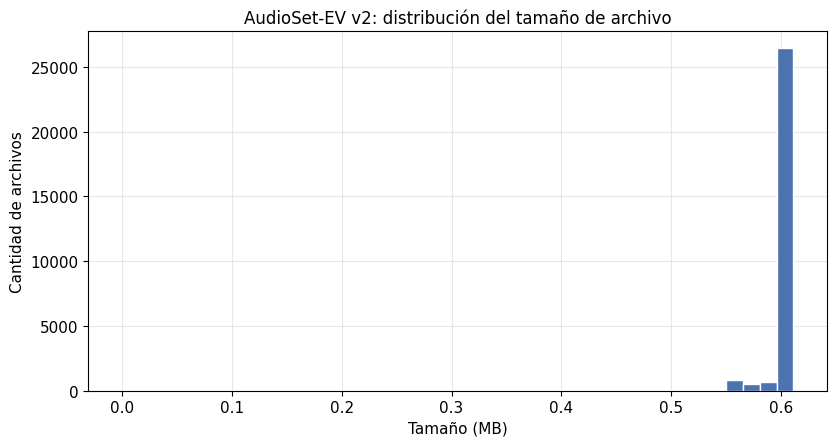

gráfico: /kaggle/working/dataset_audit/plots/file_size_audioset_ev.png


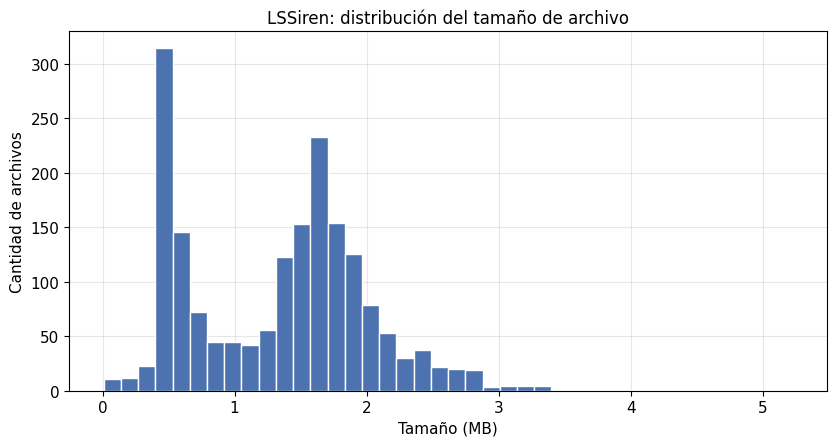

gráfico: /kaggle/working/dataset_audit/plots/file_size_lssiren.png


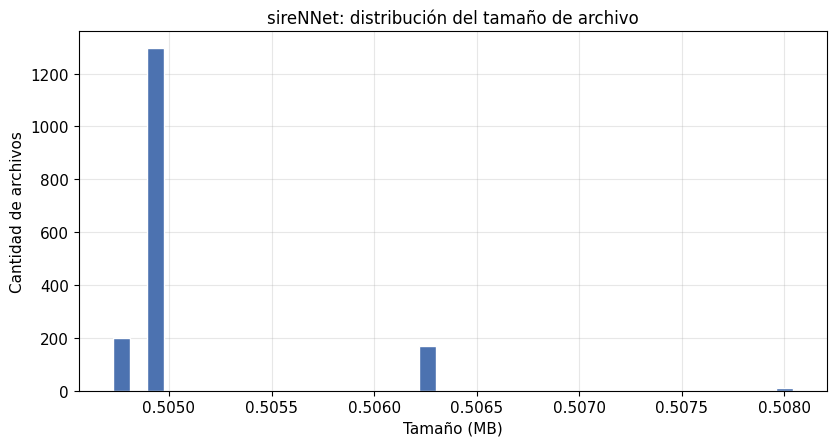

gráfico: /kaggle/working/dataset_audit/plots/file_size_sirennet.png


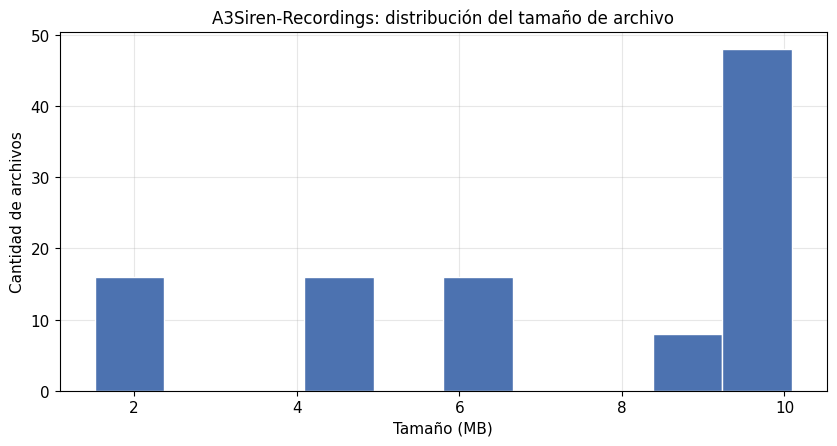

gráfico: /kaggle/working/dataset_audit/plots/file_size_a3siren.png


In [11]:
# section_03_inventory

def section_03_inventory() -> None:
    require_state("discovered")
    frames = [inventory_files(item) for item in _mounted_records()]
    usable = [frame for frame in frames if not frame.empty]
    inventory = pd.concat(usable, ignore_index=True) if usable else empty_frame(INVENTORY_COLUMNS + ["stat_error"])
    STATE["inventory"] = inventory
    export_columns = [column for column in INVENTORY_COLUMNS if column in inventory.columns]
    export_table(inventory[export_columns], "01_dataset_inventory.csv", EXPORT_ALIASES["01_dataset_inventory.csv"])
    show_df(inventory[export_columns])
    print(
        "possible_label_from_directory es el nombre de la carpeta inmediata. "
        "No es la etiqueta definitiva; label_raw se resuelve en la sección 05."
    )
    for item in detected_datasets():
        print(f"\nÁrbol recortado de {item['dataset']} (el conteo completo está en 02_folder_structure.csv):")
        print(format_tree(Path(item["root"])))
    plot_file_sizes(inventory)

section_03_inventory()


## 04. Estructura de carpetas

Árbol recortado para lectura y conteo completo de archivos de audio por carpeta, incluida la profundidad.


In [12]:
# section_04_folders

def section_04_folders() -> None:
    require_state("discovered")
    frames = [folder_structure(item) for item in _mounted_records()]
    usable = [frame for frame in frames if not frame.empty]
    folders = pd.concat(usable, ignore_index=True) if usable else empty_frame(FOLDER_COLUMNS)
    STATE["folders"] = folders
    export_table(folders, "02_folder_structure.csv", EXPORT_ALIASES["02_folder_structure.csv"])
    show_df(folders, n=40)
    if not folders.empty:
        depth = folders.groupby("dataset", sort=False)["depth"].max()
        print("Profundidad máxima observada:")
        display(depth.rename("max_depth").reset_index())

section_04_folders()


escrito: /kaggle/working/dataset_audit/02_folder_structure.csv
alias: /kaggle/working/dataset_audit/folder_structure.csv
filas: 41 | columnas: 4


,dataset,folder,file_count,depth
0,AudioSet-EV v2,.,0,0
1,AudioSet-EV v2,Negative_files,0,1
2,AudioSet-EV v2,Negative_files/balanced_train,10963,2
3,AudioSet-EV v2,Negative_files/eval,9953,2
4,AudioSet-EV v2,Positive_files,0,1
5,AudioSet-EV v2,Positive_files/balanced_train,135,2
6,AudioSet-EV v2,Positive_files/eval,135,2
7,AudioSet-EV v2,Positive_files/unbalanced,7630,2
8,LSSiren,.,0,0
9,LSSiren,Emergency Vehicle Sirens,932,1


Profundidad máxima observada:


,dataset,max_depth
0,AudioSet-EV v2,2
1,LSSiren,1
2,sireNNet,1
3,A3Siren-Recordings,2


## 05. Metadata y etiquetas

Cada CSV se abre sin suponer de antemano sus columnas. Se listan nombres, tipos, filas, nulos y valores observados. Las columnas que parecen identificadores, etiquetas, origen o tiempo se marcan como candidatas; el texto de la etiqueta no se reescribe.

En sireNNet, `ambulance`, `firetruck`, `police` y `traffic` son los nombres de carpeta observados. No se afirma que representen de forma universal ambulancia, bomberos, policía y no emergencia.

En A3Siren-Recordings, si está montado, tracks, segmentos y grabaciones largas se describen por separado. Un archivo largo no se trata como si fuera un clip corto independiente.


In [13]:
# section_05_metadata_and_labels

def section_05_metadata_and_labels() -> None:
    require_state("discovered", "inventory")
    inventory = STATE["inventory"]
    link_results: dict[str, list[dict]] = {}
    for item in _mounted_records():
        dataset_name = item["dataset"]
        link_results[dataset_name] = []
        if item["status"] != STATUS_MOUNTED:
            print(f"{dataset_name}: {item['status']}. {item['evidence']}")
            continue
        csv_paths = locate_expected_csvs(item)
        extra_csv = [
            path
            for path in find_metadata_files(Path(item["root"]))
            if path.suffix.lower() == ".csv" and path not in csv_paths
        ]
        print(f"\n{dataset_name}: CSV esperados encontrados={len(csv_paths)}; otros CSV={len(extra_csv)}")
        subset = inventory[inventory["dataset"] == dataset_name] if not inventory.empty else inventory
        for csv_path in csv_paths + extra_csv:
            metadata = read_metadata(csv_path)
            print(f"\nCSV {csv_path.name}: filas={len(metadata['frame'])}; encoding={metadata['encoding'] or 'n/a'}")
            if metadata["read_error"]:
                print(f"aviso de lectura: {metadata['read_error']}")
            if not metadata["profile"].empty:
                show_df(metadata["profile"], n=30)
                print("primeras filas, sin modificar valores:")
                show_df(metadata["frame"], n=5)
            linked = link_metadata_to_files(metadata, subset)
            linked["metadata"] = metadata
            link_results[dataset_name].append(linked)
            chosen = linked["chosen"]
            if chosen is None:
                print("No hubo estrategia que emparejara filas con archivos.")
            else:
                print(
                    f"Estrategia usada: columna `{chosen['column_name']}` por {chosen['strategy']} "
                    f"({chosen['matched_rows']} filas con archivo). "
                    f"Columna de etiqueta mostrada como label_raw si tiene valor: `{linked['label_column'] or 'ninguna'}`."
                )
            print(f"Filas sin archivo: {len(linked['unmatched_rows'])}. Coincidencias ambiguas: {len(linked['ambiguous'])}.")
        if item["dataset_id"] == "sirennet":
            print(
                "Las carpetas ambulance, firetruck, police y traffic se registran con el nombre observado. "
                "Esta notebook no afirma que representen de forma universal ambulancia, bomberos, policía y no emergencia."
            )
        if item["dataset_id"] == "a3siren":
            print(
                "A3Siren-Recordings se inventaría sin asumir que cada archivo es una muestra independiente. "
                "Tracks, segmentos y grabaciones largas quedan descritos por separado cuando la ruta o la duración lo indican."
            )
    STATE["link_results"] = link_results
    labels = resolve_labels(inventory, link_results)
    STATE["labels"] = labels
    show_df(labels)
    print("label_source queda vacío cuando no hay CSV, metadata ni carpeta estructural validada. No se usa INFERRED.")
    # build_family_reports()
    # summary_path = OUTPUT_ROOT / "audioset_ev_metadata_summary.md"
    # if summary_path.exists():
    #     show_markdown(summary_path.read_text(encoding="utf-8"))
    # pending_path = OUTPUT_ROOT / "a3siren_pending_report.md"
    # if pending_path.exists():
    #     show_markdown(pending_path.read_text(encoding="utf-8"))

section_05_metadata_and_labels()



AudioSet-EV v2: CSV esperados encontrados=2; otros CSV=0

CSV EV_Positives.csv: filas=8448; encoding=utf-8
filas: 6 | columnas: 7


,column_name,dtype,row_count,null_count,empty_string_count,nunique_non_empty,sample_values
0,yt_id,object,8448,0,0,8448,-4RWqM0UCCY | -Y1qiiugnk8 | -_dElQcyJnA | -gKN...
1,start_seconds,float64,8448,0,0,97,0.0 | 30.0 | 420.0 | 220.0 | 10.0 | 150.0 | 60...
2,end_seconds,float64,8448,0,0,105,10.0 | 40.0 | 430.0 | 230.0 | 20.0 | 160.0 | 7...
3,positive_labels,object,8448,0,0,889,"['/m/012n7d', '/m/02mfyn', '/m/03j1ly', '/m/03..."
4,segment_type,object,8448,0,0,3,balanced_train | eval | unbalanced_train
5,downloaded,bool,8448,0,0,2,True | False


primeras filas, sin modificar valores:
filas: 8448 | columnas: 6


,yt_id,start_seconds,end_seconds,positive_labels,segment_type,downloaded
0,-4RWqM0UCCY,0.0,10.0,"['/m/012n7d', '/m/02mfyn', '/m/03j1ly', '/m/03...",balanced_train,True
1,-Y1qiiugnk8,30.0,40.0,"['/m/012n7d', '/m/03j1ly', '/m/03kmc9']",balanced_train,True
2,-_dElQcyJnA,30.0,40.0,"['/m/012n7d', '/m/03j1ly', '/m/03kmc9', '/m/04...",balanced_train,True
3,-gKNRXbpAKs,30.0,40.0,"['/m/012n7d', '/m/03j1ly', '/m/03kmc9', '/m/0d...",balanced_train,True
4,-z47zN0YyE4,420.0,430.0,"['/m/012ndj', '/m/03j1ly', '/m/03kmc9']",balanced_train,True


Estrategia usada: columna `yt_id` por stem (7900 filas con archivo). Columna de etiqueta mostrada como label_raw si tiene valor: `positive_labels`.
Filas sin archivo: 548. Coincidencias ambiguas: 0.

CSV EV_Negatives.csv: filas=1794186; encoding=utf-8
filas: 6 | columnas: 7


...

primeras filas, sin modificar valores:
filas: 901 | columnas: 28


,road324.wav,0.4422033727169037,0.022000659257173538,2545.3467933724646,2426.479510207884,4754.282789963942,0.15518892728365385,-270.3846130371094,100.6190185546875,-10.223790168762207,...,17.983823776245117,-11.6962890625,18.793994903564453,-5.30555534362793,-0.9654150009155273,5.482495307922363,-10.139044761657715,-2.003446340560913,3.7363574504852295,Road
0,road508.wav,0.337758,0.206505,3470.430019,2706.420324,6899.114051,0.181979,11.297463,41.953815,-35.142498,...,13.245173,-2.812768,-0.847138,-7.962325,-2.489496,-5.065870,15.039159,-7.175189,2.037403,Road
1,road351.wav,0.440022,0.173755,1248.230706,1904.995271,2556.032621,0.020921,-134.684311,138.695663,-9.734646,...,12.647631,2.210467,9.100524,3.403701,8.452733,1.088790,4.929297,-0.253739,4.125893,Road
2,road703.wav,0.600494,0.040601,1075.899022,1827.481394,1814.793513,0.032874,-252.906036,157.615417,9.920370,...,9.185198,-4.017237,1.136444,-3.741317,3.954798,-0.935155,8.923501,3.227440,6.275182,Road
3,road681.wav,0.631075,0.065356,742.548260,1372.708521,1231.119479,0.023869,-257.946930,187.372162,7.777202,...,13.000937,2.262908,7.443036,-0.647730,2.444229,-2.062293,6.974404,1.464423,2.268083,Road
4,road220.wav,0.710645,0.193270,1228.842527,1819.664428,2488.534311,0.027945,-99.503242,148.012299,-7.427307,...,6.207716,1.539523,8.452557,-1.445114,10.421827,3.122327,4.044672,6.625712,6.937809,Road


Estrategia usada: columna `road324.wav` por filename (901 filas con archivo). Columna de etiqueta mostrada como label_raw si tiene valor: `ninguna`.
Filas sin archivo: 0. Coincidencias ambiguas: 0.

sireNNet: CSV esperados encontrados=0; otros CSV=0
Las carpetas ambulance, firetruck, police y traffic se registran con el nombre observado. Esta notebook no afirma que representen de forma universal ambulancia, bomberos, policía y no emergencia.

A3Siren-Recordings: CSV esperados encontrados=0; otros CSV=0
A3Siren-Recordings se inventaría sin asumir que cada archivo es una muestra independiente. Tracks, segmentos y grabaciones largas quedan descritos por separado cuando la ruta o la duración lo indican.
filas: 32429 | columnas: 6


,dataset,relative_path,label_raw,label_source,source_metadata_id,notes
0,AudioSet-EV v2,Negative_files/balanced_train/--PJHxphWEs.wav,"['/m/09x0r', '/t/dd00088']",CSV,--PJHxphWEs,etiqueta tomada de la columna positive_labels ...
1,AudioSet-EV v2,Negative_files/balanced_train/--aE2O5G5WE.wav,"['/m/03fwl', '/m/04rlf', '/m/09x0r']",CSV,--aE2O5G5WE,etiqueta tomada de la columna positive_labels ...
2,AudioSet-EV v2,Negative_files/balanced_train/--cB2ZVjpnA.wav,['/m/01y3hg'],CSV,--cB2ZVjpnA,etiqueta tomada de la columna positive_labels ...
3,AudioSet-EV v2,Negative_files/balanced_train/--ekDLDTUXA.wav,"['/m/015lz1', '/m/07pws3f']",CSV,--ekDLDTUXA,etiqueta tomada de la columna positive_labels ...
4,AudioSet-EV v2,Negative_files/balanced_train/-0DLPzsiXXE.wav,"['/m/04rlf', '/m/07qwdck']",CSV,-0DLPzsiXXE,etiqueta tomada de la columna positive_labels ...
5,AudioSet-EV v2,Negative_files/balanced_train/-0FHUc78Gqo.wav,"['/m/02w4v', '/m/04rlf']",CSV,-0FHUc78Gqo,etiqueta tomada de la columna positive_labels ...
6,AudioSet-EV v2,Negative_files/balanced_train/-0SdAVK79lg.wav,"['/m/0155w', '/m/01lyv', '/m/0342h', '/m/042v_...",CSV,-0SdAVK79lg,etiqueta tomada de la columna positive_labels ...
7,AudioSet-EV v2,Negative_files/balanced_train/-0mjrMposBM.wav,['/m/04zmvq'],CSV,-0mjrMposBM,etiqueta tomada de la columna positive_labels ...
8,AudioSet-EV v2,Negative_files/balanced_train/-11LhdJgBb8.wav,"['/m/04rlf', '/m/07qn4z3']",CSV,-11LhdJgBb8,etiqueta tomada de la columna positive_labels ...
9,AudioSet-EV v2,Negative_files/balanced_train/-1LrH01Ei1w.wav,"['/m/02p0sh1', '/m/04rlf']",CSV,-1LrH01Ei1w,etiqueta tomada de la columna positive_labels ...


label_source queda vacío cuando no hay CSV, metadata ni carpeta estructural validada. No se usa INFERRED.


## 06. Estadísticas de clases

Conteos y porcentajes de `label_raw` cuando la fuente es CSV, carpeta estructural o metadata. También se calculan la clase mínima, la clase máxima, la razón máximo/mínimo y el porcentaje de la clase dominante. Estas cifras no son una puntuación de calidad.


escrito: /kaggle/working/dataset_audit/04_class_distribution.csv
filas: 7756 | columnas: 11


,record_type,dataset,label_raw,label_source,count,percentage,class_min,class_max,max_min_ratio,dominant_class_percentage,notes
0,class,AudioSet-EV v2,"['/m/03j1ly', '/m/03kmc9', '/m/04qvtq']",CSV,1000,3.470294,,,NaN,NaN,label_raw conserva el texto observado
1,class,AudioSet-EV v2,"['/m/012n7d', '/m/03j1ly', '/m/03kmc9']",CSV,642,2.227929,,,NaN,NaN,label_raw conserva el texto observado
2,class,AudioSet-EV v2,"['/m/012ndj', '/m/03j1ly', '/m/03kmc9']",CSV,589,2.044003,,,NaN,NaN,label_raw conserva el texto observado
3,class,AudioSet-EV v2,"['/m/012n7d', '/m/03j1ly', '/m/03kmc9', '/m/04...",CSV,533,1.849667,,,NaN,NaN,label_raw conserva el texto observado
4,class,AudioSet-EV v2,['/m/04qvtq'],CSV,355,1.231954,,,NaN,NaN,label_raw conserva el texto observado
5,class,AudioSet-EV v2,"['/m/012ndj', '/m/03j1ly', '/m/07r04', '/m/07y...",CSV,241,0.836341,,,NaN,NaN,label_raw conserva el texto observado
6,class,AudioSet-EV v2,['/m/012ndj'],CSV,176,0.610772,,,NaN,NaN,label_raw conserva el texto observado
7,class,AudioSet-EV v2,"['/m/012ndj', '/m/03j1ly', '/m/07yv9']",CSV,167,0.579539,,,NaN,NaN,label_raw conserva el texto observado
8,class,AudioSet-EV v2,"['/m/03kmc9', '/m/04qvtq']",CSV,149,0.517074,,,NaN,NaN,label_raw conserva el texto observado
9,class,AudioSet-EV v2,"['/m/03j1ly', '/m/03kmc9']",CSV,126,0.437257,,,NaN,NaN,label_raw conserva el texto observado


El porcentaje usa como denominador los archivos con label_raw recuperada. No es una puntuación de calidad ni un orden entre datasets.


/tmp/ipykernel_58/2991798409.py:173: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


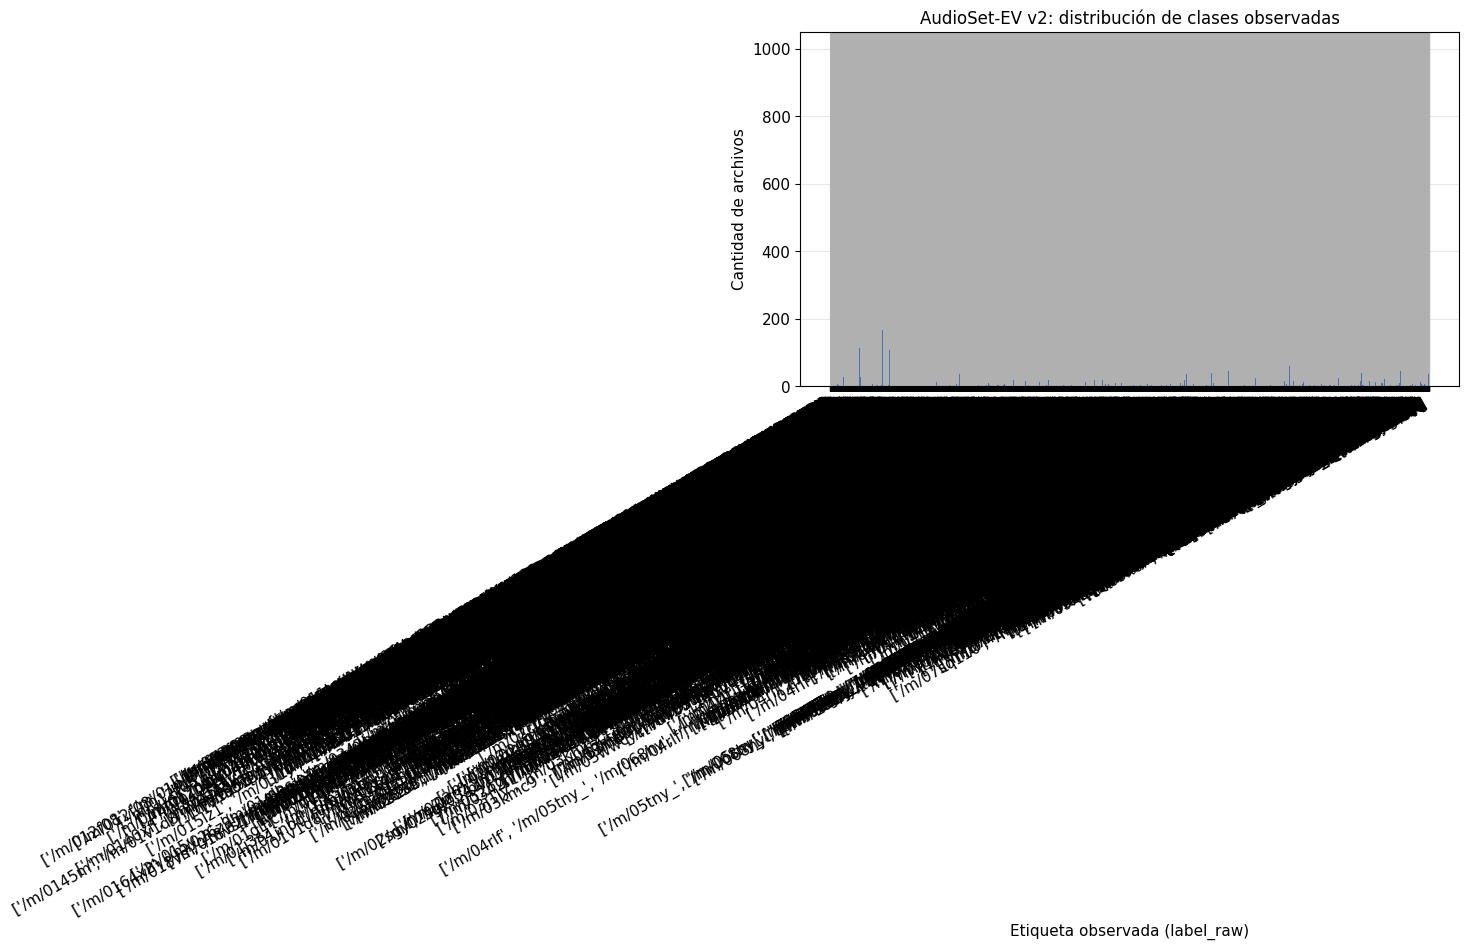

gráfico: /kaggle/working/dataset_audit/plots/class_distribution_audioset_ev.png


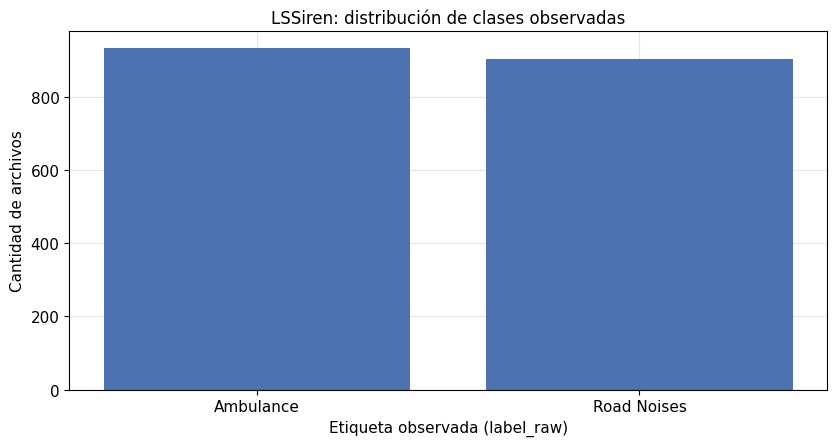

gráfico: /kaggle/working/dataset_audit/plots/class_distribution_lssiren.png


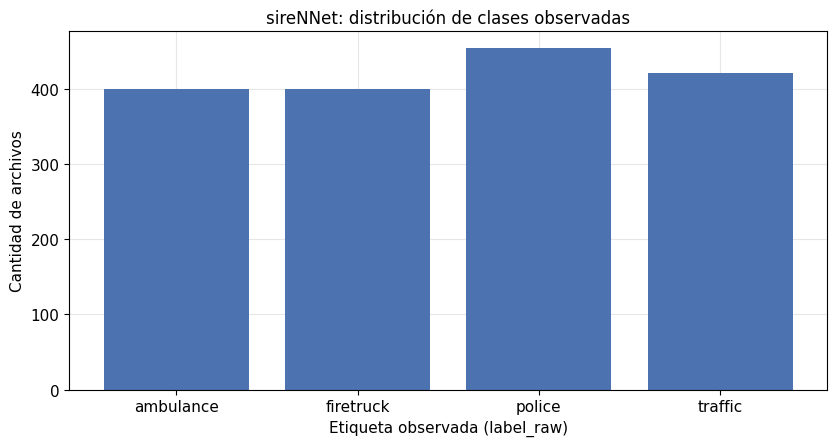

gráfico: /kaggle/working/dataset_audit/plots/class_distribution_sirennet.png
sin etiquetas recuperadas para graficar: A3Siren-Recordings


In [14]:
# section_06_class_statistics

def section_06_class_statistics() -> None:
    require_state("labels")
    distribution = analyze_class_distribution(STATE["labels"])
    STATE["class_distribution"] = distribution
    export_table(distribution, "04_class_distribution.csv")
    show_df(distribution, n=50)
    print(
        "El porcentaje usa como denominador los archivos con label_raw recuperada. "
        "No es una puntuación de calidad ni un orden entre datasets."
    )
    plot_class_distributions(distribution)

section_06_class_statistics()


## 07. Propiedades técnicas del audio

Para cada archivo válido se intenta obtener, sin cargar la señal completa, la frecuencia de muestreo, los canales, la duración, los frames, el formato y el subtipo o la profundidad cuando la librería los expone. Primero se usa `soundfile.info`. Si falla, se intenta `ffprobe`.


In [15]:
# section_07_audio_properties

def section_07_audio_properties() -> None:
    require_state("inventory")
    audio = collect_audio_metadata(STATE["inventory"])
    STATE["audio"] = audio
    export_table(audio, "03_audio_metadata.csv", EXPORT_ALIASES["03_audio_metadata.csv"])
    show_df(audio)
    print("La duración, el sampling rate y los canales salen de la cabecera. No se cargó el waveform completo.")
    # build_family_reports()

section_07_audio_properties()


cabeceras de audio:   0%|          | 0/32429 [00:00<?, ?it/s]

escrito: /kaggle/working/dataset_audit/03_audio_metadata.csv
alias: /kaggle/working/dataset_audit/audio_metadata.csv
filas: 32429 | columnas: 12


,dataset,relative_path,filename,sampling_rate_hz,channels,duration_seconds,frames,format,subtype,file_size_bytes,read_status,error_message
0,AudioSet-EV v2,Negative_files/balanced_train/--PJHxphWEs.wav,--PJHxphWEs.wav,32000,1,10.000625,320020,WAV,PCM_16,640118,OK,
1,AudioSet-EV v2,Negative_files/balanced_train/--aE2O5G5WE.wav,--aE2O5G5WE.wav,32000,1,10.000656,320021,WAV,PCM_16,640120,OK,
2,AudioSet-EV v2,Negative_files/balanced_train/--cB2ZVjpnA.wav,--cB2ZVjpnA.wav,32000,1,10.000000,320000,WAV,PCM_16,640078,OK,
3,AudioSet-EV v2,Negative_files/balanced_train/--ekDLDTUXA.wav,--ekDLDTUXA.wav,32000,1,10.000000,320000,WAV,PCM_16,640078,OK,
4,AudioSet-EV v2,Negative_files/balanced_train/-0DLPzsiXXE.wav,-0DLPzsiXXE.wav,32000,1,10.000000,320000,WAV,PCM_16,640078,OK,
5,AudioSet-EV v2,Negative_files/balanced_train/-0FHUc78Gqo.wav,-0FHUc78Gqo.wav,32000,1,9.999469,319983,WAV,PCM_16,640044,OK,
6,AudioSet-EV v2,Negative_files/balanced_train/-0SdAVK79lg.wav,-0SdAVK79lg.wav,32000,1,10.000000,320000,WAV,PCM_16,640078,OK,
7,AudioSet-EV v2,Negative_files/balanced_train/-0mjrMposBM.wav,-0mjrMposBM.wav,32000,1,9.999406,319981,WAV,PCM_16,640040,OK,
8,AudioSet-EV v2,Negative_files/balanced_train/-11LhdJgBb8.wav,-11LhdJgBb8.wav,32000,1,9.999844,319995,WAV,PCM_16,640068,OK,
9,AudioSet-EV v2,Negative_files/balanced_train/-1LrH01Ei1w.wav,-1LrH01Ei1w.wav,32000,1,10.000969,320031,WAV,PCM_16,640140,OK,


La duración, el sampling rate y los canales salen de la cabecera. No se cargó el waveform completo.


## 08. Calidad e integridad

Cada archivo queda en `OK`, `WARNING` o `ERROR`. Un error de lectura, un archivo vacío, una duración no positiva, un sampling rate inválido o un número de canales inválido es `ERROR`. Una inconsistencia entre frames y duración, o una nota de cabecera, es `WARNING`. No se borra ni se corrige nada.


In [16]:
# section_08_quality

def section_08_quality() -> None:
    require_state("audio")
    quality = validate_dataset(STATE["audio"])
    STATE["quality"] = quality
    export_table(quality, "05_quality_report.csv", EXPORT_ALIASES["05_quality_report.csv"])
    if quality.empty:
        print("Sin archivos de audio para clasificar.")
        return
    print(quality["quality_status"].value_counts().rename("archivos").to_string())
    errors = quality[quality["quality_status"] == "ERROR"]
    warnings = quality[quality["quality_status"] == "WARNING"]
    print(f"ERROR: {len(errors)}. WARNING: {len(warnings)}. OK: {int((quality['quality_status'] == 'OK').sum())}.")
    print("Ningún archivo se elimina ni se corrige.")
    if not errors.empty:
        show_df(errors)

section_08_quality()


escrito: /kaggle/working/dataset_audit/05_quality_report.csv
alias: /kaggle/working/dataset_audit/quality_report.csv
quality_status
OK       32427
ERROR        2
ERROR: 2. WARNING: 0. OK: 32427.
Ningún archivo se elimina ni se corrige.
filas: 2 | columnas: 11


,dataset,relative_path,filename,quality_status,issue_codes,duration_seconds,sampling_rate_hz,channels,frames,file_size_bytes,error_message
19129,AudioSet-EV v2,Negative_files/eval/mW3S0u8bj58.wav,mW3S0u8bj58.wav,ERROR,non_positive_duration,0.0,32000,1,0,78,
26277,AudioSet-EV v2,Positive_files/unbalanced/eqnveHA0hrI.wav,eqnveHA0hrI.wav,ERROR,non_positive_duration,0.0,32000,1,0,78,


## 09. Duración

Para cada dataset se calculan conteo, mínimo, máximo, media, mediana, desviación estándar, p25, p75 y p95 sobre los archivos utilizables. Hay un histograma independiente por dataset.


escrito: /kaggle/working/dataset_audit/duration_summary.csv
filas: 4 | columnas: 10


,dataset,count,min,max,mean,median,std,p25,p75,p95
0,AudioSet-EV v2,28814,0.97525,10.010906,9.904945,10.000000,0.482174,10.000000,10.000000,10.000562
1,LSSiren,1834,0.05000,28.544000,7.867959,8.734524,3.497353,3.890034,10.167698,12.999467
2,sireNNet,1675,3.00000,3.018594,3.000950,3.000000,0.002763,3.000000,3.000091,3.007982
3,A3Siren-Recordings,104,9.00000,60.000000,43.038462,53.000000,19.181769,26.000000,60.000000,60.000000


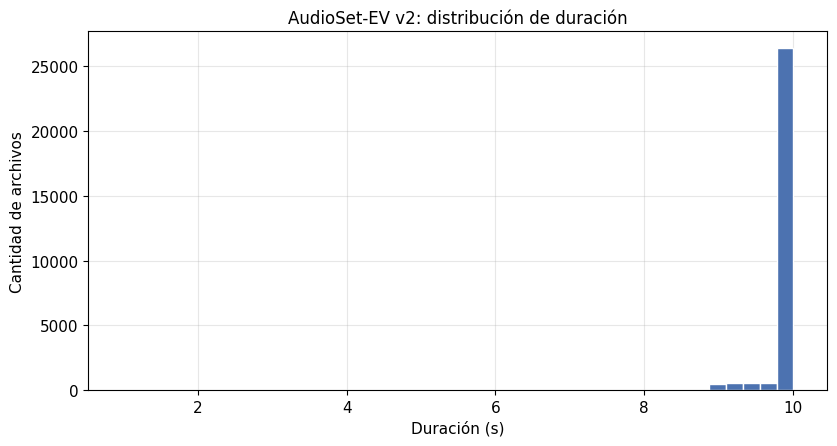

gráfico: /kaggle/working/dataset_audit/plots/duration_audioset_ev.png


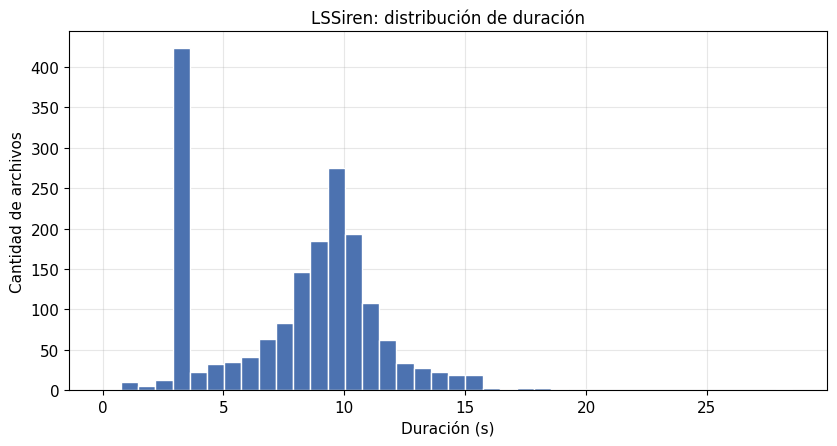

gráfico: /kaggle/working/dataset_audit/plots/duration_lssiren.png


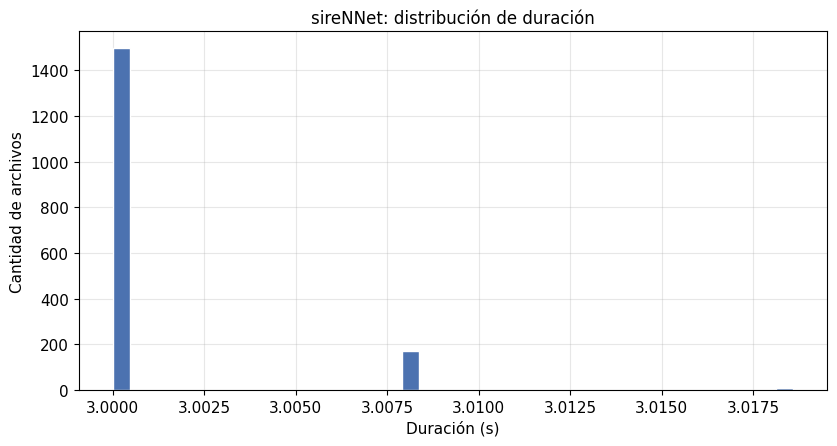

gráfico: /kaggle/working/dataset_audit/plots/duration_sirennet.png


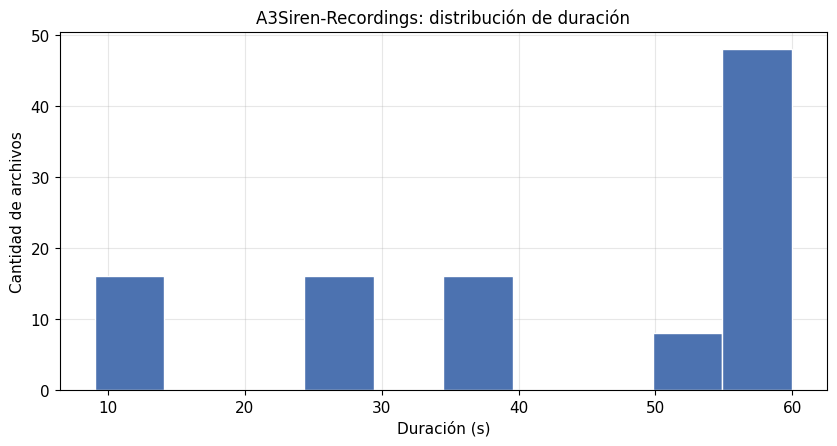

gráfico: /kaggle/working/dataset_audit/plots/duration_a3siren.png


In [17]:
# section_09_duration

def section_09_duration() -> None:
    require_state("audio", "quality")
    summary = analyze_duration(STATE["audio"], STATE["quality"])
    STATE["duration_summary"] = summary
    export_table(summary, "duration_summary.csv")
    show_df(summary)
    plot_duration_histograms(STATE["audio"], STATE["quality"])

section_09_duration()


## 10. Análisis de sampling rate y canales

Se muestran los valores únicos, su frecuencia y su porcentaje. Varios valores dentro del mismo dataset indican heterogeneidad interna. Los canales se describen como mono, estéreo o multicanal, y también con el número real de canales. No se normaliza ni se convierte ningún archivo.


escrito: /kaggle/working/dataset_audit/sampling_rate_distribution.csv
escrito: /kaggle/working/dataset_audit/channel_distribution.csv
Sampling rate observado. No se remuestrea ningún archivo.
filas: 8 | columnas: 5


,dataset,sampling_rate_hz,count,percentage,heterogeneous
0,AudioSet-EV v2,32000,28814,100.000000,False
1,LSSiren,8000,5,0.272628,True
2,LSSiren,22050,6,0.327154,True
3,LSSiren,44100,1130,61.613959,True
4,LSSiren,48000,691,37.677208,True
5,LSSiren,96000,2,0.109051,True
6,sireNNet,44100,1675,100.000000,False
7,A3Siren-Recordings,44100,104,100.000000,False


Hay heterogeneidad interna de sampling rate en al menos un dataset.
Canales observados. No se convierte estéreo a mono.
filas: 5 | columnas: 5


,dataset,channels,layout,count,percentage
0,AudioSet-EV v2,1,mono,28814,100.000000
1,LSSiren,1,mono,152,8.287895
2,LSSiren,2,stereo,1682,91.712105
3,sireNNet,2,stereo,1675,100.000000
4,A3Siren-Recordings,1,mono,104,100.000000


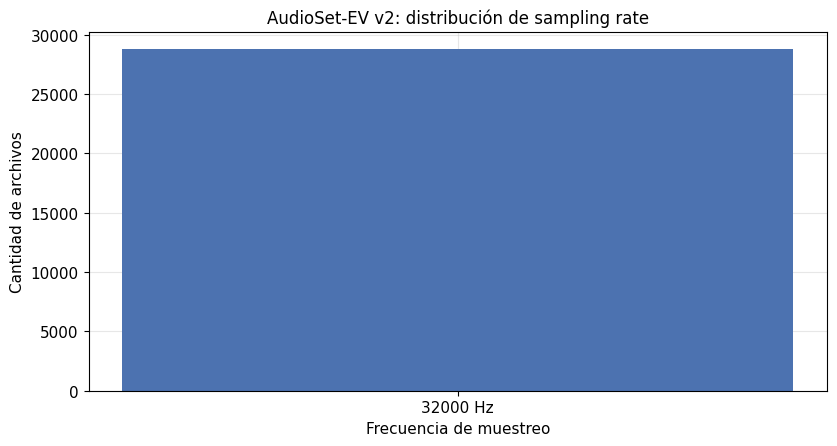

gráfico: /kaggle/working/dataset_audit/plots/sampling_rate_audioset_ev.png


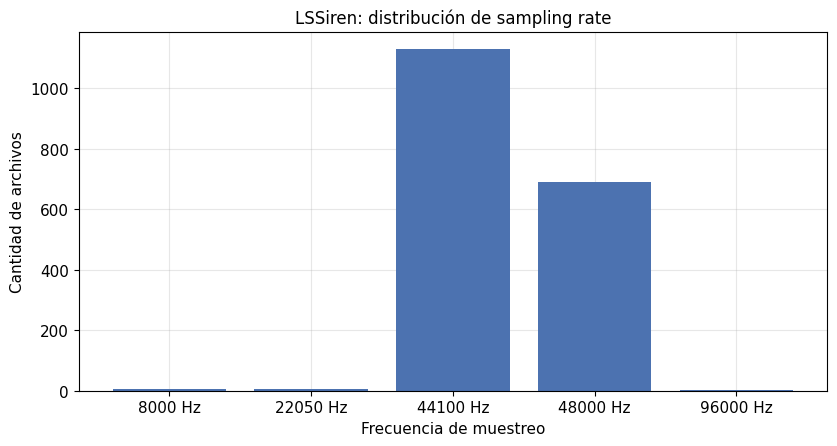

gráfico: /kaggle/working/dataset_audit/plots/sampling_rate_lssiren.png


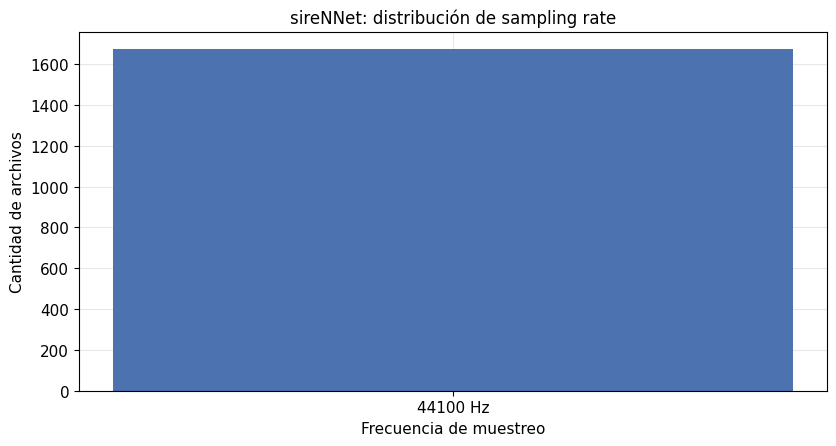

gráfico: /kaggle/working/dataset_audit/plots/sampling_rate_sirennet.png


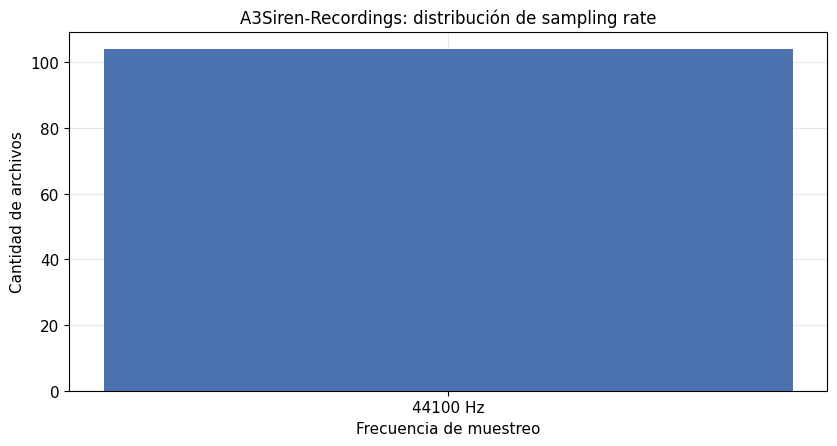

gráfico: /kaggle/working/dataset_audit/plots/sampling_rate_a3siren.png


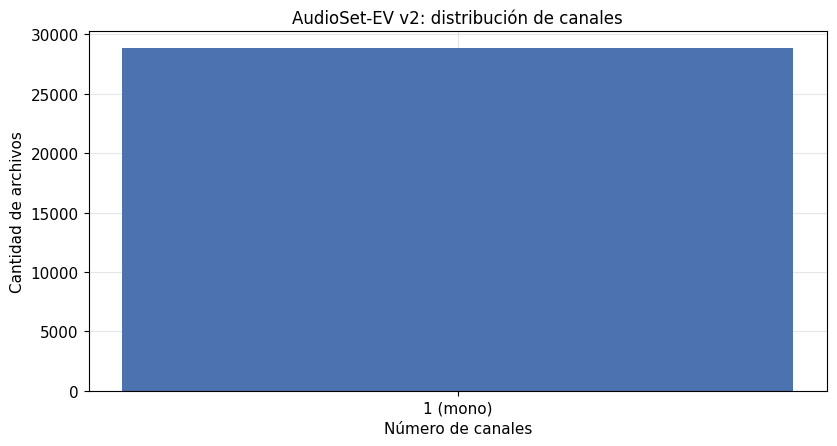

gráfico: /kaggle/working/dataset_audit/plots/channels_audioset_ev.png


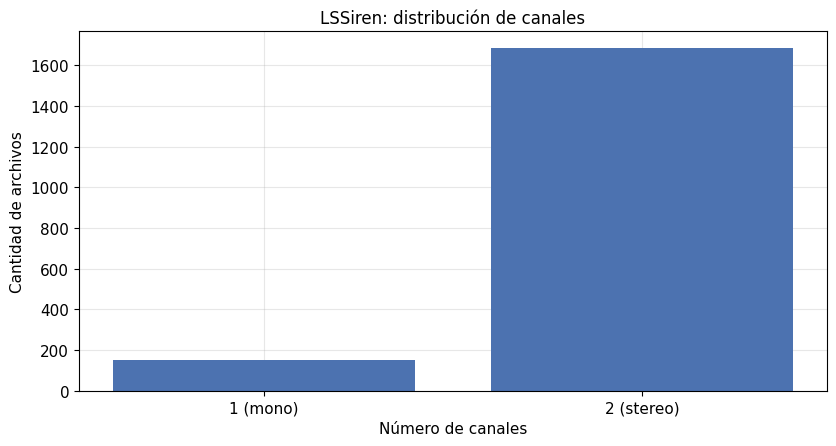

gráfico: /kaggle/working/dataset_audit/plots/channels_lssiren.png


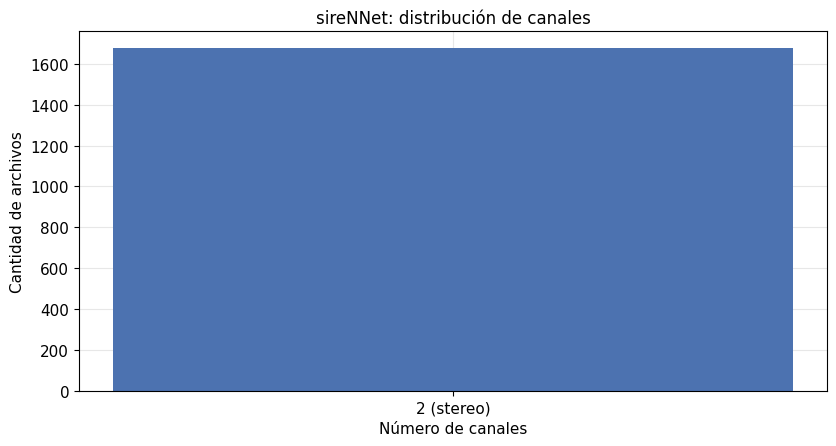

gráfico: /kaggle/working/dataset_audit/plots/channels_sirennet.png


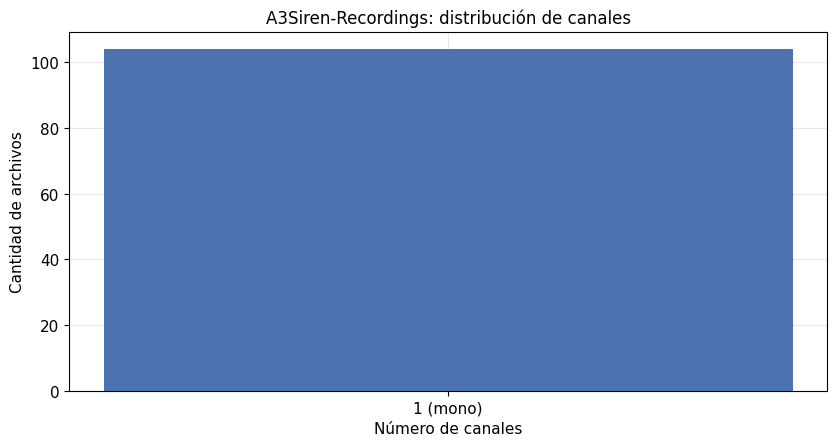

gráfico: /kaggle/working/dataset_audit/plots/channels_a3siren.png


In [18]:
# section_10_sampling_and_channels

def section_10_sampling_and_channels() -> None:
    require_state("audio", "quality")
    sampling = analyze_sampling_rate(STATE["audio"], STATE["quality"])
    channels = analyze_channels(STATE["audio"], STATE["quality"])
    STATE["sampling_distribution"] = sampling
    STATE["channel_distribution"] = channels
    export_table(sampling, "sampling_rate_distribution.csv")
    export_table(channels, "channel_distribution.csv")
    print("Sampling rate observado. No se remuestrea ningún archivo.")
    show_df(sampling)
    if not sampling.empty and sampling["heterogeneous"].any():
        print("Hay heterogeneidad interna de sampling rate en al menos un dataset.")
    else:
        print("No se observó más de un sampling rate dentro de un mismo dataset, entre los archivos utilizables.")
    print("Canales observados. No se convierte estéreo a mono.")
    show_df(channels)
    plot_sampling_rates(sampling)
    plot_channel_distributions(channels)

section_10_sampling_and_channels()


## 11. Detección de duplicados

Los duplicados internos son coincidencias exactas de SHA-256 del archivo completo. El hash se calcula por bloques. También se informan los hashes únicos, los archivos que caen en un grupo duplicado y el porcentaje sobre el inventario.


In [20]:
# section_11_internal_duplicates

def section_11_internal_duplicates() -> None:
    require_state("inventory")
    hashes = compute_hashes(STATE["inventory"])
    groups, summary = detect_duplicates(hashes)
    STATE["hashes"] = hashes
    STATE["duplicate_groups"] = groups
    STATE["duplicate_summary"] = summary
    export_table(groups, "06_duplicate_groups.csv", EXPORT_ALIASES["06_duplicate_groups.csv"])
    export_table(summary, "duplicate_summary.csv")
    show_df(summary)
    show_df(groups)
    print("El porcentaje duplicado usa como numerador los archivos que pertenecen a un grupo de hash repetido.")
    # build_family_reports()

section_11_internal_duplicates()


sha256:   0%|          | 0/32429 [00:00<?, ?it/s]

escrito: /kaggle/working/dataset_audit/06_duplicate_groups.csv
alias: /kaggle/working/dataset_audit/duplicate_groups_internal.csv
escrito: /kaggle/working/dataset_audit/duplicate_summary.csv
filas: 4 | columnas: 7


,dataset,unique_hashes,duplicate_files,duplicate_percentage,files_hashed,hash_errors,excess_copies
0,AudioSet-EV v2,28795,35,0.121460,28816,0,21
1,LSSiren,1693,281,15.321701,1834,0,141
2,sireNNet,1667,16,0.955224,1675,0,8
3,A3Siren-Recordings,104,0,0.000000,104,0,0


filas: 162 | columnas: 5


,dataset,hash_sha256,duplicate_group_id,file_count,file_paths
0,AudioSet-EV v2,228406ad706db67f71abae4819acb4a1b890a1b3cd0a23...,audioset_ev-0001,2,Positive_files/eval/n6SvDBZaCUQ.wav | Positive...
1,AudioSet-EV v2,2358bdd0a74a5ffad35a7e2d59bcd54244f419ba0e9068...,audioset_ev-0002,2,Negative_files/eval/iROgD3JRJFY.wav | Negative...
2,AudioSet-EV v2,7312955456acee0f0f4bb4f8f910343e720529de76f952...,audioset_ev-0003,2,Negative_files/balanced_train/QISuRTvc-nE.wav ...
3,AudioSet-EV v2,73a3637ed3402a151bbe90b924adabc2b01cd656225df3...,audioset_ev-0004,2,Negative_files/eval/Ob9iaGon5ak.wav | Negative...
4,AudioSet-EV v2,80d4f6f25445a96101617aff848365e6365468a8673874...,audioset_ev-0005,2,Positive_files/unbalanced/RyxdPdTcny0.wav | Po...
5,AudioSet-EV v2,87ab8e2e52041b2e3ddef6e614fb5cd94abe0ab7af1328...,audioset_ev-0006,2,Positive_files/unbalanced/6wAVcD4J1EE.wav | Po...
6,AudioSet-EV v2,8c9b73051ec73073221baa7270b2be6bfc6c1eff8c9697...,audioset_ev-0007,4,Negative_files/eval/-1II0Di9Hkc.wav | Negative...
7,AudioSet-EV v2,901b76a21b3e0d3ed0e89d97fbae7afb7846fcff2e18a0...,audioset_ev-0008,7,Negative_files/balanced_train/2VqKshkkHLU.wav ...
8,AudioSet-EV v2,94b9d9c177ccddff79d4c431f138afc0090262372cfaa7...,audioset_ev-0009,2,Negative_files/balanced_train/UikrYQmCYf0.wav ...
9,AudioSet-EV v2,befd4eddaa5d91c07449b37dbab6da6ca1c9de204aa66e...,audioset_ev-0010,2,Negative_files/balanced_train/5gq7O5yLl6M.wav ...


El porcentaje duplicado usa como numerador los archivos que pertenecen a un grupo de hash repetido.


## 12. Análisis de posibles archivos aumentados

Se buscan indicios en nombres, columnas y valores de metadata. La confianza `HIGH` exige que la metadata documente una transformación. `MEDIUM` corresponde a un patrón de nombre sistemático. `LOW` es un indicio débil y no basta para contar el archivo como aumentado. Un nombre parecido, por sí solo, no convierte un archivo en una copia aumentada.


In [21]:
# section_12_augmentation

def section_12_augmentation() -> None:
    require_state("inventory", "link_results")
    augmentation = analyze_augmentation(STATE["inventory"], STATE["link_results"])
    STATE["augmentation"] = augmentation
    STATE["augmentation_files"] = augmentation_by_file(augmentation)
    export_table(augmentation, "08_augmentation_evidence.csv", EXPORT_ALIASES["08_augmentation_evidence.csv"])
    show_df(augmentation)
    print(
        "HIGH exige un valor de metadata que documenta una transformación. "
        "MEDIUM es un patrón sistemático en el nombre. "
        "LOW es un indicio débil y no entra en possible_augmented_files."
    )
    show_df(STATE["augmentation_files"])

section_12_augmentation()


escrito: /kaggle/working/dataset_audit/08_augmentation_evidence.csv
alias: /kaggle/working/dataset_audit/augmentation_evidence.csv
filas: 0 | columnas: 6
(tabla vacía)
HIGH exige un valor de metadata que documenta una transformación. MEDIUM es un patrón sistemático en el nombre. LOW es un indicio débil y no entra en possible_augmented_files.
filas: 0 | columnas: 3
(tabla vacía)


## 13. Consistencia audio ↔ metadata

Cuando hay CSV, se comparan los archivos reales con las filas. Se registran registros sin archivo, archivos sin registro, identificadores repetidos, nombres repetidos, filas duplicadas y diferencias de extensión o de ruta. Las diferencias se informan; no se corrigen.


In [22]:
# section_13_consistency

def section_13_consistency() -> None:
    require_state("inventory", "link_results")
    consistency = check_metadata_consistency(STATE["inventory"], STATE["link_results"])
    STATE["consistency"] = consistency
    export_table(consistency, "09_metadata_audio_consistency.csv", EXPORT_ALIASES["09_metadata_audio_consistency.csv"])
    show_df(consistency, n=40)
    if not consistency.empty:
        print(consistency["issue_type"].value_counts().rename("filas").to_string())

section_13_consistency()


escrito: /kaggle/working/dataset_audit/09_metadata_audio_consistency.csv
alias: /kaggle/working/dataset_audit/metadata_audio_consistency.csv
filas: 1773821 | columnas: 6


,dataset,issue_type,csv_path,audio_path,record_id,details
0,AudioSet-EV v2,csv_missing_audio,/kaggle/input/datasets/jeancdevx/audioset-ev/E...,,4APBvMmKubU,sin archivo correspondiente
1,AudioSet-EV v2,csv_missing_audio,/kaggle/input/datasets/jeancdevx/audioset-ev/E...,,ALjgoKbg4h4,sin archivo correspondiente
2,AudioSet-EV v2,csv_missing_audio,/kaggle/input/datasets/jeancdevx/audioset-ev/E...,,DKFz6eMHLfI,sin archivo correspondiente
3,AudioSet-EV v2,csv_missing_audio,/kaggle/input/datasets/jeancdevx/audioset-ev/E...,,ZVDtuzPVlgU,sin archivo correspondiente
4,AudioSet-EV v2,csv_missing_audio,/kaggle/input/datasets/jeancdevx/audioset-ev/E...,,_RUKvt068Po,sin archivo correspondiente
5,AudioSet-EV v2,csv_missing_audio,/kaggle/input/datasets/jeancdevx/audioset-ev/E...,,bo_KcZvGHJw,sin archivo correspondiente
6,AudioSet-EV v2,csv_missing_audio,/kaggle/input/datasets/jeancdevx/audioset-ev/E...,,jZnLtcRKxss,sin archivo correspondiente
7,AudioSet-EV v2,csv_missing_audio,/kaggle/input/datasets/jeancdevx/audioset-ev/E...,,osFCx4URNyk,sin archivo correspondiente
8,AudioSet-EV v2,csv_missing_audio,/kaggle/input/datasets/jeancdevx/audioset-ev/E...,,t1_81iXEZys,sin archivo correspondiente
9,AudioSet-EV v2,csv_missing_audio,/kaggle/input/datasets/jeancdevx/audioset-ev/E...,,w1Kb6BNXJQg,sin archivo correspondiente


issue_type
csv_missing_audio    1773818
no_csv                     2
audio_missing_csv          1


## 14. Anomalías acústicas básicas

Sobre una muestra reproducible de hasta 40 archivos por dataset se calculan RMS, amplitud pico, proporción de clipping y proporción aproximada de silencio. La muestra usa la semilla fija y se estratifica por `possible_label_from_directory`.

Estos números son controles de calidad. No son las características finales del modelo. No se calculan MFCC ni cientos de descriptores. En archivos más largos que 180 s, las métricas usan los primeros 180 s y la tabla lo indica.


Esta muestra calcula RMS, pico, proporción de clipping y proporción de silencio. Son controles de calidad. No son las características finales del modelo, no son MFCC y no describen el dataset completo salvo cuando el dataset tiene menos archivos que la muestra.


qc AudioSet-EV v2:   0%|          | 0/40 [00:00<?, ?it/s]

qc LSSiren:   0%|          | 0/40 [00:00<?, ?it/s]

qc sireNNet:   0%|          | 0/40 [00:00<?, ?it/s]

qc A3Siren-Recordings:   0%|          | 0/40 [00:00<?, ?it/s]

escrito: /kaggle/working/dataset_audit/acoustic_qc_sample.csv
filas: 160 | columnas: 12


,dataset,relative_path,filename,rms,peak_amplitude,clipping_ratio,silence_ratio,analysis_window_seconds,file_duration_seconds,read_status,error_message,notes
0,AudioSet-EV v2,Negative_files/balanced_train/2rJn94itrBo.wav,2rJn94itrBo.wav,0.084238,0.999969,0.000006,0.048403,10.000000,10.000000,OK,,métricas calculadas sobre los canales concaten...
1,AudioSet-EV v2,Negative_files/balanced_train/2zukaXFwhdA.wav,2zukaXFwhdA.wav,0.079295,1.000000,0.000006,0.325078,10.000000,10.000000,OK,,métricas calculadas sobre los canales concaten...
2,AudioSet-EV v2,Negative_files/balanced_train/3ClGkzfArh8.wav,3ClGkzfArh8.wav,0.029827,0.269562,0.000000,0.404456,10.000000,10.000000,OK,,métricas calculadas sobre los canales concaten...
3,AudioSet-EV v2,Negative_files/balanced_train/95MSkigqNQE.wav,95MSkigqNQE.wav,0.401768,1.000000,0.000953,0.019050,10.000000,10.000000,OK,,métricas calculadas sobre los canales concaten...
4,AudioSet-EV v2,Negative_files/balanced_train/NQdJhE3JIaI.wav,NQdJhE3JIaI.wav,0.068174,0.594910,0.000000,0.223866,10.000000,10.000000,OK,,métricas calculadas sobre los canales concaten...
5,AudioSet-EV v2,Negative_files/balanced_train/NsR60ehkHGA.wav,NsR60ehkHGA.wav,0.127922,0.497681,0.000000,0.031469,10.000000,10.000000,OK,,métricas calculadas sobre los canales concaten...
6,AudioSet-EV v2,Negative_files/balanced_train/UK5KeNr1eWE.wav,UK5KeNr1eWE.wav,0.021014,0.359589,0.000000,0.899053,10.000000,10.000000,OK,,métricas calculadas sobre los canales concaten...
7,AudioSet-EV v2,Negative_files/balanced_train/bsz_enSJSVk.wav,bsz_enSJSVk.wav,0.204028,0.900543,0.000000,0.063366,10.000000,10.000000,OK,,métricas calculadas sobre los canales concaten...
8,AudioSet-EV v2,Negative_files/balanced_train/f-6QHVgMeC8.wav,f-6QHVgMeC8.wav,0.131030,0.769409,0.000000,0.320309,10.000000,10.000000,OK,,métricas calculadas sobre los canales concaten...
9,AudioSet-EV v2,Negative_files/balanced_train/gOOtp-74_B0.wav,gOOtp-74_B0.wav,0.028030,0.354218,0.000000,0.420416,10.000000,10.000000,OK,,métricas calculadas sobre los canales concaten...


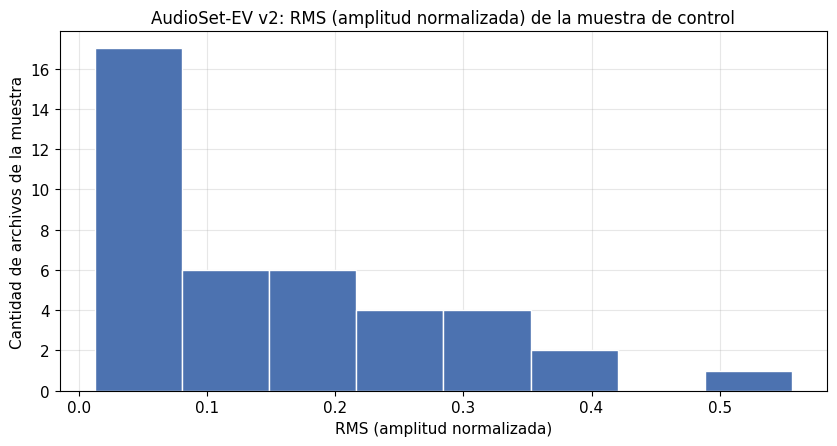

gráfico: /kaggle/working/dataset_audit/plots/rms_sample_audioset_ev.png


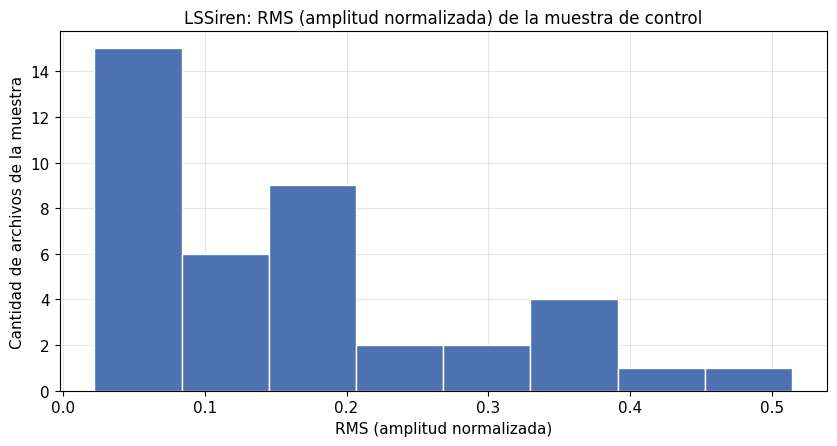

gráfico: /kaggle/working/dataset_audit/plots/rms_sample_lssiren.png


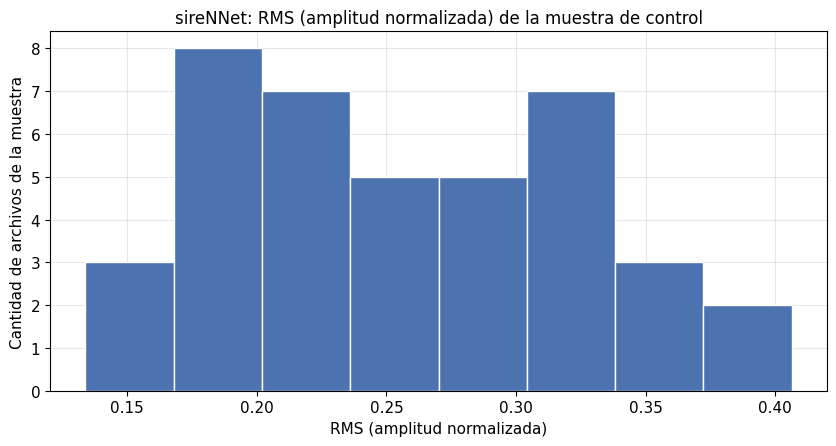

gráfico: /kaggle/working/dataset_audit/plots/rms_sample_sirennet.png


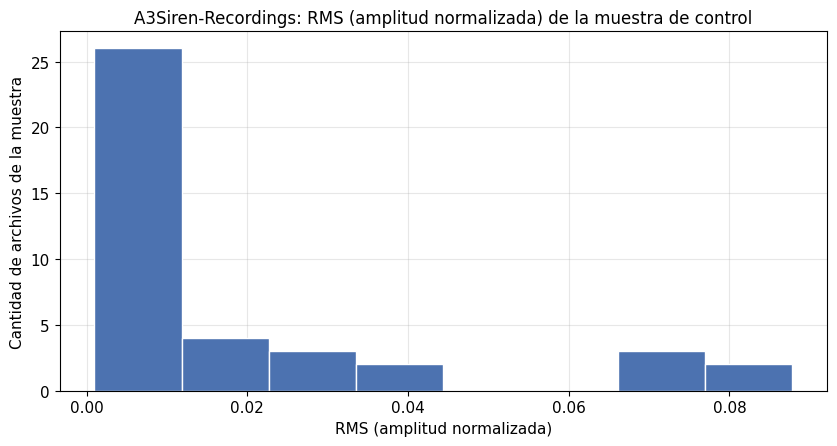

gráfico: /kaggle/working/dataset_audit/plots/rms_sample_a3siren.png


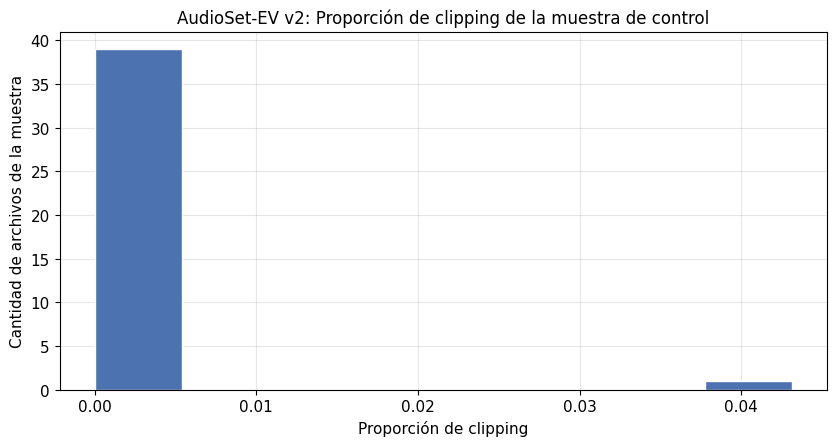

gráfico: /kaggle/working/dataset_audit/plots/clipping_ratio_audioset_ev.png


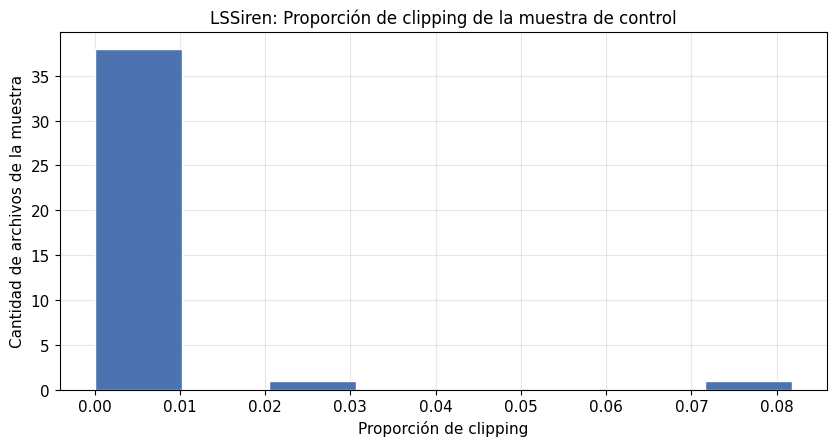

gráfico: /kaggle/working/dataset_audit/plots/clipping_ratio_lssiren.png


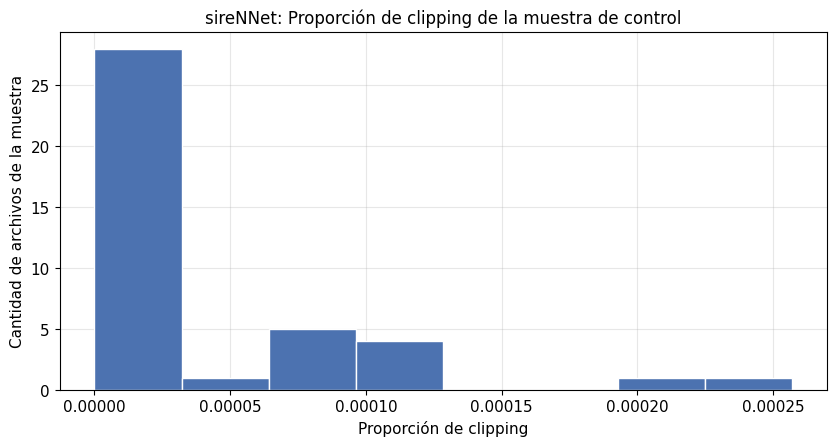

gráfico: /kaggle/working/dataset_audit/plots/clipping_ratio_sirennet.png


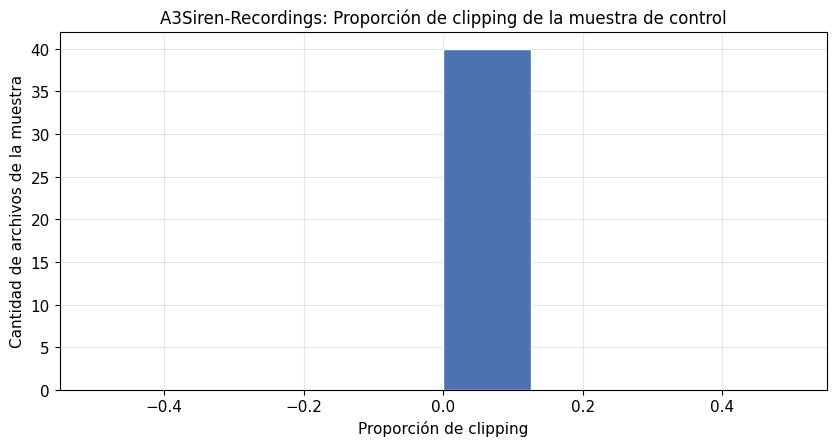

gráfico: /kaggle/working/dataset_audit/plots/clipping_ratio_a3siren.png


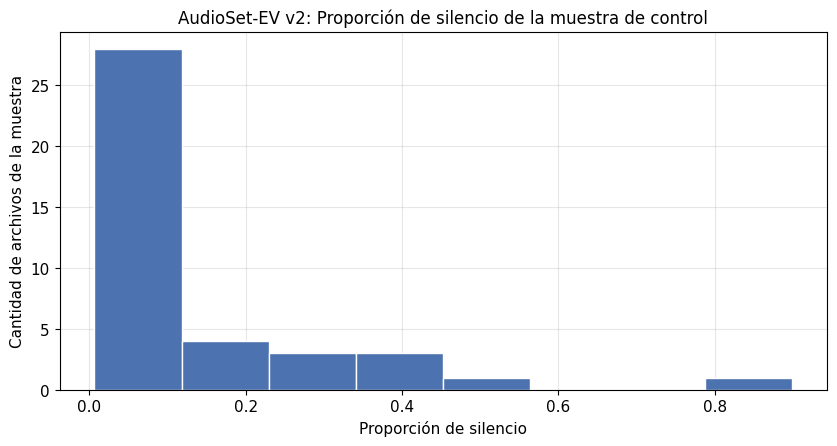

gráfico: /kaggle/working/dataset_audit/plots/silence_ratio_audioset_ev.png


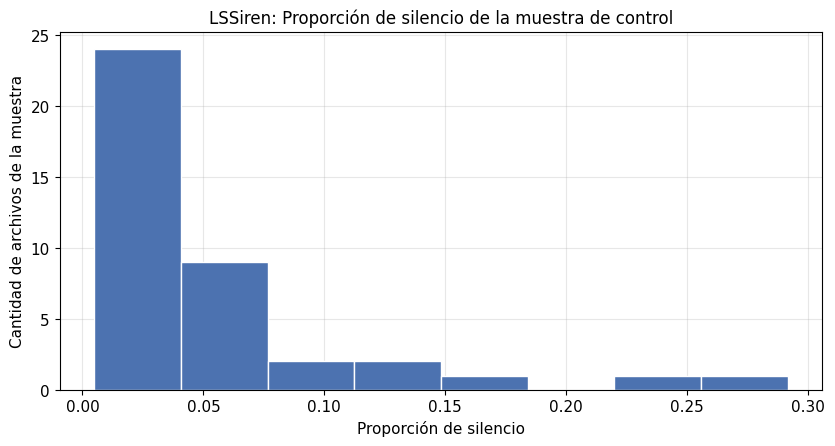

gráfico: /kaggle/working/dataset_audit/plots/silence_ratio_lssiren.png


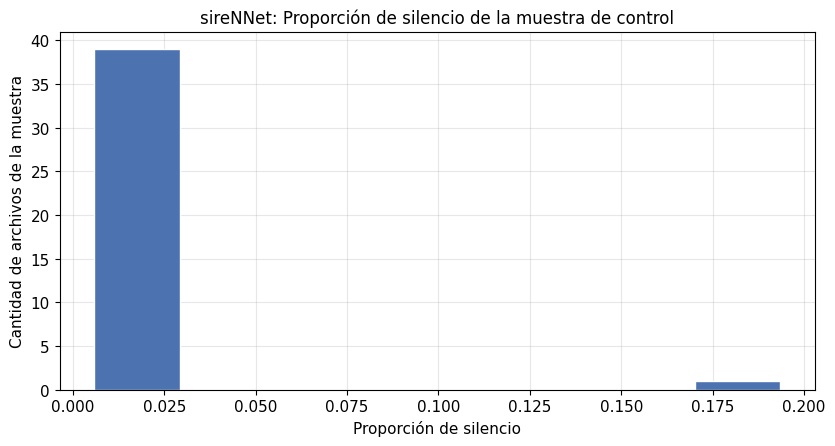

gráfico: /kaggle/working/dataset_audit/plots/silence_ratio_sirennet.png


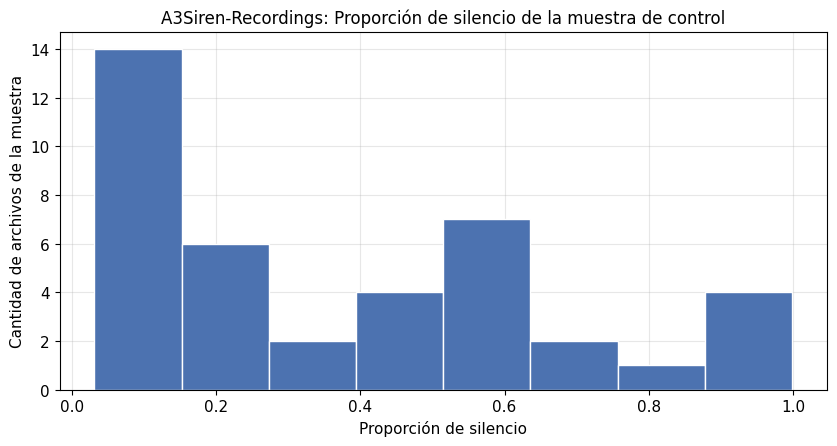

gráfico: /kaggle/working/dataset_audit/plots/silence_ratio_a3siren.png


In [23]:
# section_14_acoustic_qc

def section_14_acoustic_qc() -> None:
    require_state("inventory")
    print(
        "Esta muestra calcula RMS, pico, proporción de clipping y proporción de silencio. "
        "Son controles de calidad. No son las características finales del modelo, no son MFCC "
        "y no describen el dataset completo salvo cuando el dataset tiene menos archivos que la muestra."
    )
    sample = collect_acoustic_sample(STATE["inventory"])
    STATE["acoustic"] = sample
    export_table(sample, "acoustic_qc_sample.csv")
    show_df(sample)
    plot_acoustic_metric(sample, "rms", "RMS (amplitud normalizada)", "rms_sample")
    plot_acoustic_metric(sample, "clipping_ratio", "Proporción de clipping", "clipping_ratio")
    plot_acoustic_metric(sample, "silence_ratio", "Proporción de silencio", "silence_ratio")

section_14_acoustic_qc()


## 15. Comparación entre datasets

La tabla sigue el orden fijo AudioSet-EV v2, LSSiren, sireNNet, A3Siren-Recordings. No está ordenada de mejor a peor y no incluye una puntuación. Las columnas de solapamiento y de riesgo de fuga se completan en las secciones 16 y 17; el CSV final se reescribe en la sección 20.


In [24]:
# section_15_comparison

def section_15_comparison() -> None:
    require_state("inventory", "quality", "class_distribution", "duration_summary")
    summary = build_global_summary()
    STATE["global_summary"] = summary
    print(
        "Tabla descriptiva en el orden fijo AudioSet-EV v2, LSSiren, sireNNet, A3Siren-Recordings. "
        "No está ordenada de mejor a peor y no tiene puntuación."
    )
    print(
        "possible_overlap_count y leakage_risk se completan después de las secciones 16 y 17. "
        "El CSV final se reescribe en la sección 20."
    )
    show_df(summary)

section_15_comparison()


Tabla descriptiva en el orden fijo AudioSet-EV v2, LSSiren, sireNNet, A3Siren-Recordings. No está ordenada de mejor a peor y no tiene puntuación.
possible_overlap_count y leakage_risk se completan después de las secciones 16 y 17. El CSV final se reescribe en la sección 20.
filas: 4 | columnas: 16


,dataset,total_files,valid_files,invalid_files,classes,duration_min,duration_median,duration_mean,duration_max,sampling_rates,channels,duplicate_files,missing_metadata,possible_augmented_files,possible_overlap_count,leakage_risk
0,AudioSet-EV v2,28816,28814,2,"['/g/122z_qxw', '/m/012n7d', '/m/09x0r'] [CSV]...",0.97525,10.000000,9.904945,10.010906,32000 Hz=28814 (100.0%),1 mono=28814 (100.0%),35,archivos sin registro CSV=0; registros CSV sin...,0,0,UNRESOLVED
1,LSSiren,1834,1834,0,Ambulance [CSV]=932; Road Noises [DIRECTORY]=902,0.05000,8.734524,7.867959,28.544000,8000 Hz=5 (0.3%); 22050 Hz=6 (0.3%); 44100 Hz=...,1 mono=152 (8.3%); 2 stereo=1682 (91.7%),281,archivos sin registro CSV=1; registros CSV sin...,0,0,UNRESOLVED
2,sireNNet,1675,1675,0,ambulance [DIRECTORY]=400; firetruck [DIRECTOR...,3.00000,3.000000,3.000950,3.018594,44100 Hz=1675 (100.0%),2 stereo=1675 (100.0%),16,sin CSV de metadata; archivos de audio=1675,0,0,UNRESOLVED
3,A3Siren-Recordings,104,104,0,sin etiqueta recuperada,9.00000,53.000000,43.038462,60.000000,44100 Hz=104 (100.0%),1 mono=104 (100.0%),0,sin CSV de metadata; archivos de audio=104,0,0,UNRESOLVED


## 16. Posible solapamiento entre datasets

`EXACT_MATCH` exige el mismo SHA-256. `POSSIBLE_MATCH` puede deberse a una firma técnica poco común (duración, sampling rate, frames y tamaño), a un identificador de origen compartido o a un nombre normalizado igual. Esa similitud no declara que los audios sean iguales.

Si muchos archivos comparten la misma firma técnica, la fila se marca como no discriminativa y no entra en el conteo de coincidencias potenciales. `NO_EVIDENCE` significa que esas comprobaciones no encontraron un candidato; no demuestra que el contenido sea disjunto.


In [25]:
# section_16_overlap

def section_16_overlap() -> None:
    require_state("inventory", "audio", "hashes", "labels")
    overlap = detect_cross_dataset_overlap(
        STATE["inventory"],
        STATE["audio"],
        STATE["hashes"],
        STATE["labels"],
    )
    STATE["overlap"] = overlap
    export_table(overlap, "07_cross_dataset_overlap.csv", EXPORT_ALIASES["07_cross_dataset_overlap.csv"])
    show_df(overlap, n=30)
    if overlap.empty:
        counted = 0
    else:
        counted = int(overlap.apply(overlap_is_counted, axis=1).sum())
    print(f"Filas contadas como coincidencia potencial: {counted}.")
    print(
        "Ese conteo excluye la firma técnica no discriminativa y las filas NO_EVIDENCE. "
        "NO_EVIDENCE no afirma que el contenido sea disjunto."
    )

section_16_overlap()


escrito: /kaggle/working/dataset_audit/07_cross_dataset_overlap.csv
alias: /kaggle/working/dataset_audit/cross_dataset_overlap.csv
filas: 6 | columnas: 8


,dataset_a,dataset_b,match_type,match_basis,evidence,path_a,path_b,notes
0,LSSiren,sireNNet,POSSIBLE_MATCH,technical_signature_nondiscriminative,grupos=1; archivos_LSSiren=1; archivos_sireNNe...,,,"varios archivos comparten duración, sampling r..."
1,AudioSet-EV v2,LSSiren,NO_EVIDENCE,none,"sin hash común, sin identificador de origen co...",,,la ausencia de estas coincidencias no demuestr...
2,AudioSet-EV v2,sireNNet,NO_EVIDENCE,none,"sin hash común, sin identificador de origen co...",,,la ausencia de estas coincidencias no demuestr...
3,AudioSet-EV v2,A3Siren-Recordings,NO_EVIDENCE,none,"sin hash común, sin identificador de origen co...",,,la ausencia de estas coincidencias no demuestr...
4,LSSiren,A3Siren-Recordings,NO_EVIDENCE,none,"sin hash común, sin identificador de origen co...",,,la ausencia de estas coincidencias no demuestr...
5,sireNNet,A3Siren-Recordings,NO_EVIDENCE,none,"sin hash común, sin identificador de origen co...",,,la ausencia de estas coincidencias no demuestr...


Filas contadas como coincidencia potencial: 0.
Ese conteo excluye la firma técnica no discriminativa y las filas NO_EVIDENCE. NO_EVIDENCE no afirma que el contenido sea disjunto.


## 17. Riesgos de leakage

El informe clasifica evidencias como `LOW RISK`, `MEDIUM RISK`, `HIGH RISK` o `UNRESOLVED`. Un mismo hash en particiones distintas, o el mismo archivo en dos datasets, es una evidencia alta. Un identificador de origen repetido es una evidencia media. La ausencia de carpetas train/test deja ese vector en `UNRESOLVED`.

Ninguna fila afirma que un experimento ya haya filtrado datos. El nivel resumido de cada dataset es el riesgo concreto más alto; si solo hay filas `UNRESOLVED`, el resumen queda `UNRESOLVED`.


In [26]:
# section_17_leakage

def section_17_leakage() -> None:
    require_state("inventory", "hashes", "labels", "augmentation", "overlap")
    leakage = analyze_leakage_risk(
        STATE["inventory"],
        STATE["hashes"],
        STATE["labels"],
        STATE["augmentation"],
        STATE["overlap"],
    )
    STATE["leakage"] = leakage
    export_table(leakage, "10_leakage_risk_report.csv", EXPORT_ALIASES["10_leakage_risk_report.csv"])
    write_text("leakage_risk_summary.md", leakage_summary_markdown())
    show_df(leakage, n=40)
    show_markdown(leakage_summary_markdown())
    print("Los niveles describen evidencia de riesgo. No declaran que ya exista fuga en un entrenamiento.")

section_17_leakage()


escrito: /kaggle/working/dataset_audit/10_leakage_risk_report.csv
alias: /kaggle/working/dataset_audit/leakage_risk_report.csv
escrito: /kaggle/working/dataset_audit/leakage_risk_summary.md
filas: 166 | columnas: 6


,dataset,risk_level,risk_type,evidence,file_or_group,notes
0,AudioSet-EV v2,UNRESOLVED,train_test_partition,"no se encontraron carpetas train, test o valid...",,no se declara fuga; tampoco se puede descartar...
1,AudioSet-EV v2,MEDIUM RISK,internal_exact_duplicates,hash 228406ad706db67f71abae4819acb4a1b890a1b3c...,Positive_files/eval/n6SvDBZaCUQ.wav | Positive...,duplicados exactos dentro del dataset; habría ...
2,AudioSet-EV v2,MEDIUM RISK,internal_exact_duplicates,hash 2358bdd0a74a5ffad35a7e2d59bcd54244f419ba0...,Negative_files/eval/iROgD3JRJFY.wav | Negative...,duplicados exactos dentro del dataset; habría ...
3,AudioSet-EV v2,MEDIUM RISK,internal_exact_duplicates,hash 7312955456acee0f0f4bb4f8f910343e720529de7...,Negative_files/balanced_train/QISuRTvc-nE.wav ...,duplicados exactos dentro del dataset; habría ...
4,AudioSet-EV v2,MEDIUM RISK,internal_exact_duplicates,hash 73a3637ed3402a151bbe90b924adabc2b01cd6562...,Negative_files/eval/Ob9iaGon5ak.wav | Negative...,duplicados exactos dentro del dataset; habría ...
5,AudioSet-EV v2,MEDIUM RISK,internal_exact_duplicates,hash 80d4f6f25445a96101617aff848365e6365468a86...,Positive_files/unbalanced/RyxdPdTcny0.wav | Po...,duplicados exactos dentro del dataset; habría ...
6,AudioSet-EV v2,MEDIUM RISK,internal_exact_duplicates,hash 87ab8e2e52041b2e3ddef6e614fb5cd94abe0ab7a...,Positive_files/unbalanced/6wAVcD4J1EE.wav | Po...,duplicados exactos dentro del dataset; habría ...
7,AudioSet-EV v2,MEDIUM RISK,internal_exact_duplicates,hash 8c9b73051ec73073221baa7270b2be6bfc6c1eff8...,Negative_files/eval/-1II0Di9Hkc.wav | Negative...,duplicados exactos dentro del dataset; habría ...
8,AudioSet-EV v2,MEDIUM RISK,internal_exact_duplicates,hash 901b76a21b3e0d3ed0e89d97fbae7afb7846fcff2...,Negative_files/balanced_train/2VqKshkkHLU.wav ...,duplicados exactos dentro del dataset; habría ...
9,AudioSet-EV v2,MEDIUM RISK,internal_exact_duplicates,hash 94b9d9c177ccddff79d4c431f138afc0090262372...,Negative_files/balanced_train/UikrYQmCYf0.wav ...,duplicados exactos dentro del dataset; habría ...


# Riesgo de leakage — resumen

Cada fila es una evidencia observada. El informe no afirma que un split de entrenamiento ya esté contaminado.

Orden del nivel resumido por dataset: HIGH RISK sobre MEDIUM RISK sobre LOW RISK. UNRESOLVED se usa cuando no hay un riesgo concreto.

## AudioSet-EV v2

Nivel resumido: MEDIUM RISK.

- MEDIUM RISK: 14 filas.
- UNRESOLVED: 1 filas.

## LSSiren

Nivel resumido: MEDIUM RISK.

- MEDIUM RISK: 140 filas.
- UNRESOLVED: 1 filas.

## sireNNet

Nivel resumido: MEDIUM RISK.

- MEDIUM RISK: 8 filas.
- UNRESOLVED: 1 filas.

## A3Siren-Recordings

Nivel resumido: UNRESOLVED.

- UNRESOLVED: 1 filas.


Los niveles describen evidencia de riesgo. No declaran que ya exista fuga en un entrenamiento.


## 18. Resumen de hallazgos

El texto **Resumen de la Auditoría Física** se redacta solo con conteos y mediciones de esta corrida.


In [ ]:
# section_18_findings

def section_18_findings() -> None:
    require_state("discovered", "inventory", "quality")
    refresh_derived_tables()
    text = generate_summary()
    STATE["audit_summary"] = text
    show_markdown(text)

section_18_findings()


Generado desde los artefactos de la corrida, porque la celda 18 no terminó.

# Resumen de la Auditoría Física

Este texto se redactó a partir de las tablas y de los outputs de las secciones 01 a 17 de la corrida en Kaggle del 2026-09-29T23:50:02Z. Las secciones 18, 19 y 20 no terminaron: al regenerar informes vuelven a recorrer `EV_Negatives.csv` (1 794 186 filas) y la celda no llegó a escribir este resumen. Los números de abajo salen de los CSV que sí se exportaron. No se elige un dataset principal, no se ordenan los datasets y no se propone un modelo.

Semilla de la muestra acústica: 42. Python 3.12.13. Plataforma Linux 6.12.90. Librerías registradas: numpy 2.0.2, pandas 2.3.3, matplotlib 3.10.0, soundfile 0.13.1, tqdm 4.67.3.

## 1. Datasets detectados

Se detectaron los cuatro datasets. No quedó ninguno pendiente.

- AudioSet-EV v2: raíz `/kaggle/input/datasets/jeancdevx/audioset-ev`. Evidencia: `EV_Positives.csv` y `EV_Negatives.csv`, junto con las carpetas `Positive_files` y `Negative_files`. Archivos de audio: 28 816.
- LSSiren: raíz `/kaggle/input/datasets/jeancdevx/lssiren/lssiren`. Evidencia: `Ambulance_final.csv` y `Road_final.csv`, junto con las carpetas `Emergency Vehicle Sirens` y `Road Noises`. Archivos de audio: 1 834.
- sireNNet: la tabla impresa truncó la raíz en `/kaggle/input/datasets/jeancdevx/sirennet/sire...`. La evidencia registrada son las subcarpetas directas `ambulance`, `firetruck`, `police` y `traffic`. Archivos de audio: 1 675.
- A3Siren-Recordings: raíz `/kaggle/input/datasets/jeancdevx/a3s-rec`. Evidencia: el nombre de carpeta `a3s-rec`. Archivos de audio: 104.

No aparecieron otros montajes en `/kaggle/input` fuera de estas cuatro familias. Todos los archivos inventariados son `.wav`: 32 429 en total.

## 2. Número real de archivos

| Dataset | Archivos | Lectura utilizable (OK o WARNING) | ERROR |
|---|---:|---:|---:|
| AudioSet-EV v2 | 28 816 | 28 814 | 2 |
| LSSiren | 1 834 | 1 834 | 0 |
| sireNNet | 1 675 | 1 675 | 0 |
| A3Siren-Recordings | 104 | 104 | 0 |
| Total | 32 429 | 32 427 | 2 |

La cabecera se pudo leer en los 32 429 archivos (`read_status` OK en `03_audio_metadata.csv`). Los dos ERROR son de duración no positiva, no de archivo ilegible. Ver la sección 8.

## 3. Clases reales

Las etiquetas se conservan como aparecieron. No se tradujeron identificadores de AudioSet ni los nombres de carpeta de sireNNet.

**AudioSet-EV v2.** `label_raw` es el texto de la columna `positive_labels`, con `label_source` CSV, en los 28 816 archivos. Hay 7 746 cadenas distintas. La más frecuente, `['/m/03j1ly', '/m/03kmc9', '/m/04qvtq']`, tiene 1 000 archivos (3,47 %). Le siguen `['/m/012n7d', '/m/03j1ly', '/m/03kmc9']` con 642 y `['/m/012ndj', '/m/03j1ly', '/m/03kmc9']` con 589. La razón máximo/mínimo es 1 000: la combinación menos frecuente tiene 1 archivo. 5 379 combinaciones aparecen una sola vez y 6 900 aparecen cinco veces o menos. Esas cadenas son el valor crudo del CSV; esta auditoría no las convierte en nombres de vehículo.

Las carpetas, que no son `label_raw`, cuentan así en `02_folder_structure.csv`:

- `Positive_files/balanced_train`: 135
- `Positive_files/eval`: 135
- `Positive_files/unbalanced`: 7 630
- `Negative_files/balanced_train`: 10 963
- `Negative_files/eval`: 9 953

Positivos montados: 7 900. Negativos montados: 20 916.

**LSSiren.** Dos etiquetas, con fuentes distintas:

- `Ambulance`, tomada de la columna `label` de `Ambulance_final.csv`: 932 archivos (50,82 %).
- `Road Noises`, tomada del nombre de carpeta: 902 archivos (49,18 %).

`Road_final.csv` no trae fila de encabezado. Pandas usó la primera fila de datos como nombres de columna (`road324.wav`, valores numéricos y una columna llamada `Road`). Por eso la estrategia de enlace fue la columna `road324.wav` y no se usó una columna de etiqueta. Los 901 registros enlazados no aportaron `label_raw`; los 902 archivos de `Road Noises` quedaron con la etiqueta de carpeta. `road324.wav` es el archivo sin fila CSV.

**sireNNet.** No hay CSV. Las etiquetas son los nombres de carpeta observados. No se afirma que representen de forma universal ambulancia, bomberos, policía y no emergencia.

- `police`: 454 (27,10 %)
- `traffic`: 421 (25,13 %)
- `ambulance`: 400 (23,88 %)
- `firetruck`: 400 (23,88 %)

Razón máximo/mínimo: 1,135.

**A3Siren-Recordings.** `04_class_distribution.csv` no recuperó `label_raw`: 104 archivos sin etiqueta según esa regla. La estructura de carpetas sí está medida. Hay ocho carpetas `ch1` … `ch8`. Dentro de cada una hay `Siren` (7 archivos) y `Noise` (6 archivos). En el inventario, `possible_label_from_directory` vale `Siren` en 56 archivos y `Noise` en 48. Esos nombres no se promovieron a etiqueta definitiva.

Los 104 archivos corresponden a 13 nombres base, y cada nombre base aparece una vez en cada canal. Seis bases empiezan por `n-` y están en `Noise`. Siete empiezan por `s-` y están en `Siren`. Las bases observadas son `n-20210506-1652`, `n-20210506-1714`, `n-20210507-1421`, `n-20210507-1426`, `n-20210507-1536`, `n-20210507-1640`, `s-20210506-1652`, `s-20210506-1714`, `s-20210506-1714_1`, `s-20210507-1421`, `s-20210507-1426`, `s-20210507-1536` y `s-20210507-1640`. Cada archivo es mono. No se observó un WAV de 8 canales.

## 4. Balance

Estas cifras describen conteos. No son una puntuación de calidad.

- AudioSet-EV v2: 7 746 combinaciones; la dominante es el 3,47 %; 5 379 combinaciones tienen un solo archivo.
- LSSiren: `Ambulance` 50,82 % y `Road Noises` 49,18 %. Razón 1,033. Las dos fuentes de etiqueta no son la misma.
- sireNNet: la carpeta mayor (`police`) es el 27,10 %. Razón 1,135.
- A3Siren-Recordings: sin `label_raw`. En carpetas, `Siren` 56 y `Noise` 48, repartidos de forma idéntica en los ocho canales.

## 5. Sampling rates

Sobre archivos utilizables, en `sampling_rate_distribution.csv`:

- AudioSet-EV v2: 32 000 Hz en los 28 814 archivos con duración positiva. Un solo valor.
- LSSiren: heterogéneo. 44 100 Hz en 1 130 (61,6 %), 48 000 Hz en 691 (37,7 %), 22 050 Hz en 6, 8 000 Hz en 5 y 96 000 Hz en 2.
- sireNNet: 44 100 Hz en los 1 675.
- A3Siren-Recordings: 44 100 Hz en los 104.

No se remuestreó ningún archivo.

## 6. Canales

En `channel_distribution.csv`, contando archivos utilizables:

- AudioSet-EV v2: 1 canal (mono) en los 28 814.
- LSSiren: 2 canales en 1 682 (91,7 %) y 1 canal en 152 (8,3 %).
- sireNNet: 2 canales en los 1 675.
- A3Siren-Recordings: 1 canal en los 104. El canal no está dentro del archivo: está en el nombre de carpeta `ch1` … `ch8` y en el sufijo del nombre (`-ch1`, `-ch2`, …).

Subtipo, en `03_audio_metadata.csv`:

- AudioSet-EV v2: WAV PCM_16 en los 28 816, incluidos los dos de duración cero.
- LSSiren: PCM_16 en 1 791, PCM_24 en 33, PCM_32 en 6 y FLOAT en 4.
- sireNNet: WAV PCM_16 en los 1 675.
- A3Siren-Recordings: WAV FLOAT en los 104.

## 7. Distribución de duración

Sobre archivos con duración positiva, en `duration_summary.csv`. Unidad: segundos.

- AudioSet-EV v2 (n = 28 814): mínimo 0,97525; mediana 10; media 9,905; máximo 10,011; p25 = p75 = 10; p95 = 10,001. 21 382 archivos miden exactamente 10 s y 26 120 están entre 9,9 y 10,1 s.
- LSSiren (n = 1 834): mínimo 0,05; mediana 8,735; media 7,868; máximo 28,544; p25 = 3,890; p75 = 10,168; p95 = 12,999.
- sireNNet (n = 1 675): mínimo 3; mediana 3; media 3,001; máximo 3,019. Las cuatro carpetas tienen mediana 3 s.
- A3Siren-Recordings (n = 104): mínimo 9; mediana 53; media 43,038; máximo 60; p25 = 26; p75 = p95 = 60.

En A3, los 48 archivos de `Noise` duran 60 s. Los 56 de `Siren` duran 9, 10, 25, 26, 38, 38,5 o 53 s, con 8 archivos en cada una de esas duraciones (uno por canal).

Los histogramas están en `plots/duration_audioset_ev.png`, `plots/duration_lssiren.png`, `plots/duration_sirennet.png` y `plots/duration_a3siren.png`.

## 8. Archivos corruptos

`05_quality_report.csv`: 32 427 OK, 0 WARNING, 2 ERROR.

Los dos ERROR son de AudioSet-EV v2, duración 0 s, 0 frames, 32 000 Hz, 1 canal y 78 bytes:

- `Negative_files/eval/mW3S0u8bj58.wav`
- `Positive_files/unbalanced/eqnveHA0hrI.wav`

Esos dos archivos forman un grupo de hash idéntico. No se eliminaron.

## 9. Duplicados

SHA-256 del archivo completo. Cero errores de hash. En `duplicate_summary.csv`, el porcentaje usa como numerador los archivos que pertenecen a un grupo repetido.

- AudioSet-EV v2: 28 795 hashes únicos; 35 archivos en 14 grupos; 0,12 %; 21 copias excedentes. El grupo mayor tiene 7 archivos. Un grupo cruza `Positive_files` y `Negative_files`: es el par de archivos de duración cero de la sección 8. Los otros 13 grupos no cruzan esas dos carpetas.
- LSSiren: 1 693 hashes únicos; 281 archivos en 140 grupos; 15,32 %; 141 copias excedentes. El grupo mayor tiene 3 archivos (`Road Noises/road1.wav`, `road10.wav` y `road11.wav`). Ningún grupo cruza `Emergency Vehicle Sirens` y `Road Noises`.
- sireNNet: 1 667 hashes únicos; 16 archivos en 8 grupos de 2; 0,96 %; 8 copias excedentes. Ningún grupo cruza carpetas.
- A3Siren-Recordings: 104 hashes únicos; 0 duplicados. Los ocho archivos de un mismo nombre base no son el mismo byte: cada canal tiene su propio hash.

## 10. Inconsistencias metadata / audio

`09_metadata_audio_consistency.csv` tiene 1 773 821 filas.

- AudioSet-EV v2: 1 773 818 filas `csv_missing_audio`. `EV_Positives.csv` tiene 8 448 filas y 548 sin archivo. `EV_Negatives.csv` tiene 1 794 186 filas y 1 773 270 sin archivo. Los archivos montados sí enlazaron: 7 900 positivos por el stem de `yt_id` y 20 916 negativos. Cero archivos de audio sin registro CSV. Cero coincidencias ambiguas. La columna `downloaded` contiene `True` y `False`; este resumen no cuenta cuántas filas hay de cada valor. También están `start_seconds`, `end_seconds` y `segment_type` (`balanced_train`, `eval`, `unbalanced_train`).
- LSSiren: 1 archivo sin fila CSV, `Road Noises/road324.wav`, porque esa fila se consumió como encabezado de `Road_final.csv`. `Ambulance_final.csv` enlazó 932 de 932 por `filename`. El CSV de ambulancia tiene columnas de descriptores ya calculados (`chroma_stft`, `spectral_centroid`, `spectral_bandwidth`, `rolloff`, `zero_crossing_rate`, `mfcc1` … `mfcc20`) y la columna `label` con un único valor, `Ambulance`.
- sireNNet: una fila `no_csv`. No se inventó un registro.
- A3Siren-Recordings: una fila `no_csv`. No se inventó un registro.

## 11. Posibles archivos aumentados

`08_augmentation_evidence.csv` tiene cero filas. No hubo evidencia HIGH, MEDIUM ni LOW con las reglas de esta notebook. El nombre `s-20210506-1714_1` convive con `s-20210506-1714` en A3; eso queda como diferencia de nombre, no como augmentación demostrada.

## 12. Posibles coincidencias entre datasets

`07_cross_dataset_overlap.csv`:

- Cero filas `EXACT_MATCH`.
- Cero filas `POSSIBLE_MATCH` contadas como coincidencia potencial.
- Una fila `POSSIBLE_MATCH` con base `technical_signature_nondiscriminative`: 1 archivo de LSSiren y 200 de sireNNet comparten duración, sampling rate, frames y tamaño. No se interpreta como el mismo audio y no entra en el conteo de coincidencias potenciales.
- `NO_EVIDENCE` entre AudioSet-EV y LSSiren, AudioSet-EV y sireNNet, AudioSet-EV y A3Siren, LSSiren y A3Siren, y sireNNet y A3Siren. Esa ausencia no demuestra que el contenido sea disjunto.

Coincidencias potenciales contadas: 0.

## 13. Riesgos de leakage

`leakage_risk_summary.md` resume el nivel concreto más alto. No afirma que un experimento ya esté contaminado.

- AudioSet-EV v2: MEDIUM RISK. 14 filas de duplicados exactos internos y 1 fila UNRESOLVED porque no hay carpetas llamadas `train`, `test` o `validation`. Sí hay carpetas `balanced_train`, `eval` y `unbalanced`, y el CSV tiene `segment_type` con `balanced_train`, `eval` y `unbalanced_train`. El detector no las trató como partición train/test.
- LSSiren: MEDIUM RISK. 140 filas de duplicados exactos internos y 1 fila UNRESOLVED de partición train/test. No se encontraron esas carpetas.
- sireNNet: MEDIUM RISK. 8 filas de duplicados exactos internos y 1 fila UNRESOLVED de partición train/test.
- A3Siren-Recordings: UNRESOLVED. Una sola fila: no hay partición train/test ni duplicados exactos.

No hubo hash repetido entre datasets ni identificador de origen compartido entre datasets.

## 14. Información que falta

- No se exportó `11_master_dataset_inventory.csv`. La sección 20 no terminó y el SHA-256 por archivo solo quedó guardado para los grupos duplicados, no para los 32 429 archivos.
- No se escribieron `audioset_ev_metadata_report.csv`, `audioset_ev_metadata_summary.md`, `lssiren_metadata_report.csv`, `sirennet_metadata_report.csv` ni `a3siren_metadata_report.csv`. La inspección de columnas sí está en el output de la sección 05 y queda resumida arriba.
- No se contó cuántas filas de AudioSet tienen `downloaded` igual a `False`.
- No se midió contenido espectral ni separabilidad de las 7 746 cadenas de `positive_labels`.
- En A3, los ocho archivos de un mismo nombre base no se registraron como un track multicanal. La tabla de clases tampoco les asignó `Siren` o `Noise`.

## 15. Aspectos que deberán estudiarse en el EDA

La sección siguiente enumera preguntas abiertas. Esta auditoría no las responde.


## 19. Recomendaciones para el siguiente EDA

Las preguntas quedan abiertas. No se responden aquí. La notebook siguiente es la **Notebook 01 — Exploración de Datos (EDA)**.


In [ ]:
# section_19_eda_questions

def section_19_eda_questions() -> None:
    require_state("discovered")
    text = generate_eda_questions()
    STATE["eda_questions"] = text
    show_markdown(text)

section_19_eda_questions()


Generado desde los artefactos de la corrida, porque la celda 19 no terminó.

# Preguntas pendientes para el EDA

Estas preguntas quedan abiertas. La notebook que debe abordarlas es la Notebook 01 — Exploración de Datos (EDA), con análisis temporal, frecuencial y tiempo-frecuencia.

Esta auditoría no responde ninguna de ellas.

1. ¿Las distribuciones espectrales de las clases observadas son separables?
2. ¿Las sirenas y los otros eventos observados presentan diferencias de energía?
3. ¿Existe diferencia de duración entre las clases recuperadas en cada dataset?
4. ¿Qué características temporales distinguen una sirena del ruido o del tráfico presentes en estos archivos?
5. ¿Qué características frecuenciales presentan mayor variabilidad dentro de cada etiqueta observada?
6. ¿Qué efecto tienen las diferentes fuentes de captura cuando la metadata las identifica?
7. ¿Existe evidencia visual de patrones de sirena en tiempo y frecuencia?
8. ¿Qué variables medidas en el EDA parecen relacionadas con la etiqueta observada?
9. ¿Las 7 746 cadenas de `positive_labels` en AudioSet-EV v2 deben analizarse como combinación completa, como identificadores sueltos, o junto con la carpeta `Positive_files` / `Negative_files`?
10. ¿Qué efecto tiene la heterogeneidad de sampling rate de LSSiren (8 000, 22 050, 44 100, 48 000 y 96 000 Hz), junto con PCM_16, PCM_24, PCM_32 y FLOAT, sobre una comparación posterior?
11. ¿Los 281 archivos de LSSiren que comparten hash exacto, el 15,32 % del dataset, deben describirse como copias en el EDA?
12. ¿Los ocho WAV mono de cada nombre base de A3Siren-Recordings son canales de una misma toma, y la carpeta `Siren` o `Noise` es la etiqueta que el EDA debe usar?
13. ¿La duración fija de 60 s en `Noise` y la duración variable en `Siren` de A3 es una propiedad de la grabación o del recorte?
14. ¿En la muestra de 40 archivos por dataset, los 15 de A3 con `silence_ratio` > 0,5 y el archivo de AudioSet con `clipping_ratio` > 0,01 se concentran en alguna carpeta?
15. ¿Las carpetas `balanced_train`, `eval` y `unbalanced` de AudioSet-EV, y la columna `segment_type`, describen particiones que el EDA deba respetar?
16. ¿El encabezado ausente de `Road_final.csv` cambia qué fila de descriptores corresponde a `road324.wav`?
17. ¿Los 1 773 270 registros de `EV_Negatives.csv` sin archivo, y los 548 de `EV_Positives.csv` sin archivo, coinciden con `downloaded` = `False`?


## 20. Exportación de resultados

Se reescriben las tablas finales, los alias pedidos por las secciones anteriores, `audit_summary.md`, `dataset_status.json` y el informe de riesgo. Al terminar se imprime el resumen ejecutivo y la ruta `/kaggle/working/dataset_audit/`.


In [ ]:
# section_20_export

def section_20_export() -> None:
    require_state("discovered", "inventory", "quality", "labels")
    refresh_derived_tables()
    inventory = STATE["inventory"]
    export_columns = [column for column in INVENTORY_COLUMNS if column in inventory.columns]
    export_table(inventory[export_columns], "01_dataset_inventory.csv", EXPORT_ALIASES["01_dataset_inventory.csv"])
    export_table(STATE.get("folders", empty_frame(FOLDER_COLUMNS)), "02_folder_structure.csv", EXPORT_ALIASES["02_folder_structure.csv"])
    export_table(STATE.get("audio", empty_frame(AUDIO_COLUMNS)), "03_audio_metadata.csv", EXPORT_ALIASES["03_audio_metadata.csv"])
    export_table(STATE.get("class_distribution", empty_frame(CLASS_COLUMNS)), "04_class_distribution.csv")
    export_table(STATE.get("quality", empty_frame(QUALITY_COLUMNS)), "05_quality_report.csv", EXPORT_ALIASES["05_quality_report.csv"])
    export_table(STATE.get("duplicate_groups", empty_frame(DUP_COLUMNS)), "06_duplicate_groups.csv", EXPORT_ALIASES["06_duplicate_groups.csv"])
    export_table(STATE.get("overlap", empty_frame(OVERLAP_COLUMNS)), "07_cross_dataset_overlap.csv", EXPORT_ALIASES["07_cross_dataset_overlap.csv"])
    export_table(STATE.get("augmentation", empty_frame(AUG_COLUMNS)), "08_augmentation_evidence.csv", EXPORT_ALIASES["08_augmentation_evidence.csv"])
    export_table(STATE.get("consistency", empty_frame(CONS_COLUMNS)), "09_metadata_audio_consistency.csv", EXPORT_ALIASES["09_metadata_audio_consistency.csv"])
    export_table(STATE.get("leakage", empty_frame(LEAK_COLUMNS)), "10_leakage_risk_report.csv", EXPORT_ALIASES["10_leakage_risk_report.csv"])
    export_table(STATE.get("master", empty_frame(MASTER_COLUMNS)), "11_master_dataset_inventory.csv", EXPORT_ALIASES["11_master_dataset_inventory.csv"])
    export_table(STATE.get("global_summary", empty_frame(SUMMARY_COLUMNS)), "12_global_dataset_summary.csv")
    summary = STATE.get("audit_summary") or generate_summary()
    questions = STATE.get("eda_questions") or generate_eda_questions()
    write_text("audit_summary.md", summary + "\n" + questions)
    write_text("leakage_risk_summary.md", leakage_summary_markdown())
    payload = dataset_status_payload()
    write_text("dataset_status.json", json.dumps(payload, ensure_ascii=False, indent=2))
    report = executive_report()
    STATE["executive_report"] = report
    print(report)
    print("Los resultados quedan en ese directorio. Esta corrida no elige un dataset principal.")

section_20_export()


Generado desde los artefactos de la corrida, porque la celda 20 no terminó.

# Exportación


La tabla global, sin puntuación y en orden fijo, está en `12_global_dataset_summary.csv`. El estado de la corrida está en `dataset_status.json`. Los gráficos de la corrida están en `plots/`.

```
DATASET AUDIT COMPLETED

Datasets detected: 4
Total files inspected: 32429
Valid files: 32427
Invalid files: 2
Duplicate files: 332
Potential cross-dataset matches: 0
Datasets pending: 0
```

Los artefactos de esta corrida están en `/kaggle/working/dataset_audit/` y en la copia local `reports/dataset_audit/`.


In [29]:
import os
import shutil
import zipfile
from IPython.display import FileLink

# 1. Definir la ruta de la carpeta y el nombre del archivo ZIP de salida
folder_path = '/kaggle/working/dataset_audit'
output_zip = '/kaggle/working/dataset_audit.zip'

# 2. Comprimir la carpeta en un archivo .zip
if os.path.exists(folder_path):
    shutil.make_archive(folder_path, 'zip', folder_path)
    print(True, f"Carpeta comprimida con éxito en: {output_zip}")
    
    # 3. Crear y mostrar el enlace de descarga directa
    display(FileLink('dataset_audit.zip'))
else:
    print(False, f"Error: La ruta {folder_path} no existe.")


True Carpeta comprimida con éxito en: /kaggle/working/dataset_audit.zip


/kaggle/working/dataset_audit.zip